# Kampala Air Quality and Respiratory Health Analysis - Monthly Pipeline

All charts, calculations, and tables use calendar-month observations. Monthly environmental and DHIS2 data from `analysis.ipynb` are aggregated to months, and the overall pneumonia/cough-and-cold monthly dataset replaces severe pneumonia under five.


# Step 1: Load, Combine, and Aggregate Data by Month


In [83]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import geopandas as gpd
from datetime import date
from pathlib import Path
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
try:
    from tensorflow.keras.models import Sequential, Model
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate
    from tensorflow.keras.callbacks import EarlyStopping
    HAS_TENSORFLOW = True
except ModuleNotFoundError:
    HAS_TENSORFLOW = False
    print('TensorFlow unavailable: run epidemiological sections; neural forecast cells require tensorflow.')

import sys
sys.path.append('./src')

from simplified_data_processor import SimplifiedDataProcessor
from intervention_simulator import InterventionSimulator
from time_series_modeler import TimeSeriesModeler
from visualizer import Visualizer
from report_generator import ReportGenerator

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All modules imported successfully")

import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')


✓ All modules imported successfully


In [84]:
# Load the monthly inputs used in analysis.ipynb
resp_df = pd.read_excel('data/Data RTI DHIS2.xls', sheet_name='MOH - Uganda, Kampala', header=2)
clim_df = pd.read_csv('data/epi_weekly_climate data_kampala.csv')
plo_df = pd.read_csv('data/kampala_weekly_PM2.5 climate data averaged_across_sites.csv')

# Join the monthly climate and PM2.5 sources, then assign each ISO week to its Sunday.
monthly_df = pd.merge(
    clim_df, plo_df, left_on=['epi_year', 'epi_week'], right_on=['year', 'week'], how='inner'
).drop(columns=['year', 'week'])
monthly_df['date'] = monthly_df.apply(
    lambda row: pd.Timestamp(date.fromisocalendar(int(row['epi_year']), int(row['epi_week']), 7)), axis=1
)

# Extract the monthly DHIS2 reporting date and retain all original non-pneumonia indicators.
resp_df['date'] = pd.to_datetime(resp_df['periodname'].str.extract(r'-\s*(\d{4}-\d{2}-\d{2})')[0], errors='coerce')
resp_df = resp_df.drop(columns=['periodname'])
monthly_df = pd.merge(monthly_df, resp_df, on='date', how='inner')

# Overall pneumonia and cough/cold data are supplied at monthly frequency.
overall_df = pd.read_csv('data/Overall Pneumonia data_cough and cold.csv')
overall_df['month_start'] = pd.to_datetime(overall_df['periodname'], format='%b-%y', errors='coerce')
overall_df = overall_df.rename(columns={
    '105-CD12. Pneumonia': 'pneumonia',
    '105-CD13. Severe Pneumonia': 'severe_pneumonia',
    '105-CD11. Cough or cold  - No Pneumonia': 'cough_cold'
})
overall_df = overall_df[['month_start', 'pneumonia', 'severe_pneumonia', 'cough_cold']]


In [85]:
# Aggregate the monthly sources to calendar months.
monthly_df = monthly_df.rename(columns={
    'weekly_pm25_avg': 'pm2_5',
    'weekly_temp_avg': 'avgtemp',
    'weekly_humidity_avg': 'avghumidity',
    'Pulmonary TB cases': 'TB',
    'Avg_Temp(C)': 'avgtemp_sat',
    'AvgWindspeed(m/s)': 'windspeed',
    'AvgPrecipitation(mm/day)': 'precip',
    'AvgRelative_Humidity(%)': 'humidity_sat',
    'ILI Cases': 'ILI',
    'ILD deaths': 'ILD_deaths',
    'SARI Cases': 'SARI',
    'SARI Deaths': 'SARI_deaths'
})
monthly_df['month_start'] = monthly_df['date'].dt.to_period('M').dt.to_timestamp()

environment_cols = ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip']
monthly_count_cols = [c for c in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths'] if c in monthly_df.columns]
monthly_aggregation = {**{c: 'mean' for c in environment_cols if c in monthly_df.columns}, **{c: 'sum' for c in monthly_count_cols}}
merged_df = monthly_df.groupby('month_start', as_index=False).agg(monthly_aggregation)
merged_df = merged_df.merge(overall_df, on='month_start', how='outer').sort_values('month_start').reset_index(drop=True)
merged_df = merged_df.rename(columns={'month_start': 'date'})

print(f"Monthly dataset: {len(merged_df)} observations from {merged_df['date'].min():%b %Y} to {merged_df['date'].max():%b %Y}")


Monthly dataset: 60 observations from Jan 2020 to Dec 2024


In [86]:
# Impute environmental measurements only; missing case counts mean no reported cases.
cols_to_impute = [c for c in ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip'] if c in merged_df.columns]
merged_df[cols_to_impute] = merged_df[cols_to_impute].interpolate(limit_direction='both').ffill().bfill()
monthly_disease_cols = ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
merged_df[monthly_disease_cols] = merged_df[monthly_disease_cols].fillna(0)
merged_df['year'] = merged_df['date'].dt.year
merged_df['month'] = merged_df['date'].dt.month
merged_df.to_csv('data/merged_climate_respiratory_monthly.csv', index=False)
print('Saved monthly merged data to data/merged_climate_respiratory_monthly.csv')


Saved monthly merged data to data/merged_climate_respiratory_monthly.csv


In [87]:
# Initialize the existing processor with the monthly dataset.
processor = SimplifiedDataProcessor(data_dir='../data')
data = processor.load_data('./data/merged_climate_respiratory_monthly.csv')
print(f"? Loaded {len(data)} monthly records")


INFO:simplified_data_processor:SimplifiedDataProcessor initialized with data directory: ..\data
INFO:simplified_data_processor:Loading data from ./data/merged_climate_respiratory_monthly.csv
INFO:simplified_data_processor:Loaded 60 records
INFO:simplified_data_processor:Data processing complete: 60 records


? Loaded 60 monthly records


In [88]:
# Add disease-neutral and disease-specific lag features
processed_data = processor.add_lag_features()
processed_data['date'] = pd.to_datetime(processed_data['date'], errors='coerce', dayfirst=True)
disease_columns = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in processed_data.columns]
processed_data['temp_humidity_interaction'] = processed_data['avgtemp'] * processed_data['avghumidity']
processed_data['precip_rolling_4'] = processed_data['precip'].rolling(window=4, min_periods=1).mean()
processed_data['windspeed_rolling_4'] = processed_data['windspeed'].rolling(window=4, min_periods=1).mean()
for window in [7, 14, 30]:
    processed_data[f'pm25_trailing_ma_{window}'] = processed_data['pm2_5'].rolling(window=window, min_periods=1).mean()
    processed_data[f'pm25_leading_ma_{window}'] = processed_data['pm2_5'].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
    for disease in disease_columns:
        processed_data[f'{disease}_trailing_ma_{window}'] = processed_data[disease].rolling(window=window, min_periods=1).mean()
        processed_data[f'{disease}_leading_ma_{window}'] = processed_data[disease].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
for disease in disease_columns:
    processed_data[f'{disease}_pct_change_1'] = processed_data[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    processed_data[f'{disease}_diff_1'] = processed_data[disease].diff()
processed_data['pm25_temp_ratio'] = processed_data['pm2_5'] / (processed_data['avgtemp'].abs() + 1)
processed_data['pm25_humidity_ratio'] = processed_data['pm2_5'] / (processed_data['avghumidity'].abs() + 1)
print(f'Added features for {len(disease_columns)} disease outcomes: {", ".join(disease_columns)}')


INFO:simplified_data_processor:Added lag features and rolling averages


Added features for 8 disease outcomes: TB, ILI, ILD_deaths, SARI, SARI_deaths, pneumonia, severe_pneumonia, cough_cold


In [89]:
# Summary statistics for every disease
summary = processor.get_summary_statistics()
disease_columns = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in processed_data.columns]
disease_summary = processed_data[disease_columns].agg(['count', 'sum', 'mean']).T.rename(columns={'sum': 'Total cases', 'mean': 'Mean cases'})
print(f"Date range: {summary['date_range']}")
print(f"Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
display(disease_summary)


Date range: 2020-01-01 00:00:00 to 2024-12-01 00:00:00
Average PM2.5: 39.36 μg/m³


,count,Total cases,Mean cases
TB,60.0,156373.0,2606.216667
ILI,60.0,82948.0,1382.466667
ILD_deaths,60.0,7399.0,123.316667
SARI,60.0,54591.0,909.850000
SARI_deaths,60.0,451.0,7.516667
pneumonia,60.0,120571.0,2009.516667
severe_pneumonia,60.0,24276.0,404.600000
cough_cold,60.0,1486481.0,24774.683333


In [90]:
# Display first few rows including diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]
preview_cols = [
    'date', 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + disease_cols + [
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio'
]
preview_cols = [col for col in preview_cols if col in processed_data.columns]
processed_data[preview_cols].head(10)


,date,pm2_5,avgtemp,avghumidity,windspeed,precip,TB,ILI,ILD_deaths,SARI,SARI_deaths,pneumonia,severe_pneumonia,cough_cold,precip_rolling_4,windspeed_rolling_4,pm25_temp_ratio,pm25_humidity_ratio
0,2020-01-01,69.0750,24.0150,68.3725,2.4900,8.8750,114.0,0.0,0.0,135,1.0,1403,298,21583,8.875000,2.490000,2.761343,0.995712
1,2020-02-01,45.2225,23.3525,77.5575,2.1025,42.6225,1083.0,135.0,0.0,598,3.0,1672,355,23798,25.748750,2.296250,1.856996,0.575661
2,2020-03-01,35.9580,23.2420,83.0680,2.1080,59.2760,1650.0,202.0,3.0,1155,2.0,2465,565,26223,36.924500,2.233500,1.483293,0.427725
3,2020-04-01,24.3975,23.3250,83.0475,2.1575,30.9750,979.0,70.0,0.0,411,4.0,650,159,12825,35.437125,2.214500,1.002980,0.290282
4,2020-05-01,27.3100,22.7460,84.6700,2.9300,42.7240,1540.0,3592.0,0.0,877,2.0,1074,172,12368,43.899375,2.324500,1.150088,0.318781
5,2020-06-01,39.7900,22.4300,80.0025,3.5450,16.1925,1406.0,109.0,0.0,546,10.0,1528,276,18228,37.291875,2.685125,1.698250,0.491219
6,2020-07-01,51.9050,21.9425,78.6200,3.8150,8.0525,1620.0,61.0,0.0,421,1.0,803,241,15029,24.486000,3.111875,2.262395,0.651909
7,2020-08-01,48.2540,22.2180,80.1840,2.6820,15.9180,1955.0,312.0,0.0,671,0.0,1073,321,17564,20.721750,3.243000,2.078301,0.594378
8,2020-09-01,41.0925,22.0175,82.1775,2.0550,26.4875,1626.0,51.0,0.0,594,1.0,1506,361,18182,16.662625,3.024250,1.785272,0.494034
9,2020-10-01,33.1075,22.0775,82.4175,1.8325,28.2450,1624.0,55.0,0.0,684,2.0,1205,281,18692,19.675750,2.596125,1.434622,0.396889


## 1. Descriptive results

The table below is the first results output. It documents the analytical sample, distribution of PM₂.₅ and meteorology, and reported health outcomes before model-based estimates are interpreted.


In [91]:
# Table 1. Descriptive statistics for the analytic dataset
from IPython.display import display

descriptive_variables = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'
] + [c for c in disease_cols if c in processed_data.columns]
numeric_descriptive_data = processed_data[descriptive_variables].apply(pd.to_numeric, errors='coerce')

descriptive_table = (
    numeric_descriptive_data
    .agg(['count', 'mean', 'std', 'min', 'median', 'max'])
    .T
    .rename(columns={
        'count': 'Observed periods', 'mean': 'Mean per period', 'std': 'SD',
        'min': 'Minimum', 'median': 'Median', 'max': 'Maximum'
    })
)
descriptive_table['Total cases'] = np.nan
descriptive_table.loc[disease_cols, 'Total cases'] = numeric_descriptive_data[disease_cols].sum(min_count=1)
descriptive_table.index.name = 'Variable'
descriptive_table = descriptive_table.round(2)

missingness_table = processed_data[descriptive_variables].isna().sum().rename('Missing periods').to_frame()
missingness_table['Missing %'] = (100 * missingness_table['Missing periods'] / len(processed_data)).round(1)

print(f"Analytic period: {processed_data['date'].min():%Y-%m-%d} to {processed_data['date'].max():%Y-%m-%d}")
print(f"Analytic observations: {len(processed_data):,}")
print('Disease totals are sums across observed reporting periods; environmental variables intentionally have no total.')
display(descriptive_table)
print('Missingness before model-specific handling:')
display(missingness_table)


Analytic period: 2020-01-01 to 2024-12-01
Analytic observations: 60
Disease totals are sums across observed reporting periods; environmental variables intentionally have no total.


,Observed periods,Mean per period,SD,Minimum,Median,Maximum,Total cases
Variable,,,,,,,
pm2_5,60.0,39.36,10.21,21.58,39.46,69.08,NaN
avgtemp,60.0,22.89,0.75,21.36,22.74,25.08,NaN
avghumidity,60.0,81.00,3.70,68.37,81.20,86.44,NaN
windspeed,60.0,2.45,0.53,1.74,2.32,4.02,NaN
precip,60.0,28.21,17.81,2.88,25.39,73.37,NaN
TB,60.0,2606.22,970.14,114.00,2660.50,5275.00,156373.0
ILI,60.0,1382.47,2769.98,0.00,185.50,12633.00,82948.0
ILD_deaths,60.0,123.32,873.51,0.00,2.50,6775.00,7399.0
SARI,60.0,909.85,585.58,135.00,713.00,3738.00,54591.0


Missingness before model-specific handling:


,Missing periods,Missing %
pm2_5,0,0.0
avgtemp,0,0.0
avghumidity,0,0.0
windspeed,0,0.0
precip,0,0.0
TB,0,0.0
ILI,0,0.0
ILD_deaths,0,0.0
SARI,0,0.0
SARI_deaths,0,0.0


### 2. Main regression estimates

Adjusted Poisson models estimate the association between a 10 µg/m³ higher PM₂.₅ concentration and reported outcomes, controlling for temperature, humidity, precipitation, long-term time trend, and calendar month. Incidence-rate ratios (IRRs) are reported with 95% confidence intervals. These estimates describe associations and should not be interpreted as causal effects.


In [92]:
# Main adjusted Poisson regression estimates (per 10 µg/m³ PM2.5)
import statsmodels.api as sm

def poisson_pm25_model(frame, outcome, additional_terms=None):
    terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
    if additional_terms:
        terms += additional_terms
    model_data = frame[[outcome] + terms].apply(pd.to_numeric, errors='coerce').dropna().copy()
    model_data['time'] = np.arange(len(model_data))
    terms = terms + ['time']
    model_data = model_data[model_data[outcome] >= 0].copy()
    if len(model_data) < len(terms) + 10 or model_data[outcome].sum() == 0:
        return None
    X = sm.add_constant(model_data[terms], has_constant='add')
    fit = sm.GLM(model_data[outcome], X, family=sm.families.Poisson()).fit(cov_type='HC3')
    beta, se = fit.params['pm2_5'] * 10, fit.bse['pm2_5'] * 10
    return {
        'Outcome': outcome, 'N': int(fit.nobs),
        'IRR per 10 µg/m³': np.exp(beta),
        '95% CI lower': np.exp(beta - 1.96 * se),
        '95% CI upper': np.exp(beta + 1.96 * se),
        'p-value': fit.pvalues['pm2_5'], 'AIC': fit.aic
    }

regression_results = [poisson_pm25_model(processed_data, outcome) for outcome in disease_cols]
regression_results = pd.DataFrame([r for r in regression_results if r is not None])
if regression_results.empty:
    print('No outcome had sufficient non-missing observations for the adjusted Poisson model.')
else:
    display(regression_results.round({'IRR per 10 µg/m³': 3, '95% CI lower': 3, '95% CI upper': 3, 'p-value': 4, 'AIC': 1}))


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC
0,TB,60,0.928,0.860,1.000,0.0510,8859.1
1,ILI,60,1.120,0.843,1.489,0.4347,56181.3
2,ILD_deaths,60,3.314,0.548,20.041,0.1918,5466.6
3,SARI,60,1.033,0.865,1.233,0.7234,15545.4
4,SARI_deaths,60,0.752,0.504,1.124,0.1646,708.2
5,pneumonia,60,0.895,0.807,0.992,0.0344,11812.2
6,severe_pneumonia,60,0.862,0.701,1.061,0.1625,5841.0
7,cough_cold,60,0.969,0.919,1.022,0.2526,57365.0


### 3. PM₂.₅ exposure–response relationships for all diseases

The exposure–response plot compares adjusted disease-specific rate ratios across the observed PM₂.₅ range, using the median PM₂.₅ concentration as the reference. It is intended to reveal departures from a simple linear exposure assumption.


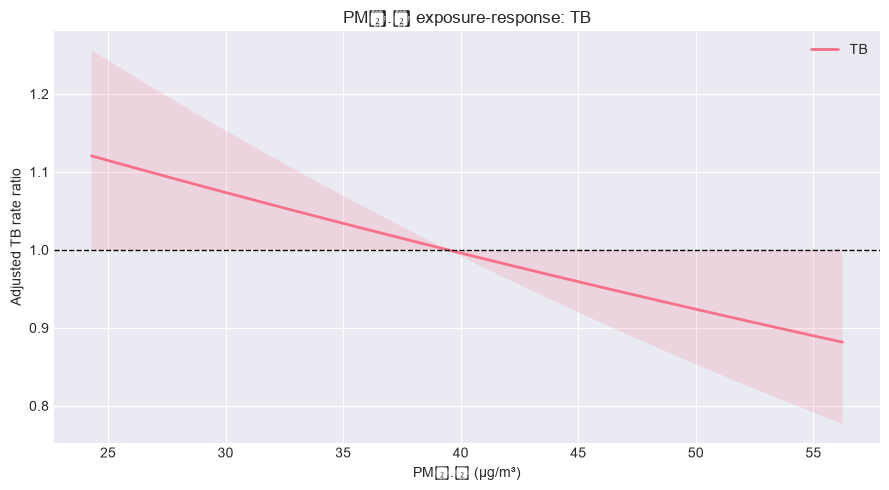

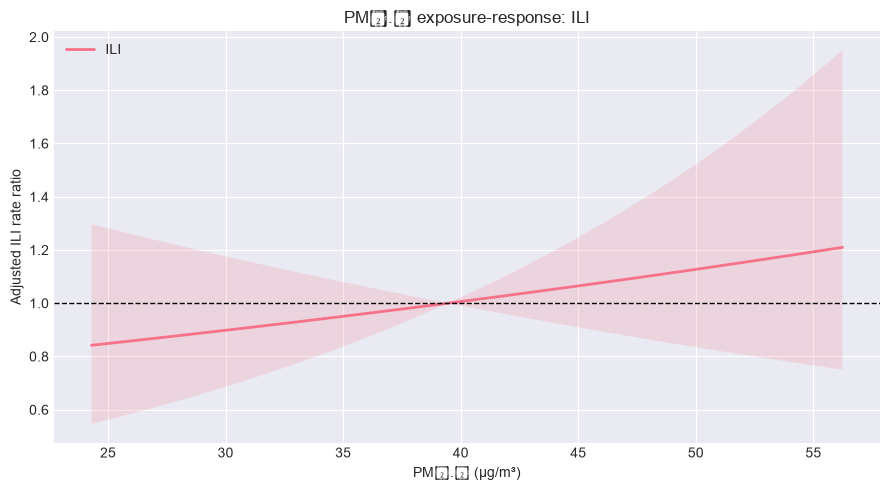

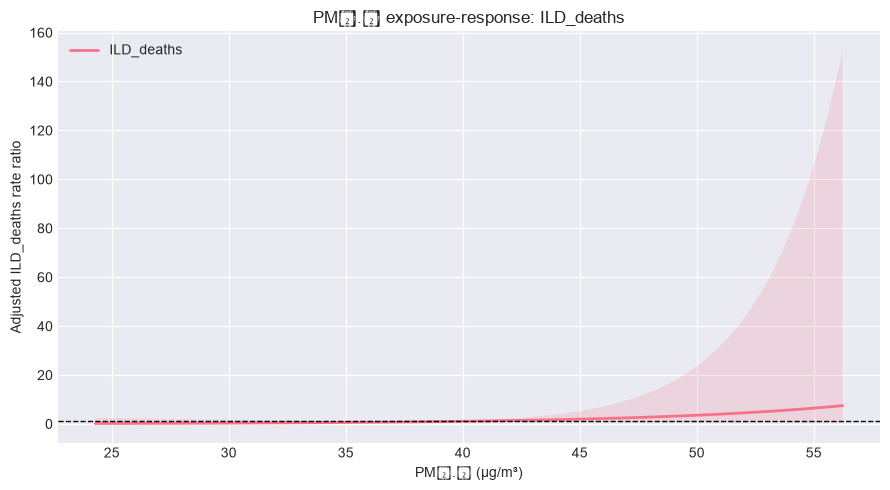

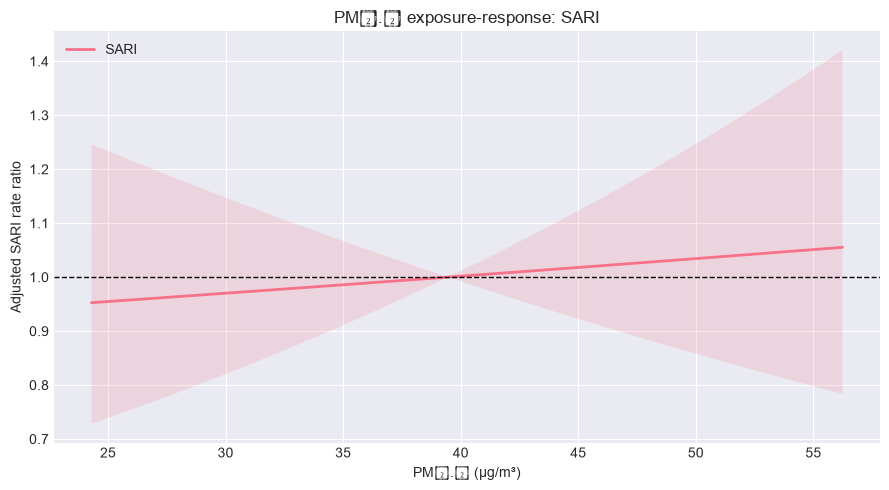

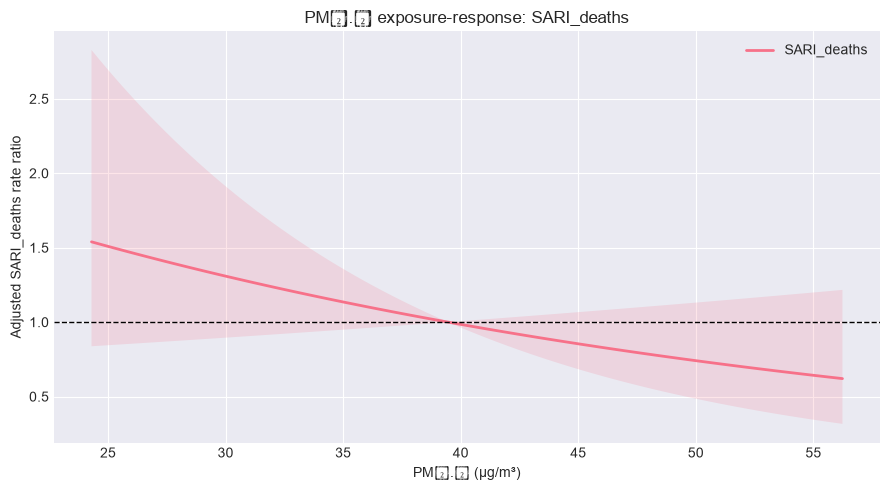

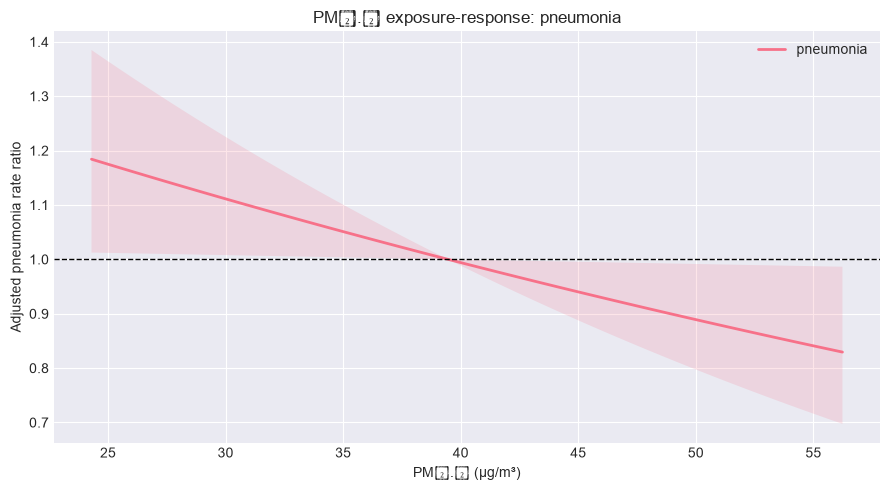

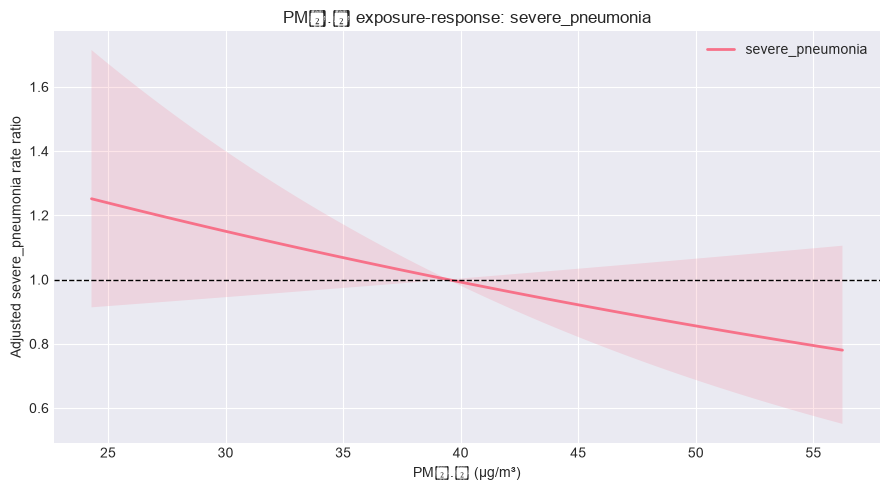

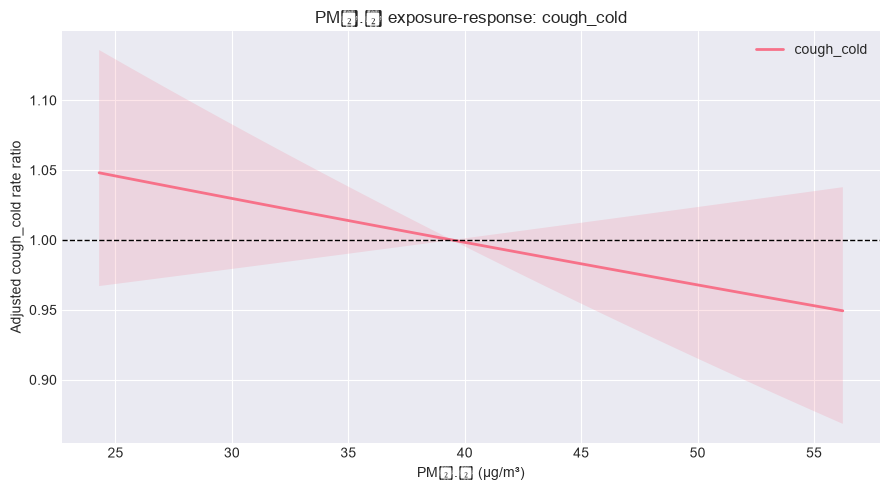

,Disease,Reference PM2.5,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,39.457,0.928,0.860,1.000
1,ILI,39.457,1.120,0.843,1.489
2,ILD_deaths,39.457,3.314,0.548,20.041
3,SARI,39.457,1.033,0.865,1.233
4,SARI_deaths,39.457,0.752,0.504,1.124
5,pneumonia,39.457,0.895,0.807,0.992
6,severe_pneumonia,39.457,0.862,0.701,1.061
7,cough_cold,39.457,0.969,0.919,1.022


In [93]:
# PM2.5 exposure-response relationships for every disease
exposure_terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
exposure_response_results = []
for disease in disease_columns:
    frame = processed_data[[disease] + exposure_terms].apply(pd.to_numeric, errors='coerce').dropna()
    frame = frame[frame[disease] >= 0].copy(); frame['time'] = np.arange(len(frame))
    terms = exposure_terms + ['time']
    if len(frame) < 20 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    grid = np.linspace(frame['pm2_5'].quantile(.05), frame['pm2_5'].quantile(.95), 100); reference = frame['pm2_5'].median()
    beta, se = fit.params['pm2_5'], fit.bse['pm2_5']
    fig, ax = plt.subplots(figsize=(9, 5)); log_rr = (grid-reference)*beta; se_log_rr = abs(grid-reference)*se
    ax.plot(grid, np.exp(log_rr), lw=2, label=disease); ax.fill_between(grid, np.exp(log_rr-1.96*se_log_rr), np.exp(log_rr+1.96*se_log_rr), alpha=.18)
    ax.axhline(1, color='black', ls='--', lw=1); ax.set(xlabel='PM₂.₅ (µg/m³)', ylabel=f'Adjusted {disease} rate ratio', title=f'PM₂.₅ exposure-response: {disease}'); ax.legend(); plt.tight_layout(); plt.show()
    exposure_response_results.append({'Disease': disease, 'Reference PM2.5': reference, 'IRR per 10 µg/m³': np.exp(beta*10), '95% CI lower': np.exp((beta-1.96*se)*10), '95% CI upper': np.exp((beta+1.96*se)*10)})
exposure_response_results = pd.DataFrame(exposure_response_results)
display(exposure_response_results.round(3))


### 4. DLNM lag-specific and cumulative effects

This distributed-lag Poisson model reports lag-specific and cumulative PM₂.₅ associations. The lag window is deliberately short and should be interpreted as an exploratory DLNM-style analysis; a full distributed-lag non-linear model would additionally require explicit exposure and lag basis functions selected a priori.


In [94]:
# Exploratory distributed-lag PM2.5 models for every disease
max_lag = 4; dlnm_rows = []; dlnm_cumulative_rows = []
for disease in disease_columns:
    frame = processed_data[[disease, 'pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']].copy(); frame['time'] = np.arange(len(frame))
    lag_terms = []
    for lag in range(max_lag + 1):
        name = f'pm25_lag_{lag}_dlnm'; frame[name] = pd.to_numeric(frame['pm2_5'], errors='coerce').shift(lag); lag_terms.append(name)
    terms = lag_terms + ['avgtemp', 'avghumidity', 'precip', 'time', 'month']; frame = frame[[disease] + terms].apply(pd.to_numeric, errors='coerce').dropna(); frame = frame[frame[disease] >= 0]
    if len(frame) < len(terms)+10 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    for lag in range(max_lag+1):
        term=f'pm25_lag_{lag}_dlnm'; beta=fit.params[term]*10; se=fit.bse[term]*10
        dlnm_rows.append({'Disease': disease, 'Lag': lag, 'IRR per 10 µg/m³': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se)})
    beta = fit.params[lag_terms].sum()*10; cov=fit.cov_params().loc[lag_terms, lag_terms]; se=np.sqrt(cov.to_numpy().sum())*10
    dlnm_cumulative_rows.append({'Disease': disease, 'Lag window': f'0–{max_lag}', 'Cumulative IRR per 10 µg/m³': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se)})
dlnm_results = pd.DataFrame(dlnm_rows); dlnm_cumulative = pd.DataFrame(dlnm_cumulative_rows)
display(dlnm_results.round(3)); display(dlnm_cumulative.round(3))


,Disease,Lag,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0,0.936,0.872,1.004
1,TB,1,0.964,0.889,1.045
2,TB,2,1.061,0.962,1.171
3,TB,3,0.914,0.830,1.006
4,TB,4,0.948,0.872,1.031
5,ILI,0,1.220,0.743,2.005
6,ILI,1,0.851,0.590,1.228
7,ILI,2,2.766,0.874,8.755
8,ILI,3,0.571,0.261,1.252
9,ILI,4,1.591,0.649,3.900


,Disease,Lag window,Cumulative IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0–4,0.830,0.702,0.982
1,ILI,0–4,2.611,0.475,14.354
2,ILD_deaths,0–4,39.936,6.475,246.311
3,SARI,0–4,1.379,0.946,2.011
4,SARI_deaths,0–4,0.851,0.296,2.451
5,pneumonia,0–4,0.867,0.669,1.124
6,severe_pneumonia,0–4,0.903,0.661,1.234
7,cough_cold,0–4,0.864,0.741,1.006


### 5. Temperature and humidity effects

The adjusted model below reports associations of temperature (per 1 °C) and relative humidity (per 10 percentage points) with TB notifications while holding PM₂.₅ and the other covariates constant.


In [95]:
# Temperature and humidity associations for every disease
climate_rows = []
terms = ['pm2_5', 'avgtemp', 'avghumidity', 'precip', 'month']
for disease in disease_columns:
    frame = processed_data[[disease] + terms].apply(pd.to_numeric, errors='coerce').dropna()
    frame = frame[frame[disease] >= 0].copy(); frame['time'] = np.arange(len(frame))
    if len(frame) < 20 or frame[disease].sum() <= 0: continue
    fit = sm.GLM(frame[disease], sm.add_constant(frame[terms + ['time']], has_constant='add'), family=sm.families.Poisson()).fit(cov_type='HC3')
    for term, label, increment in [('avgtemp', 'Temperature (per 1 °C)', 1), ('avghumidity', 'Relative humidity (per 10 percentage points)', 10)]:
        beta, se = fit.params[term]*increment, fit.bse[term]*increment
        climate_rows.append({'Disease': disease, 'Exposure': label, 'IRR': np.exp(beta), '95% CI lower': np.exp(beta-1.96*se), '95% CI upper': np.exp(beta+1.96*se), 'p-value': fit.pvalues[term]})
climate_results = pd.DataFrame(climate_rows)
display(climate_results.round(3))


,Disease,Exposure,IRR,95% CI lower,95% CI upper,p-value
0,TB,Temperature (per 1 °C),0.837,0.758,0.924,0.000
1,TB,Relative humidity (per 10 percentage points),0.901,0.696,1.166,0.427
2,ILI,Temperature (per 1 °C),1.040,0.627,1.726,0.878
3,ILI,Relative humidity (per 10 percentage points),2.420,1.058,5.536,0.036
4,ILD_deaths,Temperature (per 1 °C),0.089,0.016,0.507,0.006
5,ILD_deaths,Relative humidity (per 10 percentage points),19.575,0.054,7102.361,0.323
6,SARI,Temperature (per 1 °C),0.897,0.704,1.142,0.376
7,SARI,Relative humidity (per 10 percentage points),0.701,0.343,1.430,0.329
8,SARI_deaths,Temperature (per 1 °C),0.919,0.584,1.445,0.714
9,SARI_deaths,Relative humidity (per 10 percentage points),0.283,0.089,0.905,0.033


In [96]:
# Monthly tables: annual totals and calendar-month averages.
monthly_disease_cols = [c for c in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if c in processed_data.columns]
annual_monthly_totals = processed_data.groupby(processed_data['date'].dt.year)[monthly_disease_cols].sum().round(0).astype(int)
calendar_month_means = processed_data.groupby(processed_data['date'].dt.month)[['pm2_5'] + monthly_disease_cols].mean().round(2).reindex(range(1, 13))
print('Annual totals calculated from monthly observations')
display(annual_monthly_totals)
print('Average value by calendar month across all years')
display(calendar_month_means)


Annual totals calculated from monthly observations


,TB,ILI,ILD_deaths,SARI,SARI_deaths,pneumonia,severe_pneumonia,cough_cold
date,,,,,,,,
2020,17171,4911,6798,7407,36,16865,3742,230480
2021,23511,1239,148,10438,213,25933,7339,273419
2022,36286,2567,92,13673,57,30651,4619,356403
2023,38311,4842,232,8592,68,22735,3639,319189
2024,41094,69389,129,14481,77,24387,4937,306990


Average value by calendar month across all years


,pm2_5,TB,ILI,ILD_deaths,SARI,SARI_deaths,pneumonia,severe_pneumonia,cough_cold
date,,,,,,,,,
1,55.68,1976.4,382.8,6.6,1228.6,6.2,1727.8,435.2,24174.8
2,49.30,2586.6,525.2,1.4,659.4,8.0,2015.4,361.0,24640.6
3,33.48,2908.8,861.4,6.8,904.8,6.2,2288.8,446.0,28427.8
4,23.28,2344.2,669.2,4.2,650.0,4.4,2086.8,381.4,25097.8
5,28.07,2552.6,1358.0,18.4,750.0,2.4,2227.4,507.0,25346.6
6,39.37,2336.6,990.8,31.0,1123.2,12.2,2391.8,550.8,27579.0
7,47.84,2928.6,1729.4,9.8,1112.6,11.4,1902.4,415.2,23997.0
8,45.11,2885.8,2708.0,19.8,1067.6,5.8,1831.2,312.8,24523.0
9,38.41,2937.0,2269.8,6.0,823.8,14.4,1678.2,315.4,20973.4


## Step 2: Exploratory Data Analysis


### 2.1 Time Series Overview


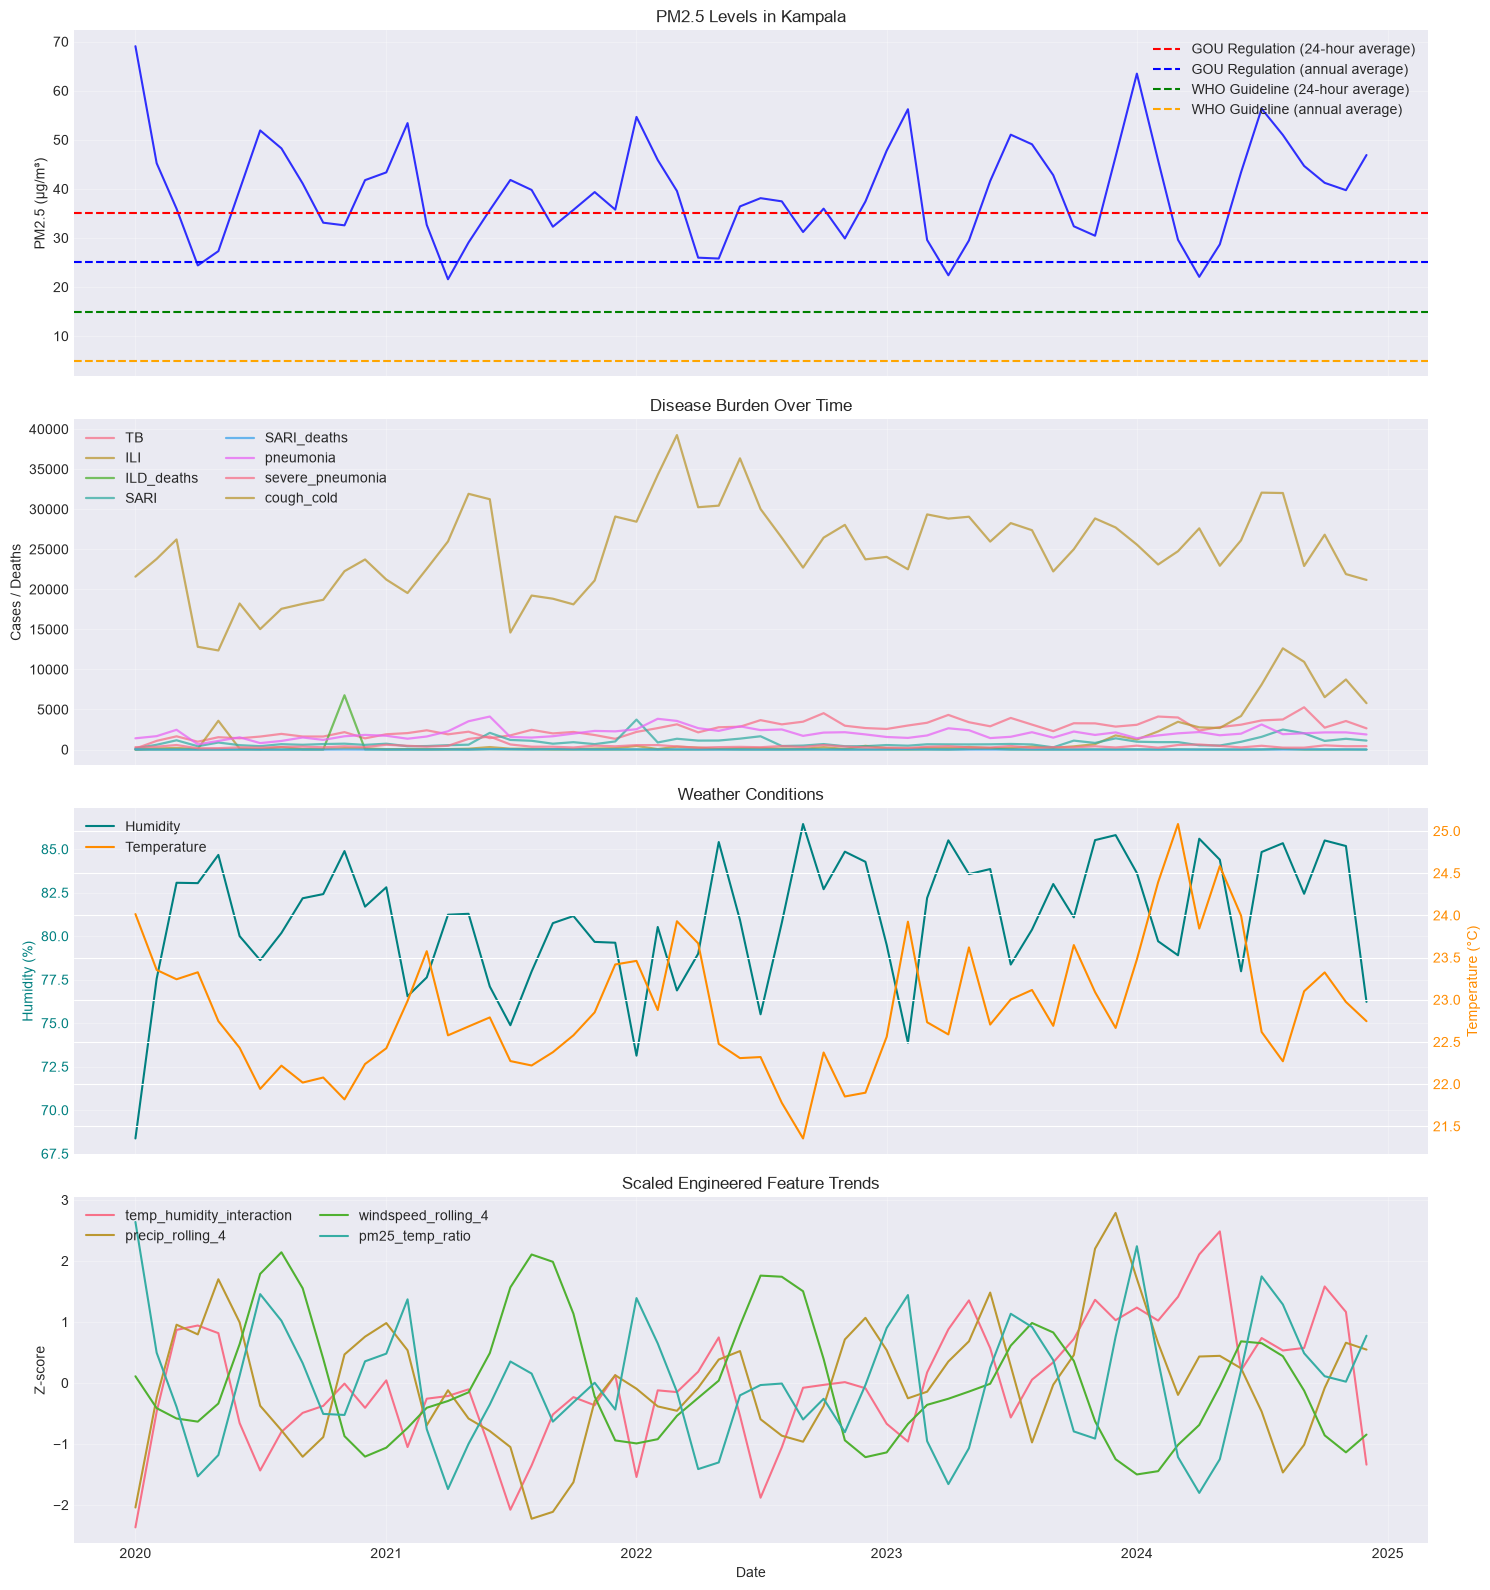

In [97]:
# Time series overview for air quality, diseases, and weather
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]

fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

axes[0].plot(processed_data['date'], processed_data['pm2_5'], color='blue', alpha=0.8)
axes[0].axhline(y=35, color='red', linestyle='--', label='GOU Regulation (24-hour average)')
axes[0].axhline(y=25, color='blue', linestyle='--', label='GOU Regulation (annual average)')
axes[0].axhline(y=15, color='green', linestyle='--', label='WHO Guideline (24-hour average)')
axes[0].axhline(y=5, color='orange', linestyle='--', label='WHO Guideline (annual average)')
axes[0].set_title('PM2.5 Levels in Kampala')
axes[0].set_ylabel('PM2.5 (μg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for disease in disease_cols:
    axes[1].plot(processed_data['date'], processed_data[disease], alpha=0.75, linewidth=1.6, label=disease)
axes[1].set_title('Disease Burden Over Time')
axes[1].set_ylabel('Cases / Deaths')
axes[1].legend(loc='upper left', ncol=2)
axes[1].grid(True, alpha=0.3)

weather_ax = axes[2]
temperature_ax = weather_ax.twinx()
weather_ax.plot(processed_data['date'], processed_data['avghumidity'], color='teal', label='Humidity')
temperature_ax.plot(processed_data['date'], processed_data['avgtemp'], color='darkorange', label='Temperature')
weather_ax.set_title('Weather Conditions')
weather_ax.set_ylabel('Humidity (%)', color='teal')
temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
weather_ax.tick_params(axis='y', labelcolor='teal')
temperature_ax.tick_params(axis='y', labelcolor='darkorange')
weather_ax.grid(True, alpha=0.3)
weather_handles, weather_labels = weather_ax.get_legend_handles_labels()
temp_handles, temp_labels = temperature_ax.get_legend_handles_labels()
weather_ax.legend(weather_handles + temp_handles, weather_labels + temp_labels, loc='upper left')

engineered_plot_cols = [
    col for col in ['temp_humidity_interaction', 'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio']
    if col in processed_data.columns
]
engineered_scaled = processed_data[engineered_plot_cols].copy()
for col in engineered_plot_cols:
    col_std = engineered_scaled[col].std()
    if pd.notna(col_std) and col_std != 0:
        engineered_scaled[col] = (engineered_scaled[col] - engineered_scaled[col].mean()) / col_std
    else:
        engineered_scaled[col] = 0
for col in engineered_plot_cols:
    axes[3].plot(processed_data['date'], engineered_scaled[col], linewidth=1.5, label=col)
axes[3].set_title('Scaled Engineered Feature Trends')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left', ncol=2)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.2 Correlation Analysis


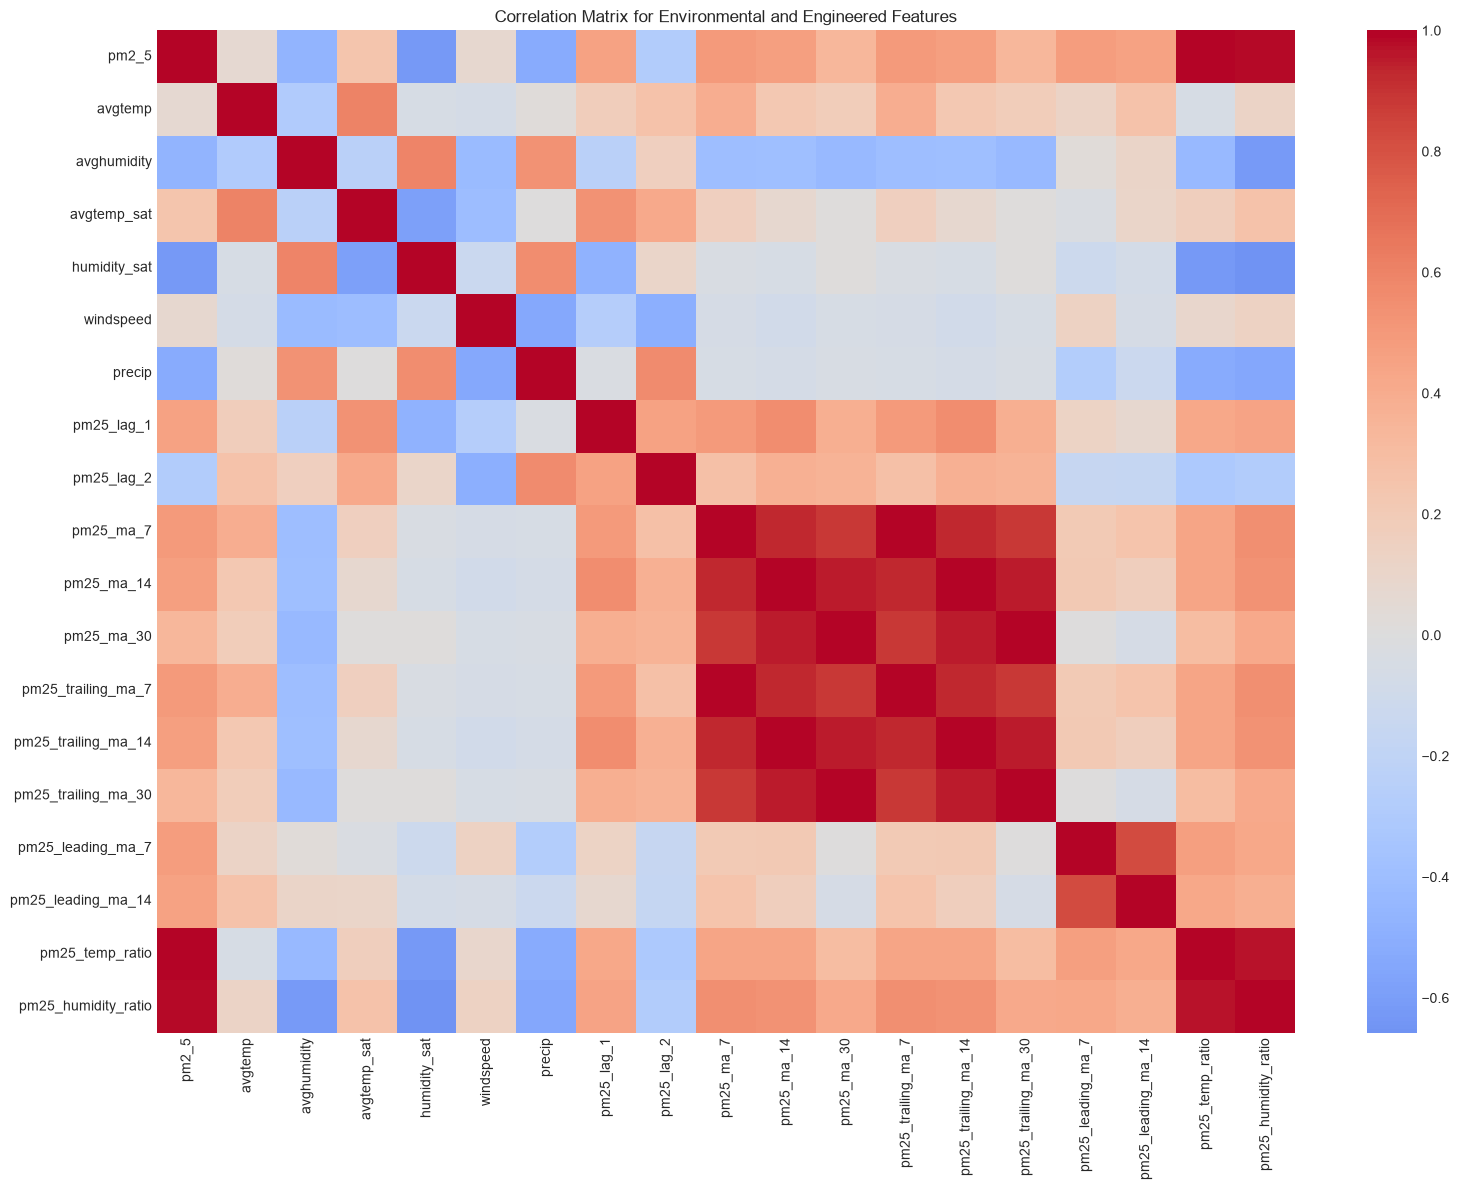

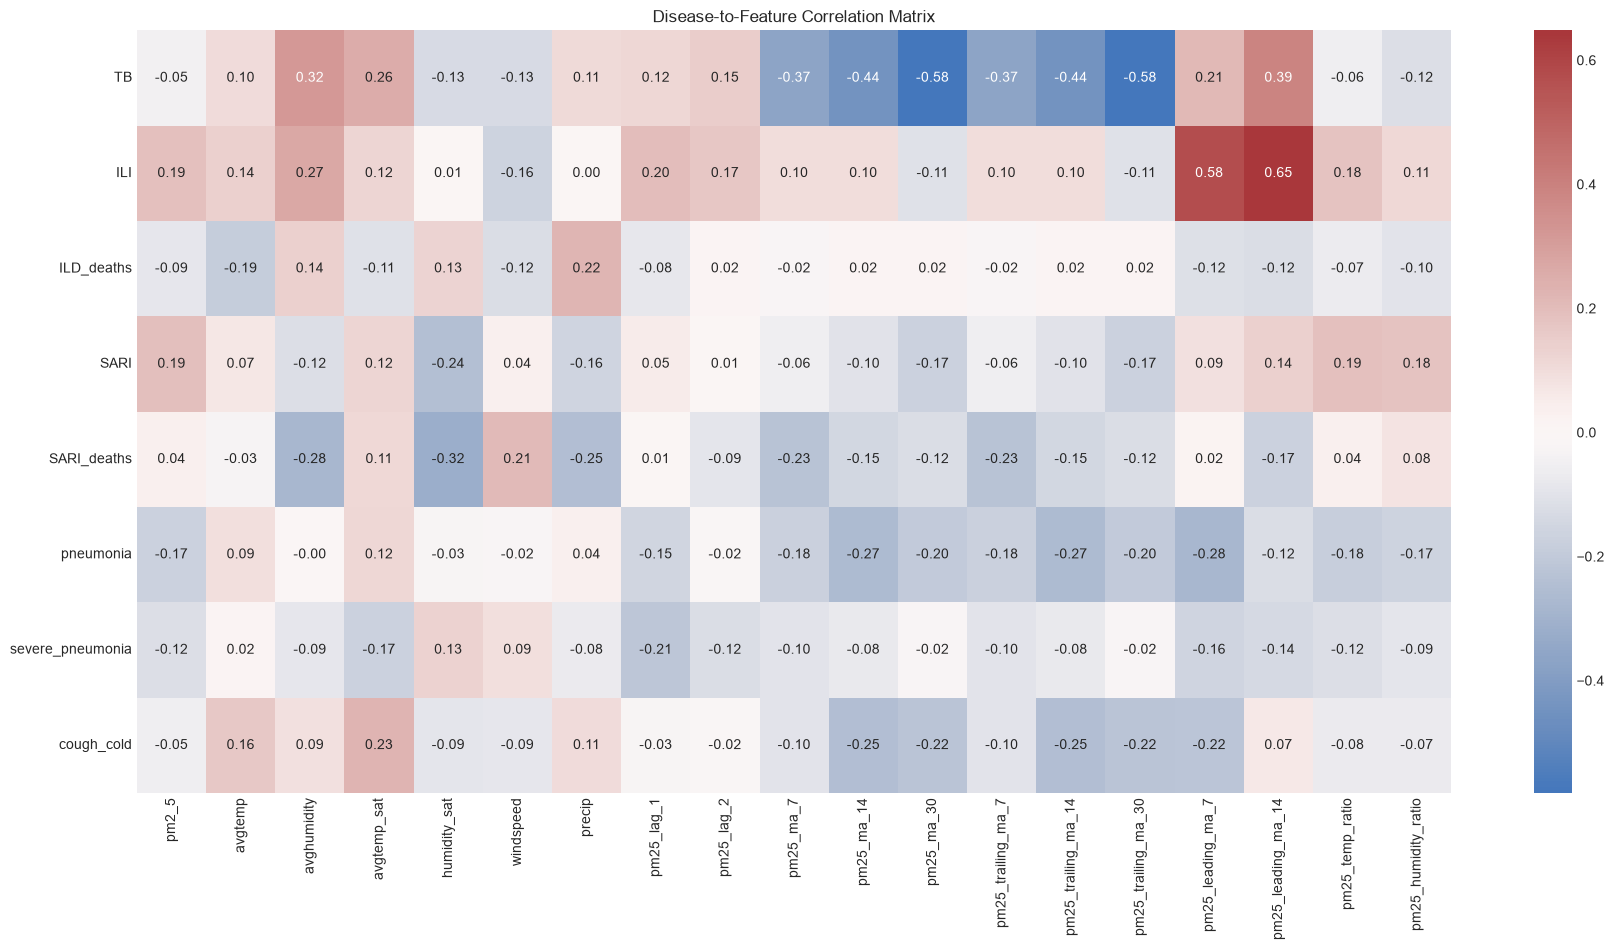

In [98]:
# Correlation analysis across diseases and engineered features
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2',
        'pm25_ma_7', 'pm25_ma_14',
        'pm25_ma_30', 'pm25_trailing_ma_7',
        'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
        'pm25_leading_ma_7', 'pm25_leading_ma_14',
        'pm25_temp_ratio', 'pm25_humidity_ratio',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

feature_corr_matrix = processed_data[feature_analysis_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(feature_corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Environmental and Engineered Features')
plt.tight_layout()
plt.show()

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
plt.figure(figsize=(18, max(4, len(disease_cols) * 1.2)))
sns.heatmap(disease_feature_corr, annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Disease-to-Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 2.3 Disease-Level Feature Ranking


In [99]:
# Disease-level feature ranking and pairwise relationships
disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]
feature_analysis_cols = [
    col for col in [
        'pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat',
        'windspeed', 'precip', 'pm25_lag_1', 'pm25_lag_2',
        'pm25_ma_7', 'pm25_ma_14',
        'pm25_ma_30', 'pm25_trailing_ma_7',
        'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
        'pm25_leading_ma_7', 'pm25_leading_ma_14',
        'pm25_temp_ratio', 'pm25_humidity_ratio',
        'time_since_intervention'
    ]
    if col in processed_data.columns
]

disease_feature_corr = processed_data[disease_cols + feature_analysis_cols].corr().loc[disease_cols, feature_analysis_cols]
strongest_links = (
    disease_feature_corr.abs()
    .stack()
    .reset_index(name='abs_correlation')
    .rename(columns={'level_0': 'disease', 'level_1': 'feature'})
    .sort_values(['disease', 'abs_correlation'], ascending=[True, False])
    .groupby('disease')
    .head(5)
)
strongest_links['correlation'] = strongest_links.apply(
    lambda row: disease_feature_corr.loc[row['disease'], row['feature']],
    axis=1
)
print('Top 5 absolute correlations per disease')
print(strongest_links[['disease', 'feature', 'correlation', 'abs_correlation']].to_string(index=False))

summary_stats = processed_data[disease_cols + feature_analysis_cols].describe().T[['mean', 'std', 'min', 'max']].round(2)
summary_stats.head(20)


Top 5 absolute correlations per disease
         disease             feature  correlation  abs_correlation
      ILD_deaths              precip     0.223823         0.223823
      ILD_deaths             avgtemp    -0.189581         0.189581
      ILD_deaths         avghumidity     0.142035         0.142035
      ILD_deaths        humidity_sat     0.127490         0.127490
      ILD_deaths           windspeed    -0.124978         0.124978
             ILI  pm25_leading_ma_14     0.647864         0.647864
             ILI   pm25_leading_ma_7     0.575014         0.575014
             ILI         avghumidity     0.268880         0.268880
             ILI          pm25_lag_1     0.196770         0.196770
             ILI               pm2_5     0.186909         0.186909
            SARI        humidity_sat    -0.241178         0.241178
            SARI               pm2_5     0.194016         0.194016
            SARI     pm25_temp_ratio     0.188914         0.188914
            SARI pm25_

,mean,std,min,max
TB,2606.22,970.14,114.00,5275.00
ILI,1382.47,2769.98,0.00,12633.00
ILD_deaths,123.32,873.51,0.00,6775.00
SARI,909.85,585.58,135.00,3738.00
SARI_deaths,7.52,10.06,0.00,47.00
pneumonia,2009.52,677.91,650.00,4119.00
severe_pneumonia,404.60,235.02,159.00,1620.00
cough_cold,24774.68,5517.50,12368.00,39249.00
pm2_5,39.36,10.21,21.58,69.08
avgtemp,22.89,0.75,21.36,25.08


### 2.4 PM2.5 vs Disease Scatter Plots


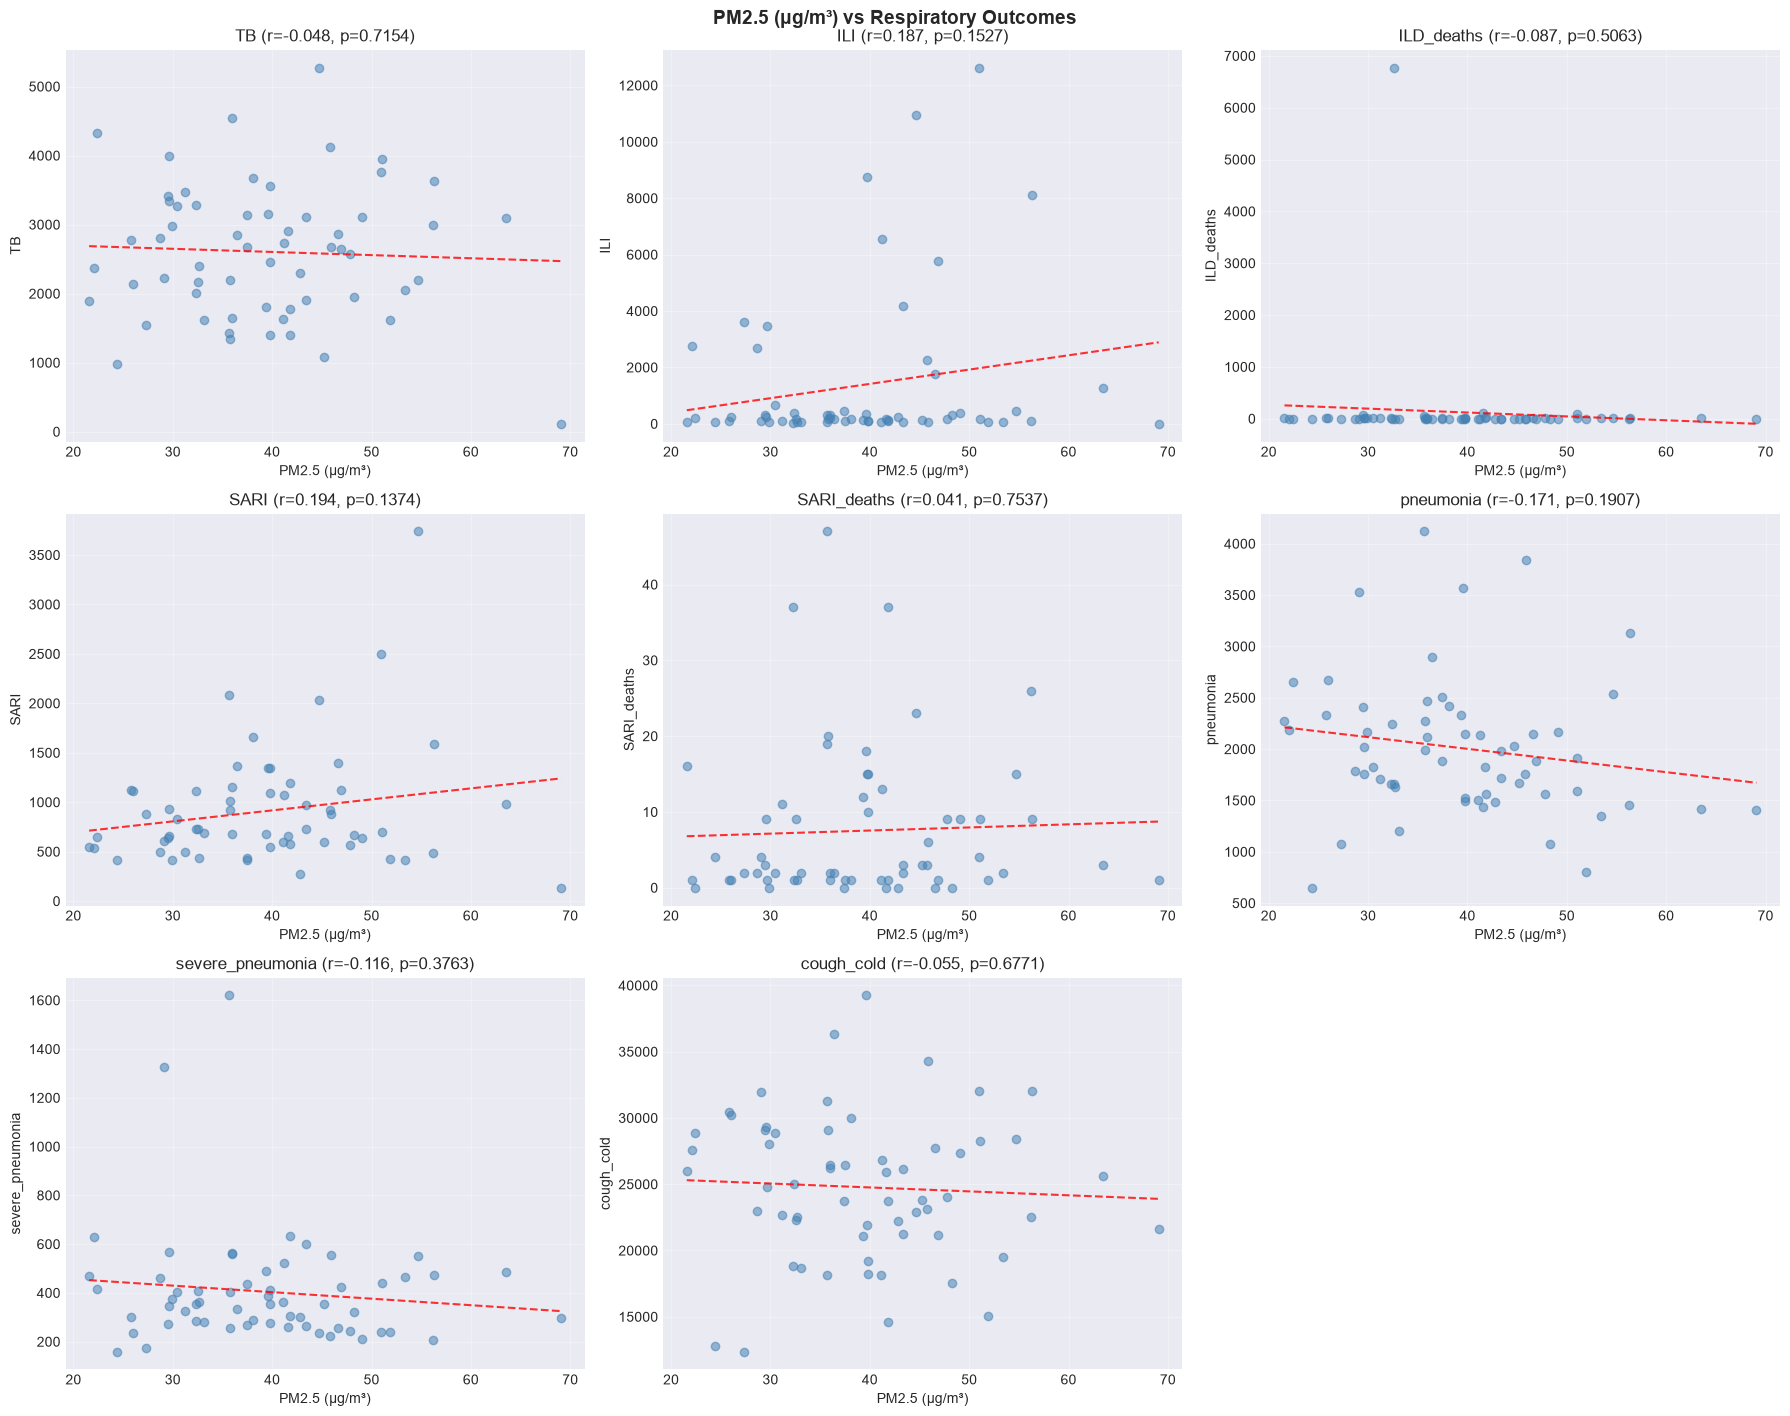

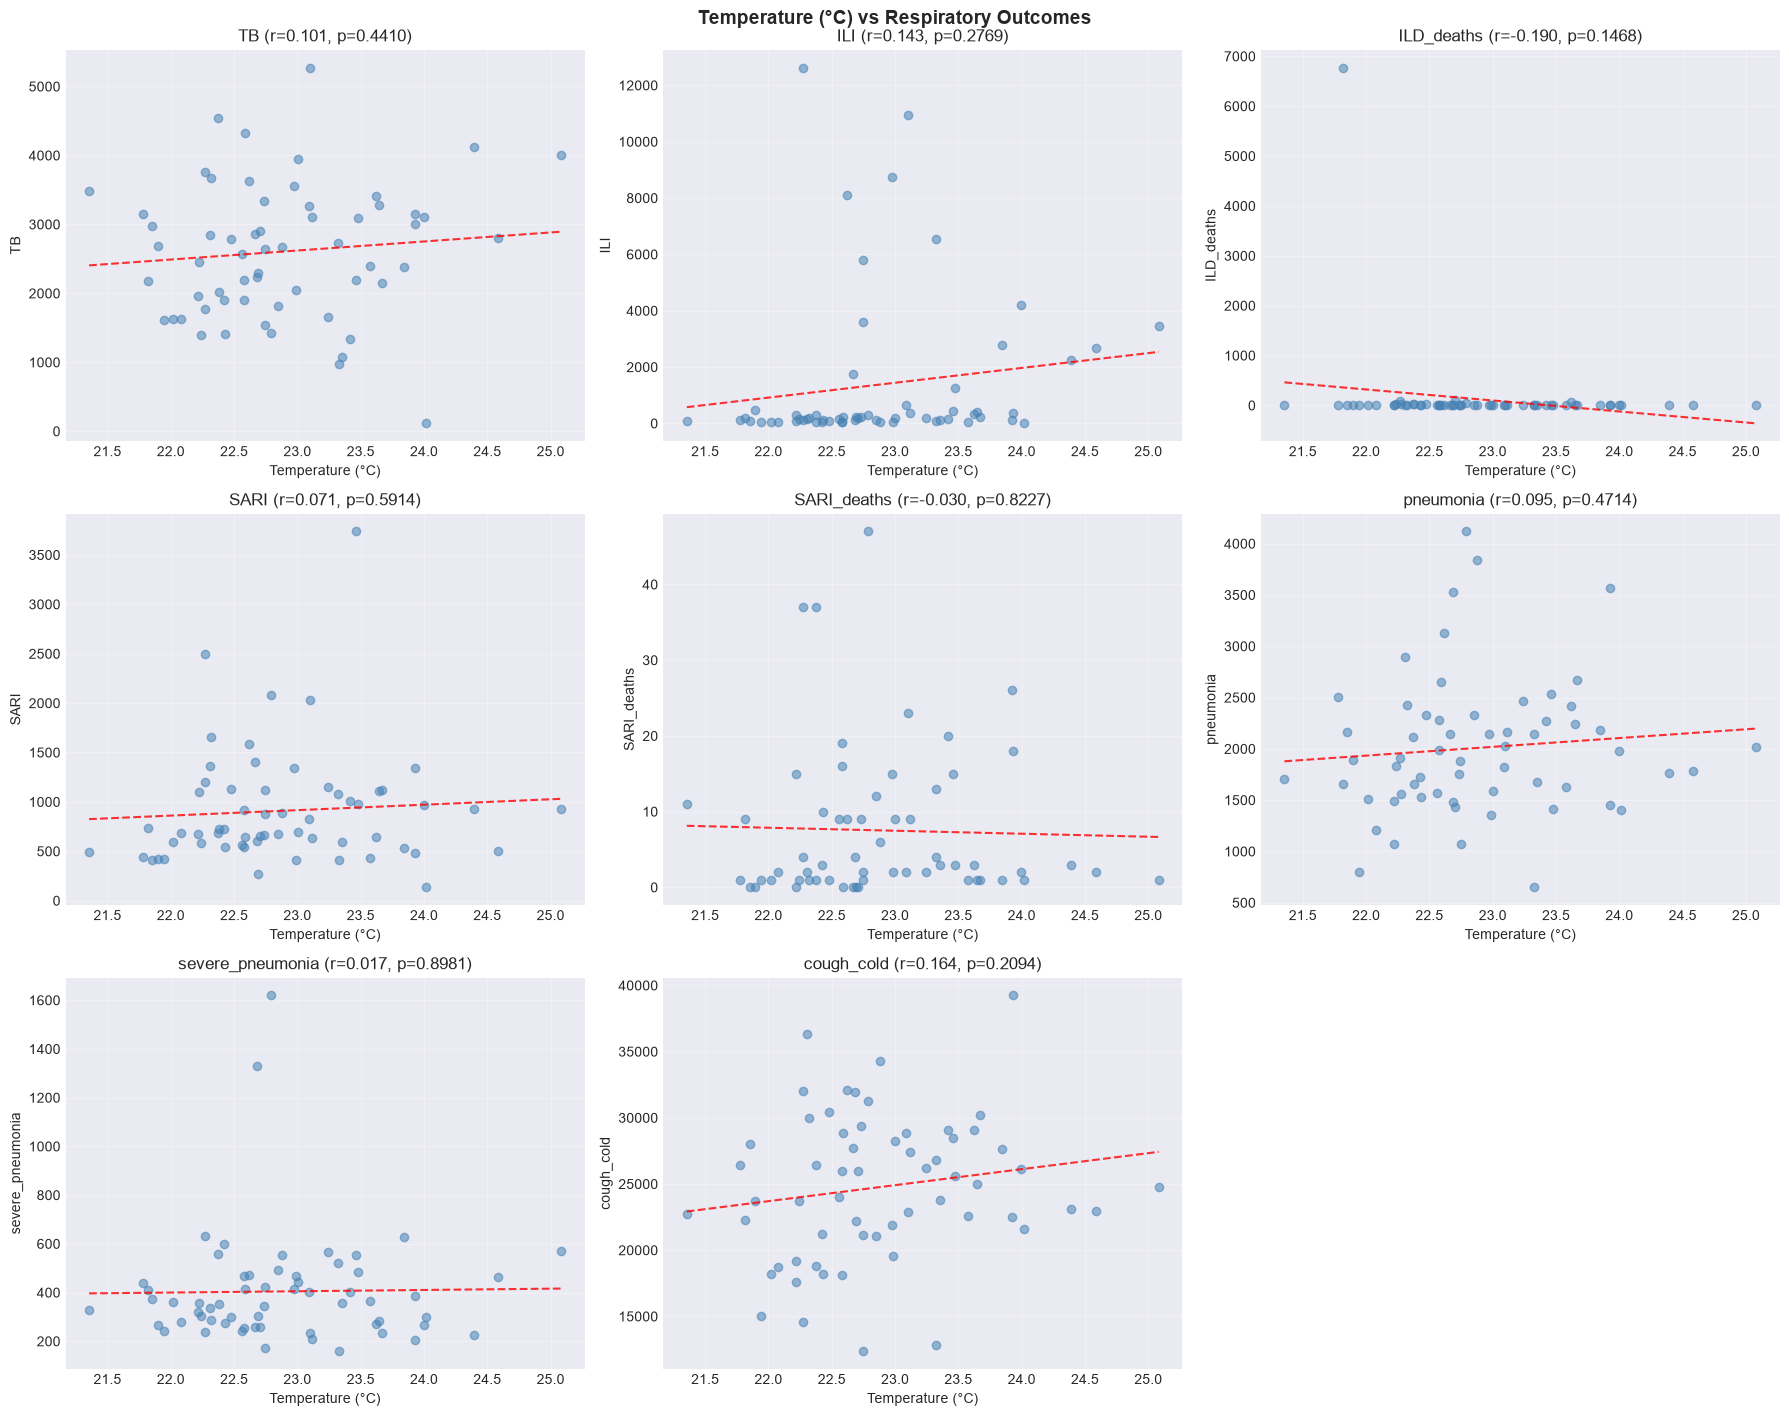

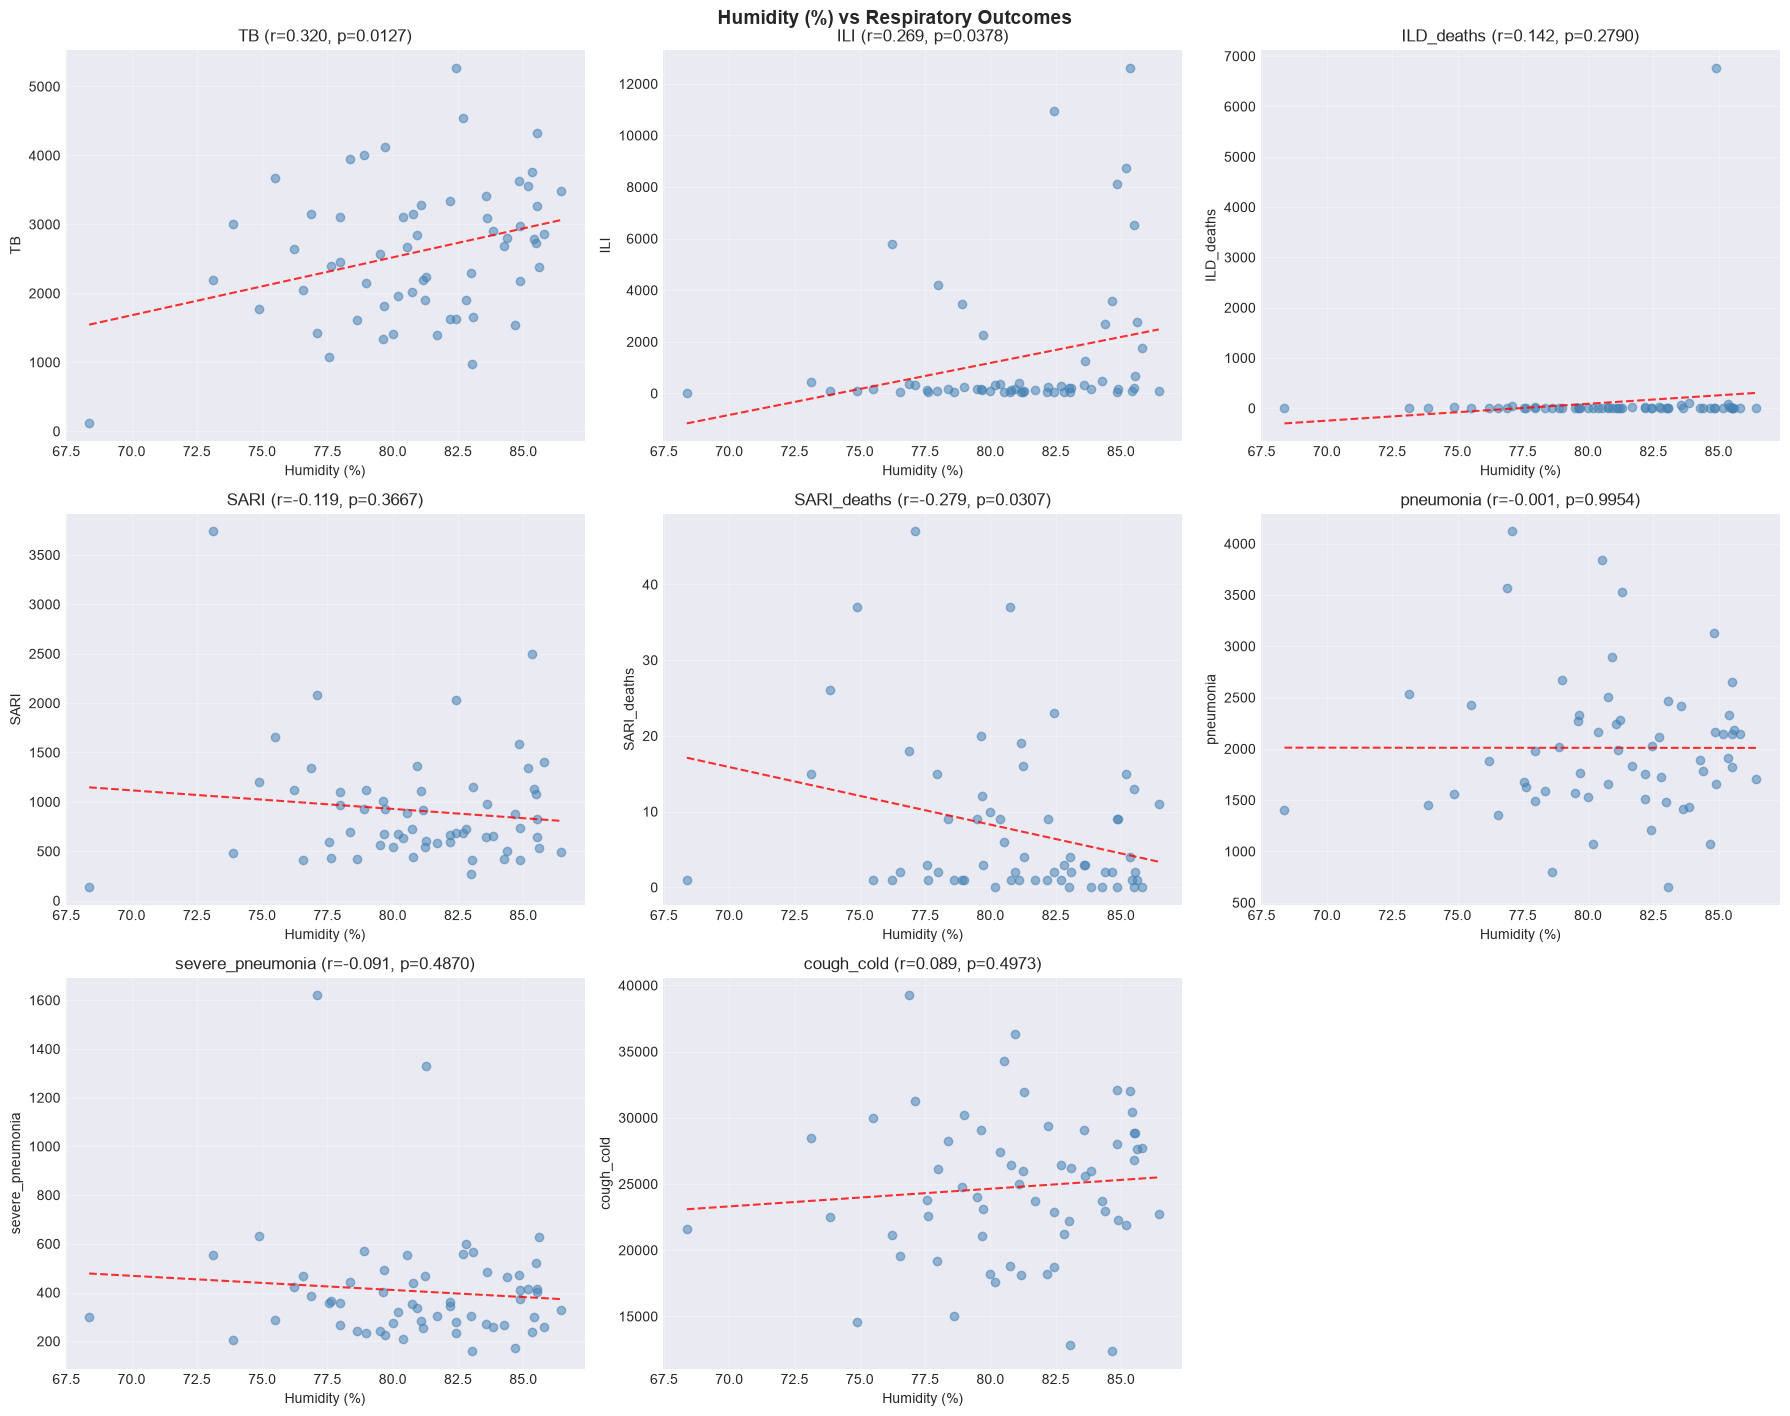

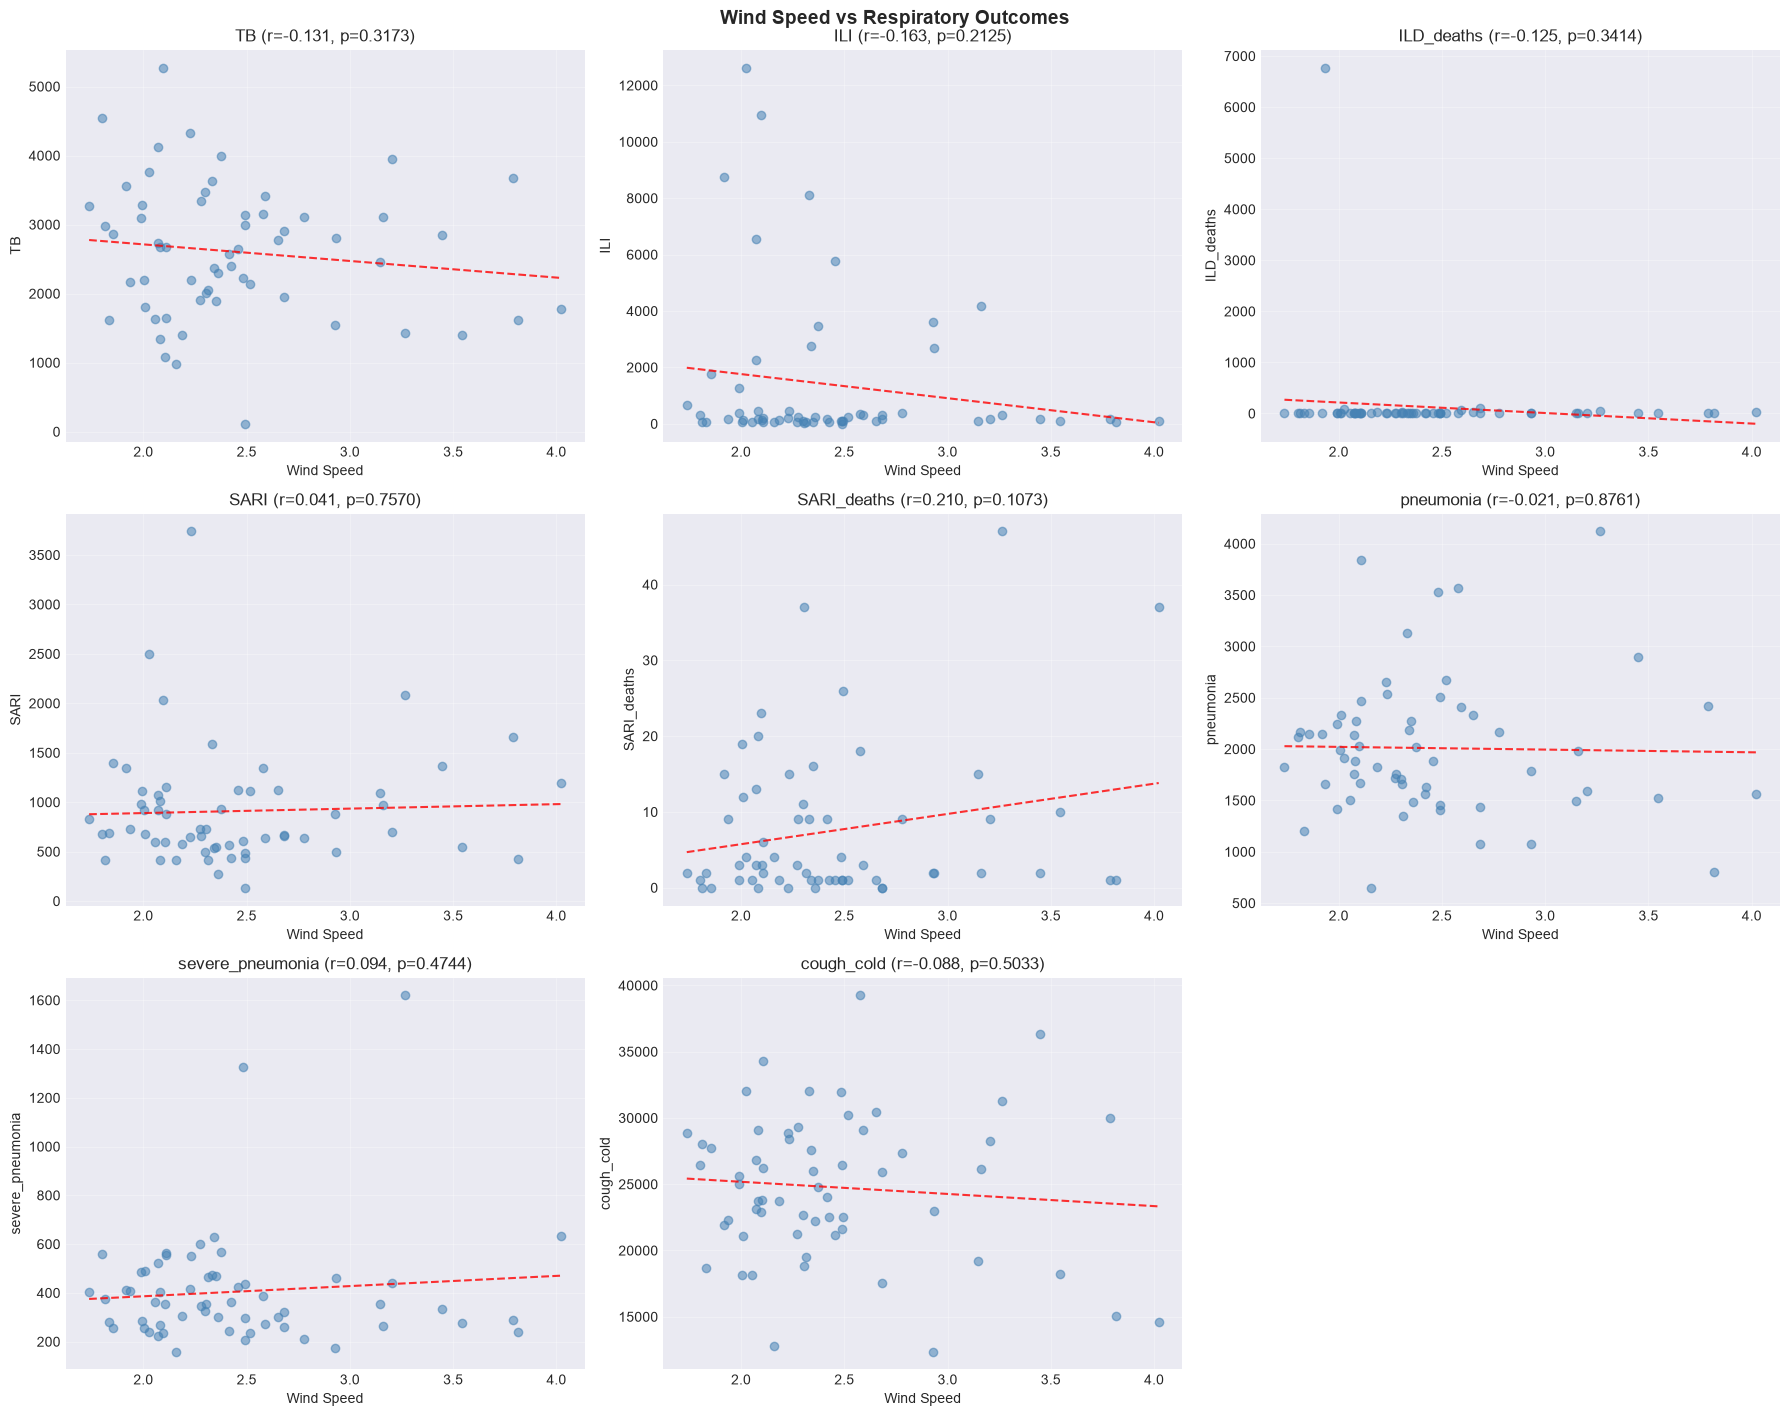

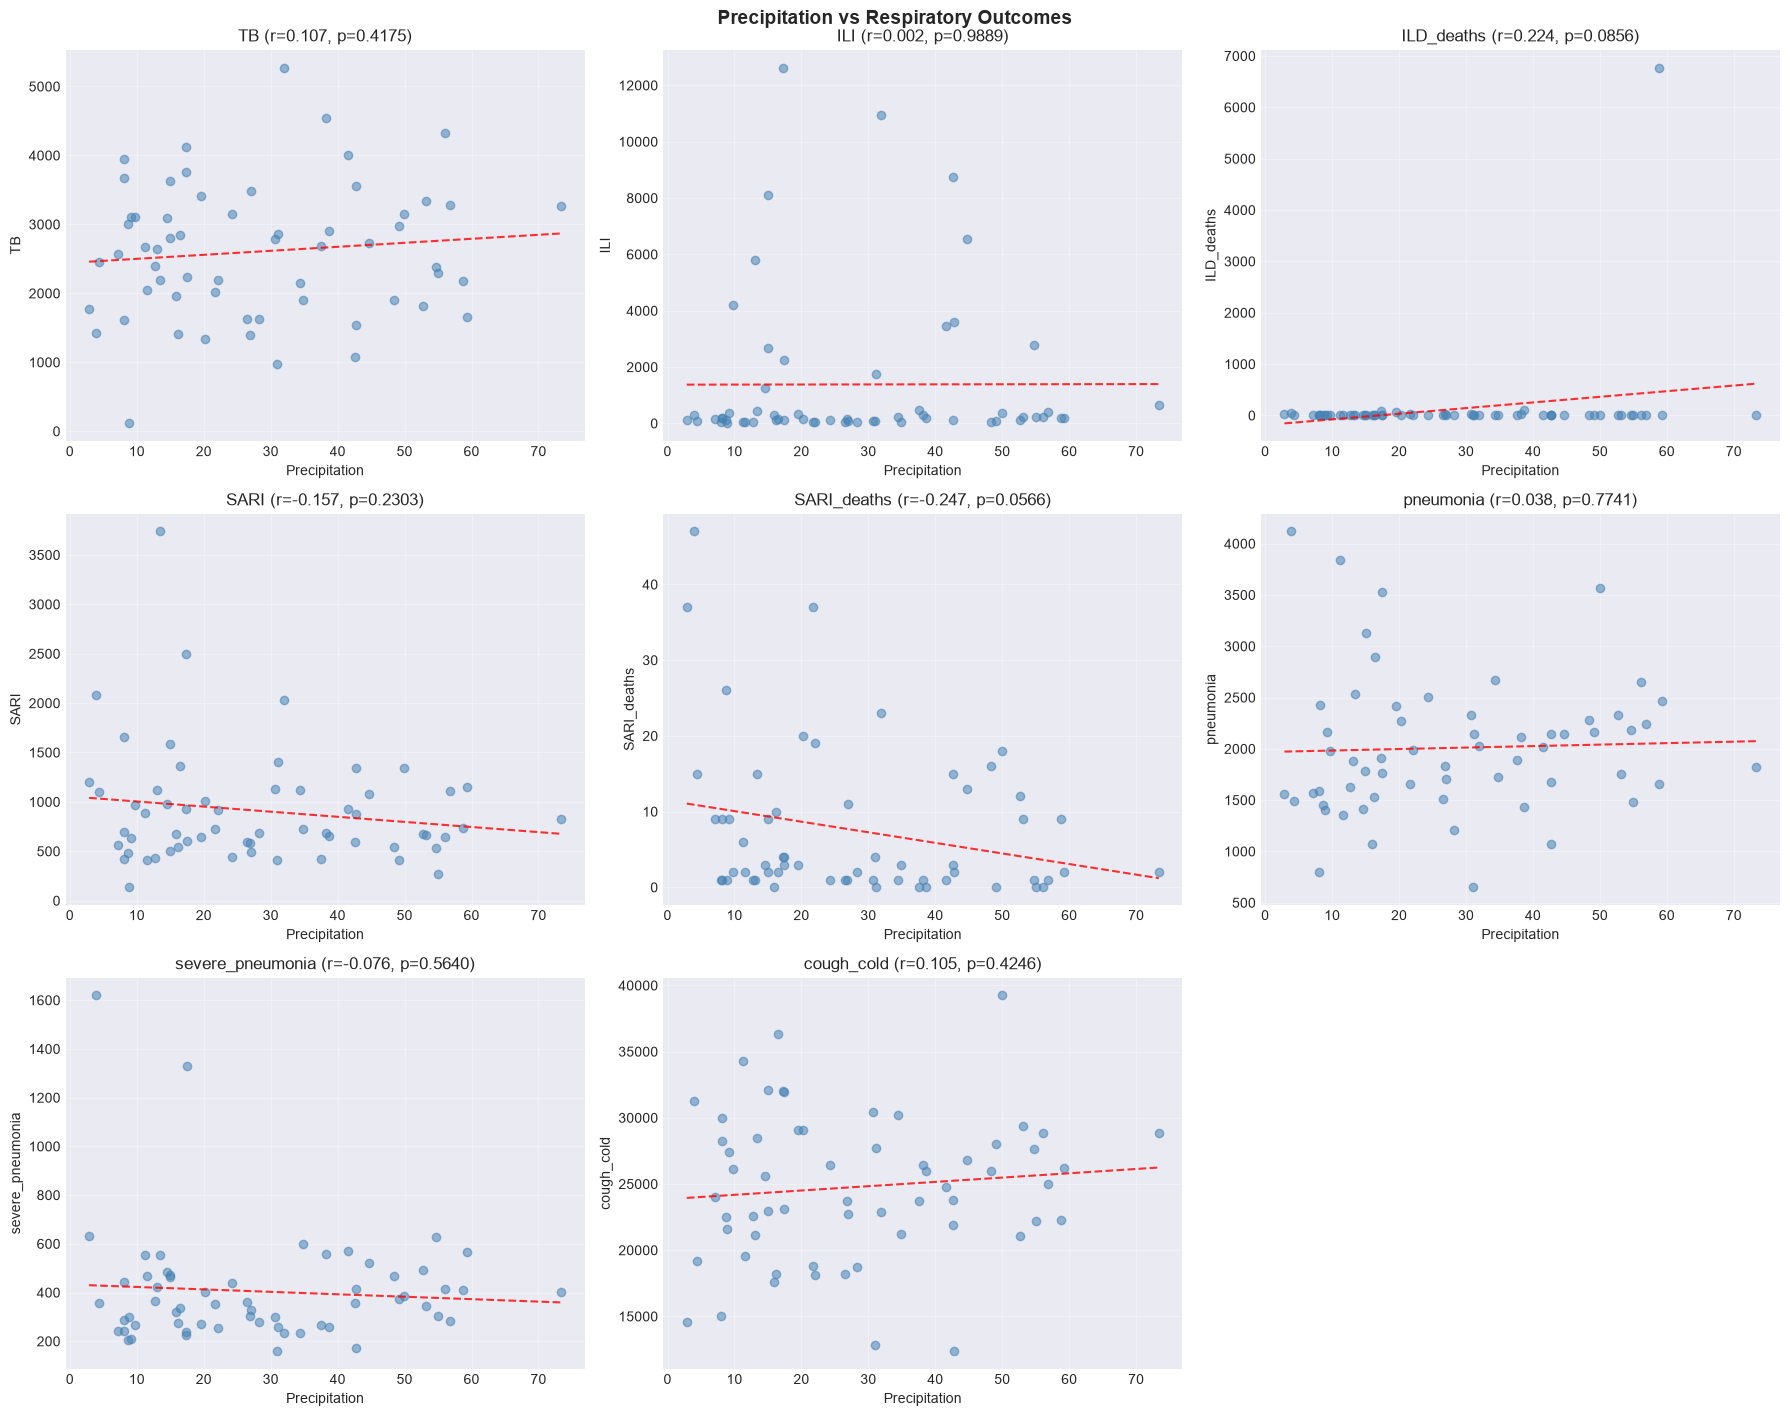

In [100]:
# Core air-quality and climate variables vs disease scatter plots with regression lines
import math
import scipy.stats as stats

disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]
core_feature_labels = {
    'pm2_5': 'PM2.5 (μg/m³)',
    'avgtemp': 'Temperature (°C)',
    'avghumidity': 'Humidity (%)',
    'windspeed': 'Wind Speed',
    'precip': 'Precipitation'
}
core_feature_cols = [col for col in core_feature_labels if col in processed_data.columns]

for feature in core_feature_cols:
    ncols = 3
    nrows = math.ceil(len(disease_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, disease in zip(axes, disease_cols):
        plot_data = processed_data[[feature, disease]].dropna()
        if len(plot_data) < 2:
            ax.text(0.5, 0.5, f'Not enough data for {disease}', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.scatter(plot_data[feature], plot_data[disease], alpha=0.55, color='steelblue')
        slope, intercept = np.polyfit(plot_data[feature], plot_data[disease], 1)
        regression = np.poly1d((slope, intercept))
        x_sorted = np.sort(plot_data[feature].to_numpy())
        ax.plot(x_sorted, regression(x_sorted), 'r--', alpha=0.8)

        corr, p_value = stats.pearsonr(plot_data[feature], plot_data[disease])
        ax.set_title(f'{disease} (r={corr:.3f}, p={p_value:.4f})')
        ax.set_xlabel(core_feature_labels[feature])
        ax.set_ylabel(disease)
        ax.grid(True, alpha=0.3)

    for ax in axes[len(disease_cols):]:
        ax.set_axis_off()

    plt.suptitle(f'{core_feature_labels[feature]} vs Respiratory Outcomes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 2.5 Seasonal Analysis


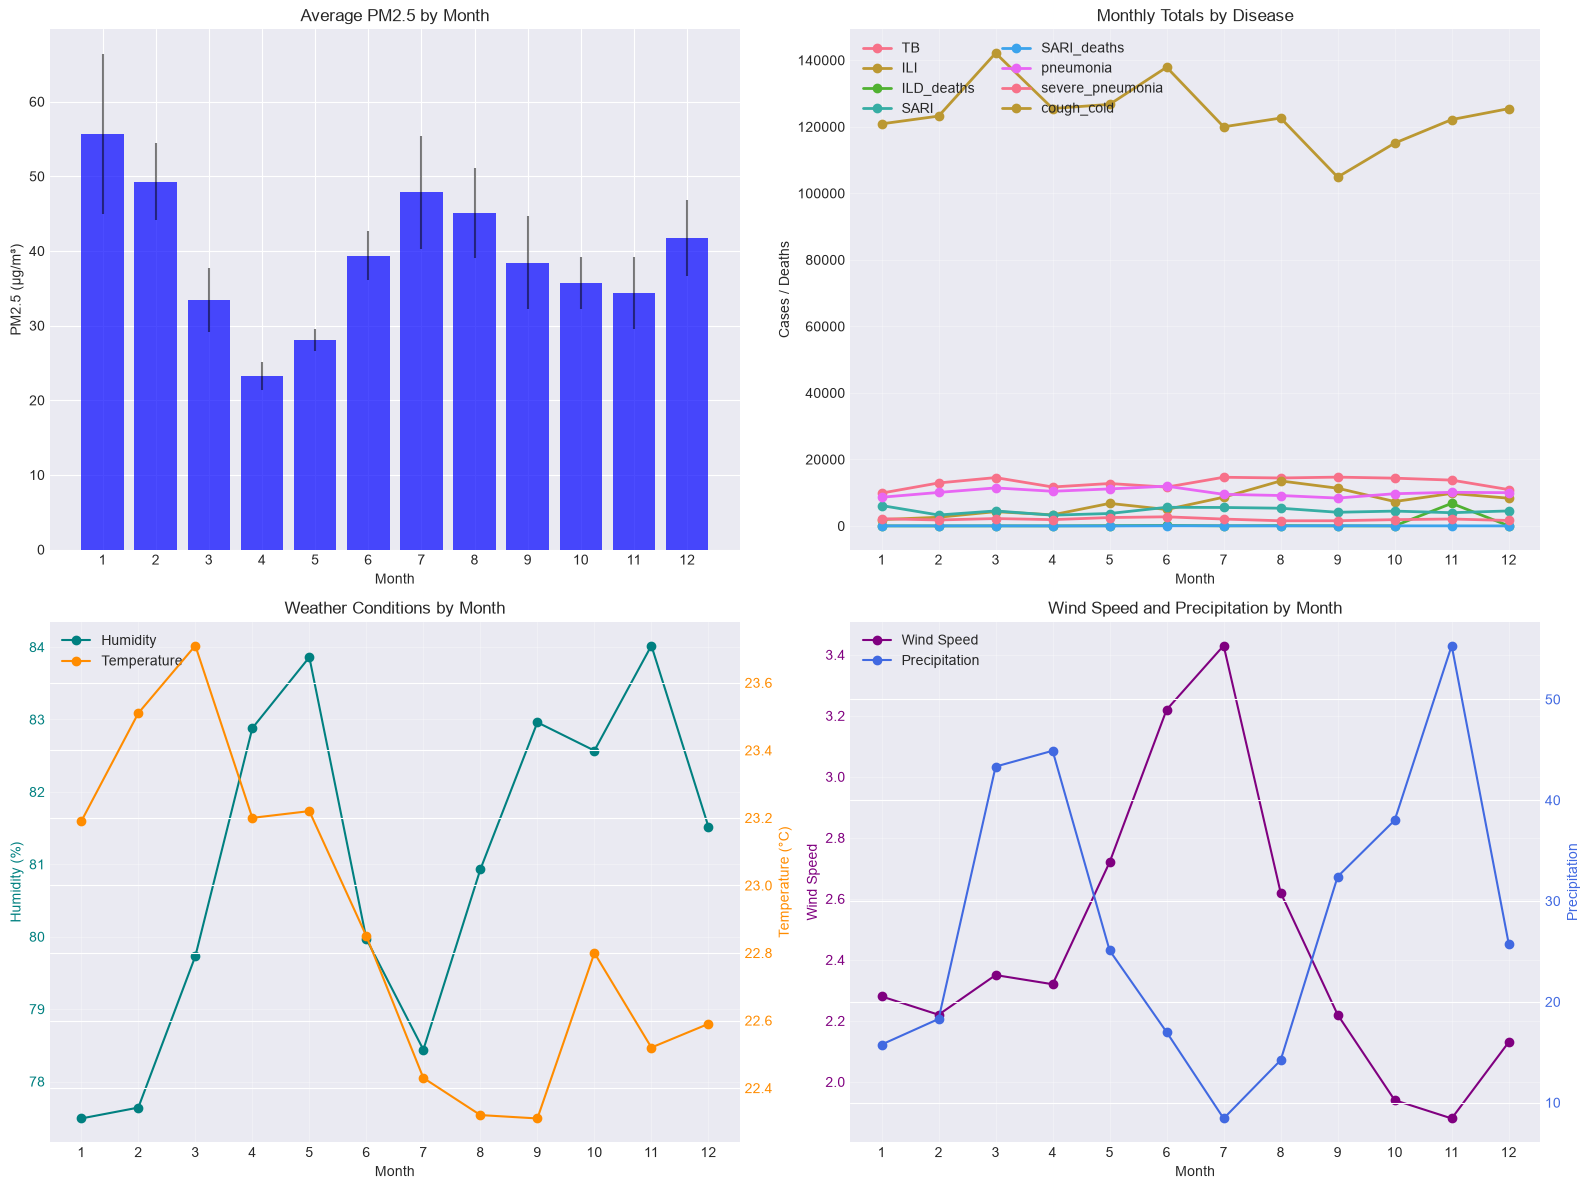

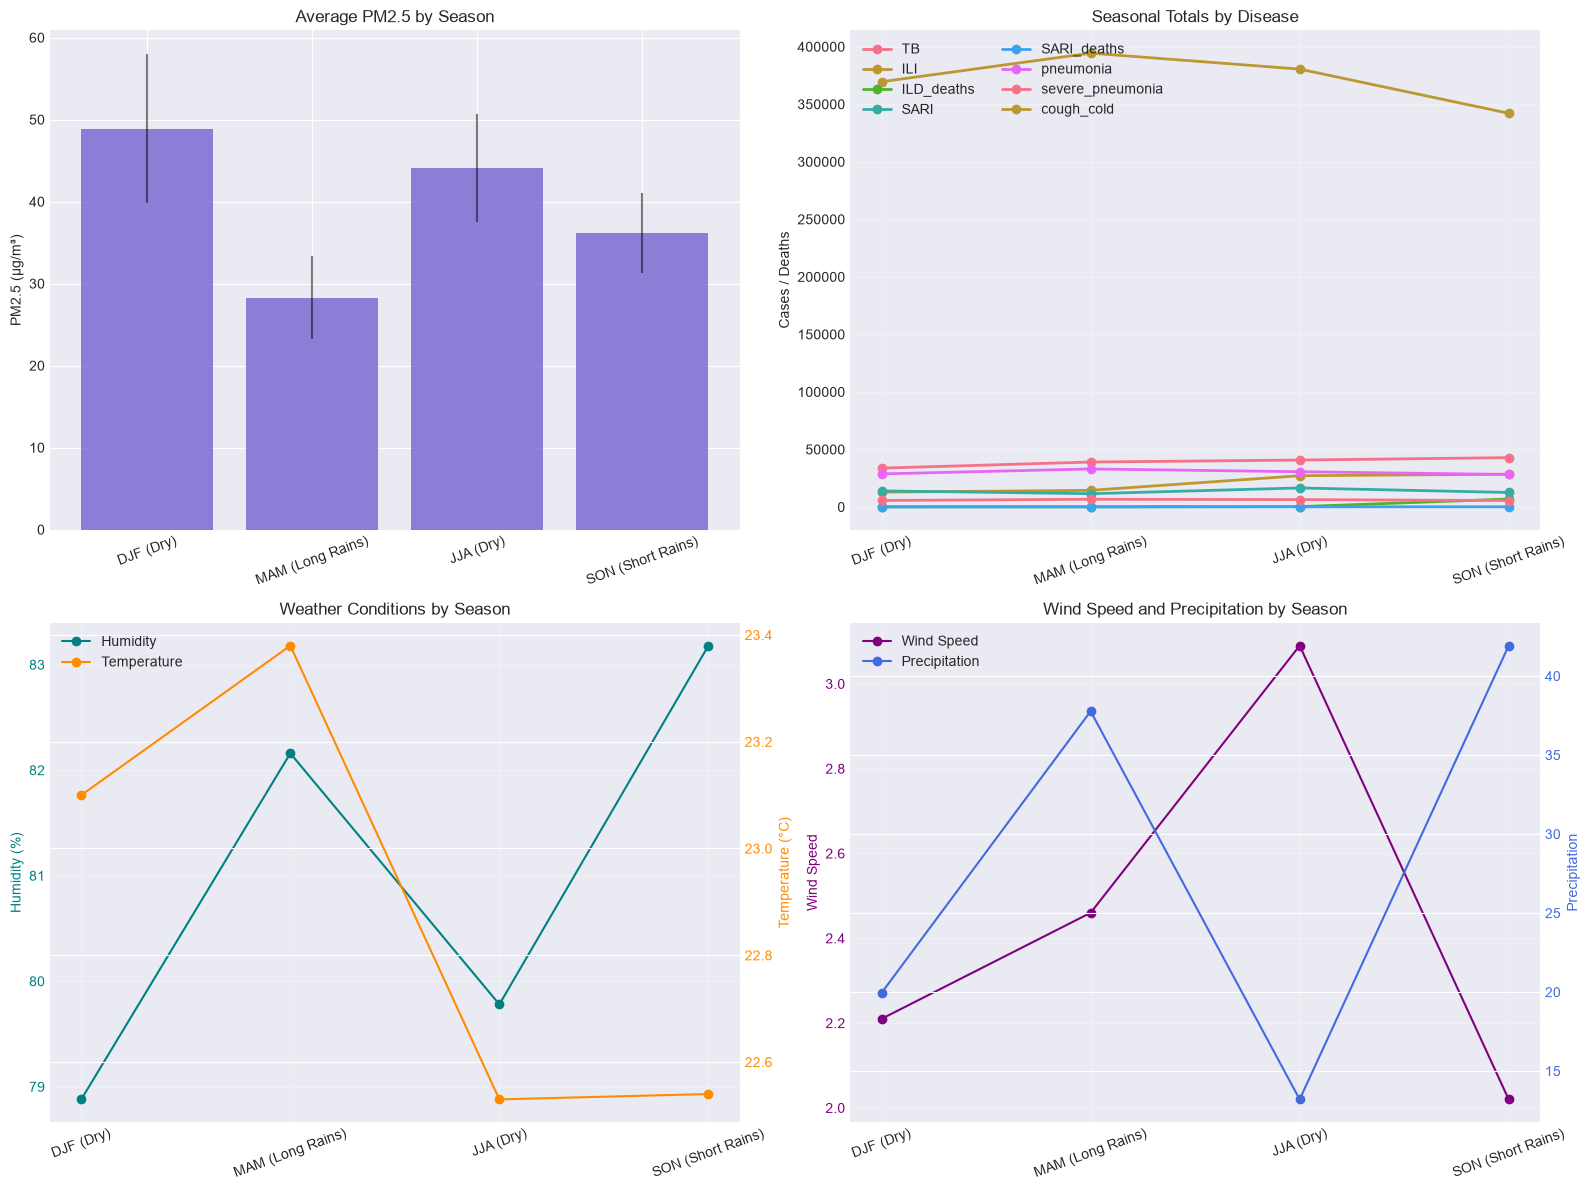

(            TB      ILI  ILD_deaths  SARI  SARI_deaths  pneumonia  \
 month                                                               
 1       9882.0   1914.0        33.0  6143         31.0       8639   
 2      12933.0   2626.0         7.0  3297         40.0      10077   
 3      14544.0   4307.0        34.0  4524         31.0      11444   
 4      11721.0   3346.0        21.0  3250         22.0      10434   
 5      12763.0   6790.0        92.0  3750         12.0      11137   
 6      11683.0   4954.0       155.0  5616         61.0      11959   
 7      14643.0   8647.0        49.0  5563         57.0       9512   
 8      14429.0  13540.0        99.0  5338         29.0       9156   
 9      14685.0  11349.0        30.0  4119         72.0       8391   
 10     14372.0   7344.0        33.0  4474         36.0       9697   
 11     13788.0   9788.0      6801.0  3990         38.0      10119   
 12     10930.0   8343.0        45.0  4527         22.0      10006   
 
        severe_pne

In [101]:
# Monthly and seasonal patterns across all diseases and key features
processed_data['month'] = processed_data['date'].dt.month
processed_data['season'] = processed_data['month'].map({
    12: 'DJF (Dry)', 1: 'DJF (Dry)', 2: 'DJF (Dry)',
    3: 'MAM (Long Rains)', 4: 'MAM (Long Rains)', 5: 'MAM (Long Rains)',
    6: 'JJA (Dry)', 7: 'JJA (Dry)', 8: 'JJA (Dry)',
    9: 'SON (Short Rains)', 10: 'SON (Short Rains)', 11: 'SON (Short Rains)'
})

disease_cols = [
    col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
    if col in processed_data.columns
]
monthly_feature_cols = [
    col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip']
    if col in processed_data.columns
]
monthly_agg = {col: ['mean', 'std'] for col in monthly_feature_cols}
monthly_agg.update({col: ['mean', 'sum'] for col in disease_cols})
monthly_stats = processed_data.groupby('month').agg(monthly_agg).reindex(range(1, 13)).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(range(1, 13), monthly_stats['pm2_5']['mean'].values, color='blue', alpha=0.7)
axes[0, 0].errorbar(
    range(1, 13),
    monthly_stats['pm2_5']['mean'].values,
    yerr=monthly_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].set_xticks(range(1, 13))

for disease in disease_cols:
    axes[0, 1].plot(range(1, 13), monthly_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Monthly Totals by Disease')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

monthly_weather_ax = axes[1, 0]
monthly_temperature_ax = monthly_weather_ax.twinx()
monthly_weather_ax.plot(range(1, 13), monthly_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
monthly_temperature_ax.plot(range(1, 13), monthly_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
monthly_weather_ax.set_title('Weather Conditions by Month')
monthly_weather_ax.set_xlabel('Month')
monthly_weather_ax.set_ylabel('Humidity (%)', color='teal')
monthly_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
monthly_weather_ax.tick_params(axis='y', labelcolor='teal')
monthly_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
monthly_weather_ax.set_xticks(range(1, 13))
monthly_weather_ax.grid(True, alpha=0.3)
monthly_handles, monthly_labels = monthly_weather_ax.get_legend_handles_labels()
monthly_temp_handles, monthly_temp_labels = monthly_temperature_ax.get_legend_handles_labels()
monthly_weather_ax.legend(monthly_handles + monthly_temp_handles, monthly_labels + monthly_temp_labels, loc='upper left')

monthly_wind_ax = axes[1, 1]
monthly_precip_ax = monthly_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    monthly_wind_ax.plot(range(1, 13), monthly_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    monthly_precip_ax.plot(range(1, 13), monthly_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
monthly_wind_ax.set_title('Wind Speed and Precipitation by Month')
monthly_wind_ax.set_xlabel('Month')
monthly_wind_ax.set_ylabel('Wind Speed', color='purple')
monthly_precip_ax.set_ylabel('Precipitation', color='royalblue')
monthly_wind_ax.tick_params(axis='y', labelcolor='purple')
monthly_precip_ax.tick_params(axis='y', labelcolor='royalblue')
monthly_wind_ax.set_xticks(range(1, 13))
monthly_wind_ax.grid(True, alpha=0.3)
monthly_wind_handles, monthly_wind_labels = monthly_wind_ax.get_legend_handles_labels()
monthly_precip_handles, monthly_precip_labels = monthly_precip_ax.get_legend_handles_labels()
monthly_wind_ax.legend(monthly_wind_handles + monthly_precip_handles, monthly_wind_labels + monthly_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

season_order = ['DJF (Dry)', 'MAM (Long Rains)', 'JJA (Dry)', 'SON (Short Rains)']
seasonal_stats = processed_data.groupby('season').agg(monthly_agg).reindex(season_order).round(2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(season_order, seasonal_stats['pm2_5']['mean'].values, color='slateblue', alpha=0.75)
axes[0, 0].errorbar(
    season_order,
    seasonal_stats['pm2_5']['mean'].values,
    yerr=seasonal_stats['pm2_5']['std'].fillna(0).values,
    fmt='none',
    color='black',
    alpha=0.5
)
axes[0, 0].set_title('Average PM2.5 by Season')
axes[0, 0].set_ylabel('PM2.5 (μg/m³)')
axes[0, 0].tick_params(axis='x', rotation=20)

for disease in disease_cols:
    axes[0, 1].plot(season_order, seasonal_stats[disease]['sum'].values, marker='o', linewidth=2, label=disease)
axes[0, 1].set_title('Seasonal Totals by Disease')
axes[0, 1].set_ylabel('Cases / Deaths')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend(loc='upper left', ncol=2)
axes[0, 1].grid(True, alpha=0.3)

seasonal_weather_ax = axes[1, 0]
seasonal_temperature_ax = seasonal_weather_ax.twinx()
seasonal_weather_ax.plot(season_order, seasonal_stats['avghumidity']['mean'].values, 'o-', color='teal', label='Humidity')
seasonal_temperature_ax.plot(season_order, seasonal_stats['avgtemp']['mean'].values, 'o-', color='darkorange', label='Temperature')
seasonal_weather_ax.set_title('Weather Conditions by Season')
seasonal_weather_ax.set_ylabel('Humidity (%)', color='teal')
seasonal_temperature_ax.set_ylabel('Temperature (°C)', color='darkorange')
seasonal_weather_ax.tick_params(axis='y', labelcolor='teal')
seasonal_temperature_ax.tick_params(axis='y', labelcolor='darkorange')
seasonal_weather_ax.tick_params(axis='x', rotation=20)
seasonal_weather_ax.grid(True, alpha=0.3)
seasonal_handles, seasonal_labels = seasonal_weather_ax.get_legend_handles_labels()
seasonal_temp_handles, seasonal_temp_labels = seasonal_temperature_ax.get_legend_handles_labels()
seasonal_weather_ax.legend(seasonal_handles + seasonal_temp_handles, seasonal_labels + seasonal_temp_labels, loc='upper left')

seasonal_wind_ax = axes[1, 1]
seasonal_precip_ax = seasonal_wind_ax.twinx()
if 'windspeed' in monthly_feature_cols:
    seasonal_wind_ax.plot(season_order, seasonal_stats['windspeed']['mean'].values, 'o-', color='purple', label='Wind Speed')
if 'precip' in monthly_feature_cols:
    seasonal_precip_ax.plot(season_order, seasonal_stats['precip']['mean'].values, 'o-', color='royalblue', label='Precipitation')
seasonal_wind_ax.set_title('Wind Speed and Precipitation by Season')
seasonal_wind_ax.set_ylabel('Wind Speed', color='purple')
seasonal_precip_ax.set_ylabel('Precipitation', color='royalblue')
seasonal_wind_ax.tick_params(axis='y', labelcolor='purple')
seasonal_precip_ax.tick_params(axis='y', labelcolor='royalblue')
seasonal_wind_ax.tick_params(axis='x', rotation=20)
seasonal_wind_ax.grid(True, alpha=0.3)
seasonal_wind_handles, seasonal_wind_labels = seasonal_wind_ax.get_legend_handles_labels()
seasonal_precip_handles, seasonal_precip_labels = seasonal_precip_ax.get_legend_handles_labels()
seasonal_wind_ax.legend(seasonal_wind_handles + seasonal_precip_handles, seasonal_wind_labels + seasonal_precip_labels, loc='upper left')

plt.tight_layout()
plt.show()

monthly_disease_totals = monthly_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
monthly_disease_totals.columns = [col for col, _ in monthly_disease_totals.columns]
seasonal_disease_totals = seasonal_stats.loc[:, pd.IndexSlice[disease_cols, 'sum']]
seasonal_disease_totals.columns = [col for col, _ in seasonal_disease_totals.columns]

monthly_disease_totals, seasonal_disease_totals


## 6. Spatial and facility heterogeneity

Division-level maps and facility records are presented here to assess geographic heterogeneity. They are descriptive unless the data support an explicitly adjusted multilevel model.


,metric,value
0,medical_records_linked_window,5006
1,parish_exact_or_reviewed_match,2425
2,records_with_same_day_division_pm25,3632
3,monitor_days,1596
4,monitor_sites,9


,division,mean_pm25,recorded_cases,mean_rate_per_100k,monitor_sites,records,parish_matched,pm25_matched
0,Kampala Central,42.932374,105,23.645661,1.000000,321,28,105
1,Kawempe,40.535897,276,4.006301,2.441534,350,51,278
2,Makindye,44.564249,953,5.227612,1.623804,1103,485,961
3,Nakawa,32.312696,1077,10.052114,1.719415,1333,649,1099
4,Rubaga,60.494402,1175,9.130600,1.000000,1899,1212,1189


,division,sex,age_band,diagnosis,recorded_cases,mean_pm25,mean_rate_per_100k,periods
0,Kampala Central,Female,0-4,Tuberculosis,1,40.994150,34.583507,1
1,Kampala Central,Female,13-18,Tuberculosis,1,16.611675,26.393857,1
2,Kampala Central,Female,19-64,Pneumonia,2,47.043354,4.008711,2
3,Kampala Central,Female,19-64,Severe Acute Respiratory Infections,5,31.610974,20.043553,1
4,Kampala Central,Female,19-64,Tuberculosis,16,47.099034,8.017421,8
5,Kampala Central,Female,6-12,Tuberculosis,2,51.802729,53.329778,1
6,Kampala Central,Female,65+,Severe Acute Respiratory Infections,1,44.441475,140.605065,1
7,Kampala Central,Female,65+,Severe Pneumonia,1,57.265304,140.605065,1
8,Kampala Central,Male,0-4,Tuberculosis,2,38.242144,48.002516,1
9,Kampala Central,Male,13-18,Tuberculosis,4,25.127146,24.423426,3


,division,parish_raw,parish_key,parish_matched,records,first_visit,last_visit
388,Nakawa,Mbuya,mbuya,False,148,2020-01-07,2024-10-18
402,Nakawa,Naguru,naguru,False,132,2020-01-03,2024-08-08
240,Makindye,Makindye,makindye,False,107,2020-01-14,2024-11-19
287,Makindye,Nsambya,nsambya,False,85,2020-02-06,2024-12-05
462,Rubaga,Kawaala,kawaala,False,85,2020-01-28,2024-12-02
494,Rubaga,Kitebi,kitebi,False,77,2020-05-11,2024-12-09
30,Kampala Central,Kisenyi,kisenyi,False,75,2020-04-15,2024-08-05
588,Rubaga,Wankulukuku,wankulukuku,False,55,2020-05-27,2024-12-07
93,Kawempe,Kawempe,kawempe,False,52,2020-01-06,2024-08-07
17,Kampala Central,Kamwokya,kamwokya,False,50,2020-02-18,2024-03-11


,diagnosis,status,n,within_division_irr_per_10ug_m3,ci_low,ci_high,pearson_overdispersion
0,Influenza Like Illness,ok,58,1.118591,0.938851,1.332742,0.358769
1,Pneumonia,ok,120,1.024058,0.928869,1.129002,0.362938
2,Severe Acute Respiratory Infections,ok,51,0.905063,0.630273,1.299659,0.739943
3,Severe Pneumonia,insufficient data,14,NaN,NaN,NaN,NaN
4,Tuberculosis,ok,654,0.963383,0.925743,1.002554,0.451646


,diagnosis,odds_ratio_per_10ug_m3,ci_low,ci_high,n,status
0,Influenza Like Illness,1.748975,1.489936,2.053051,3586,ok
1,Pneumonia,0.902058,0.806352,1.009125,3586,ok
2,Severe Acute Respiratory Infections,0.883850,0.778026,1.004068,3586,ok
3,Severe Pneumonia,NaN,NaN,NaN,3586,insufficient cases
4,Tuberculosis,0.847829,0.778940,0.922811,3586,ok


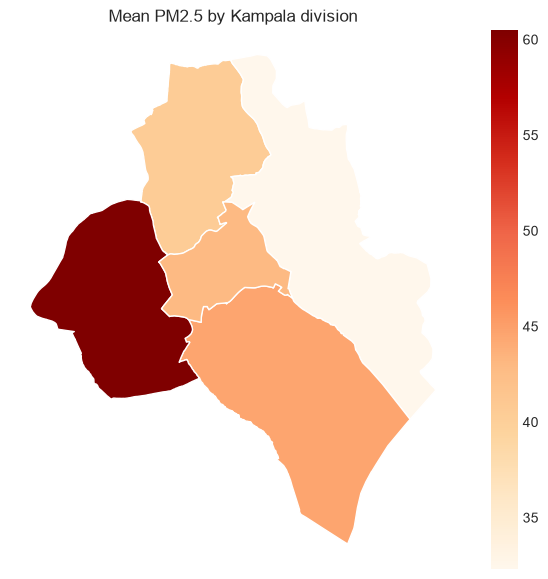

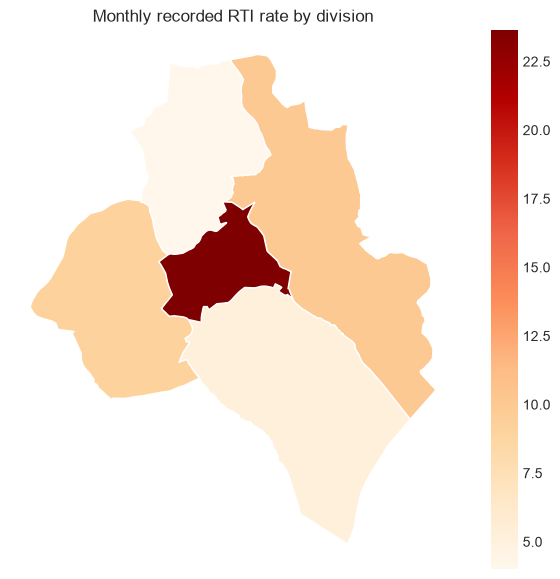

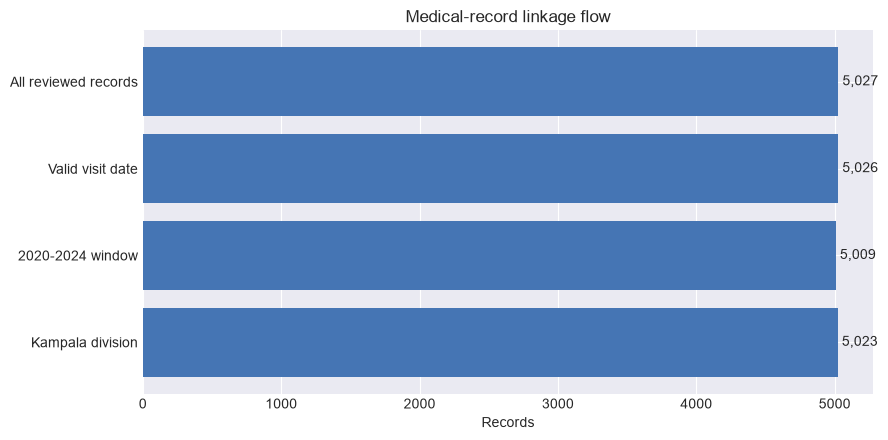

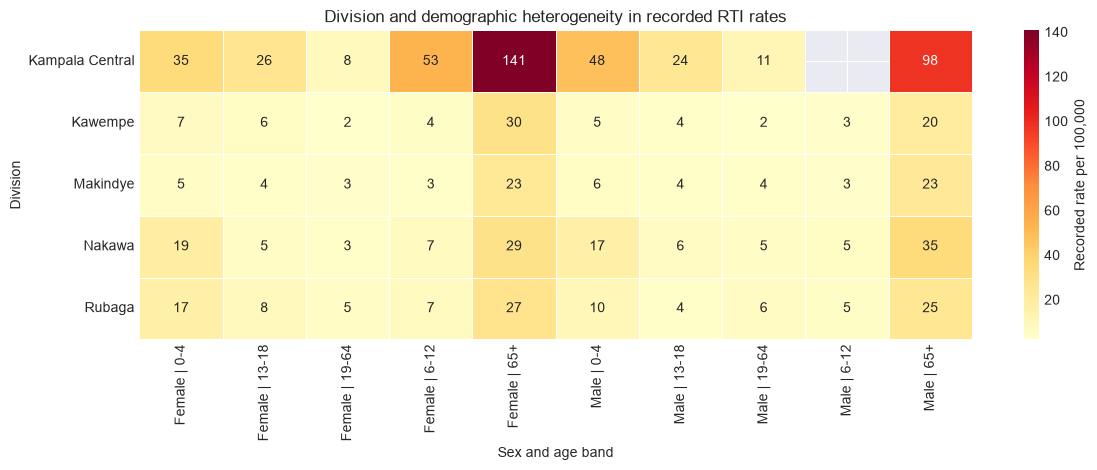

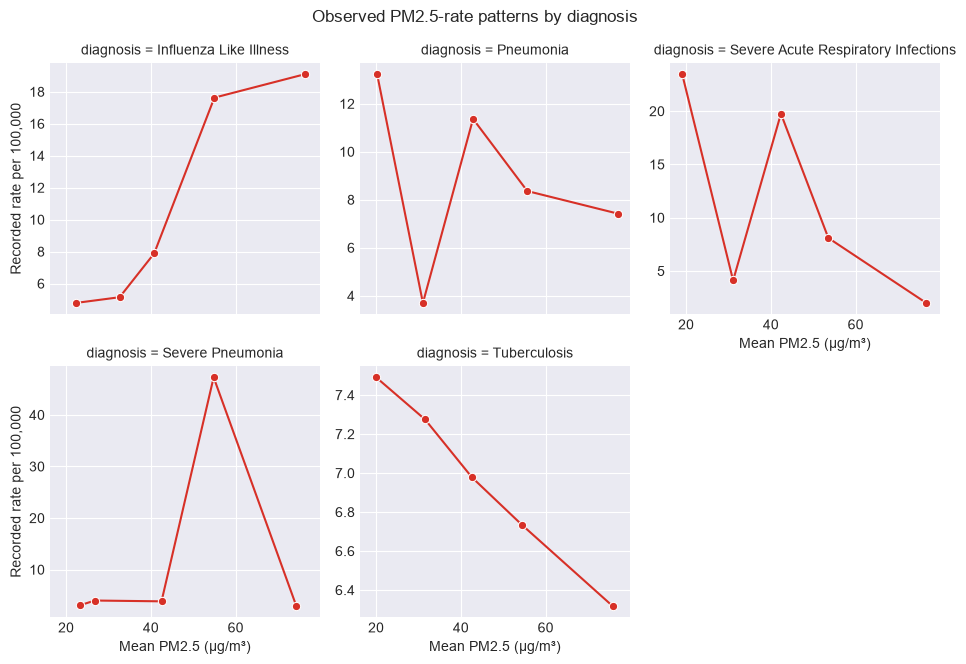

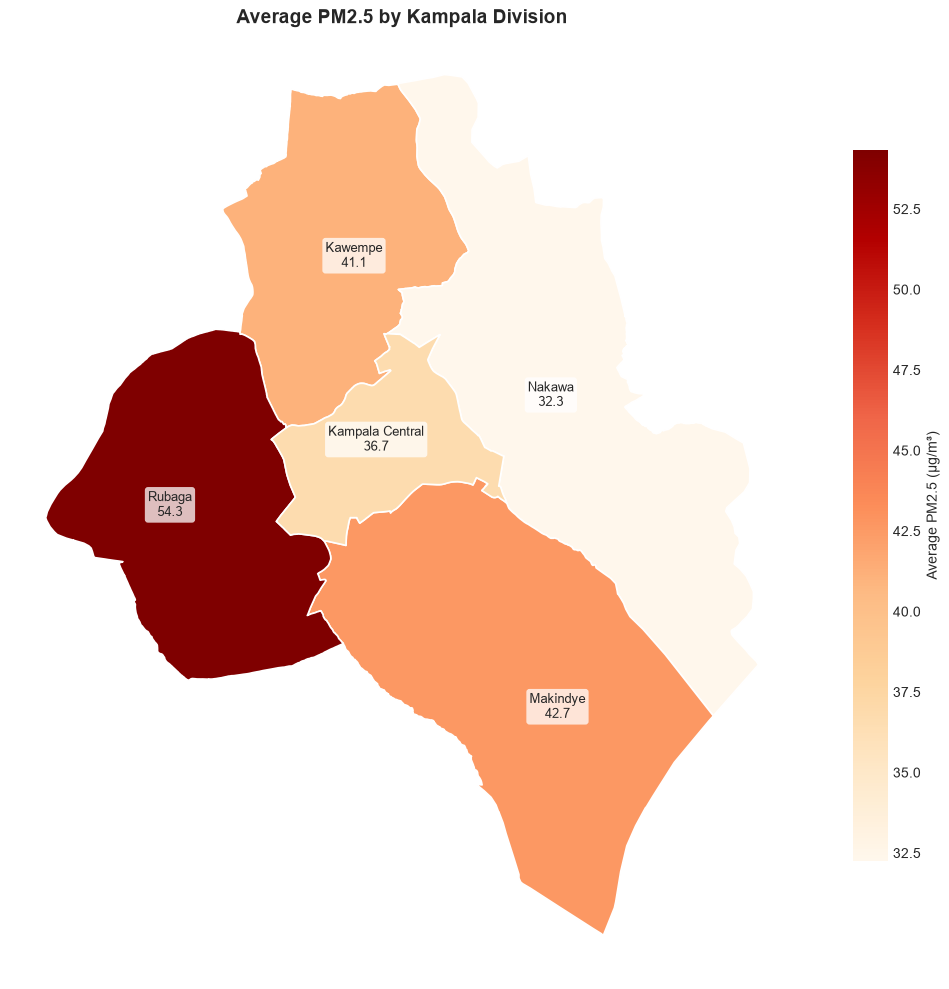

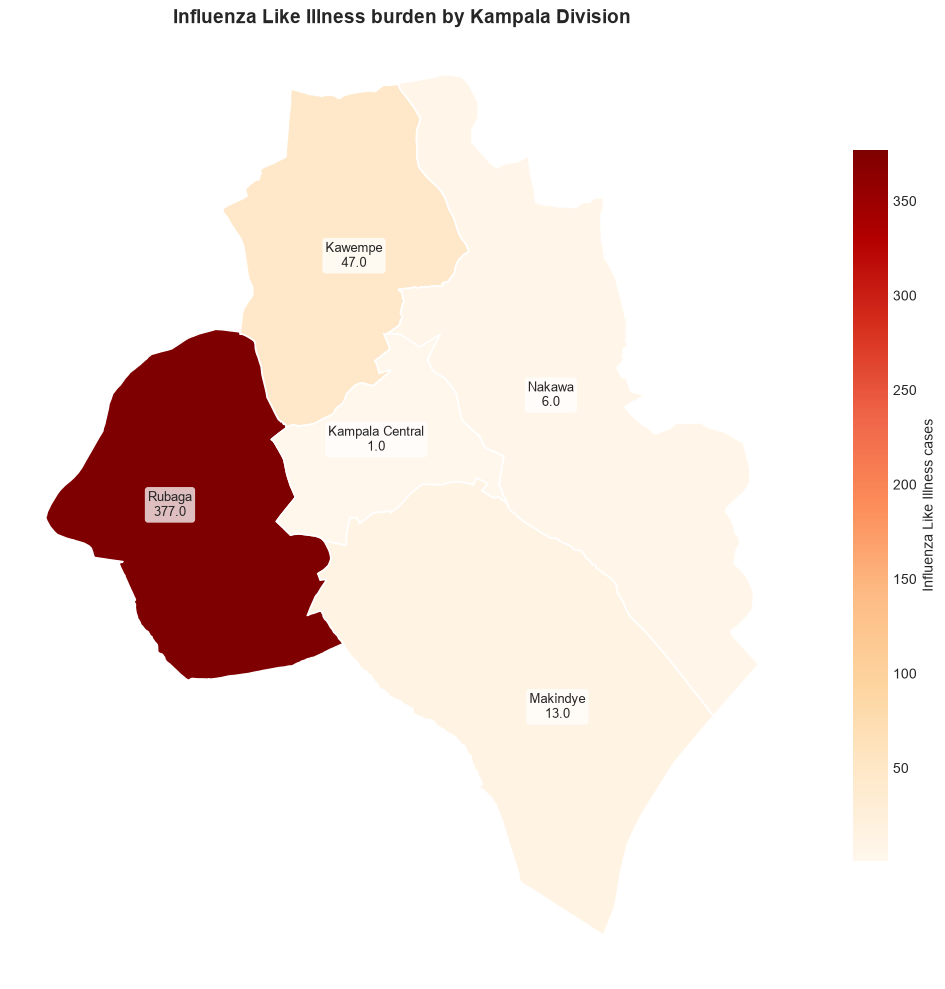

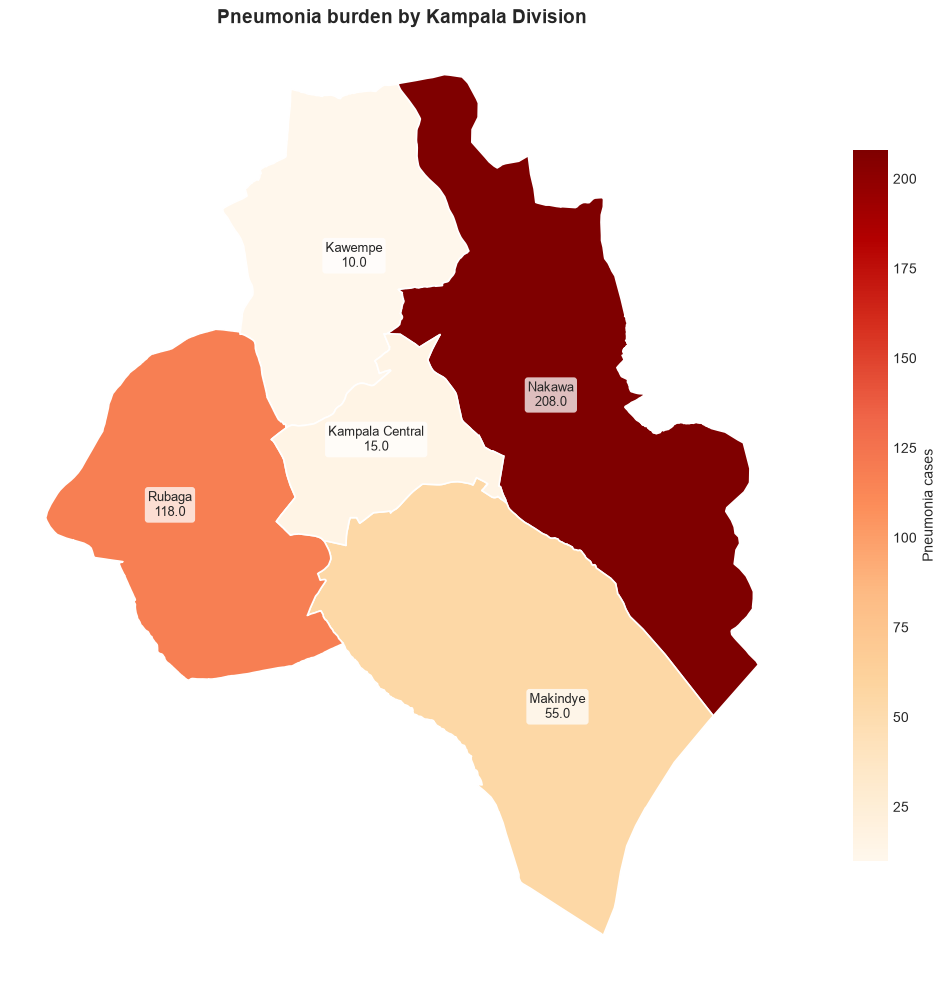

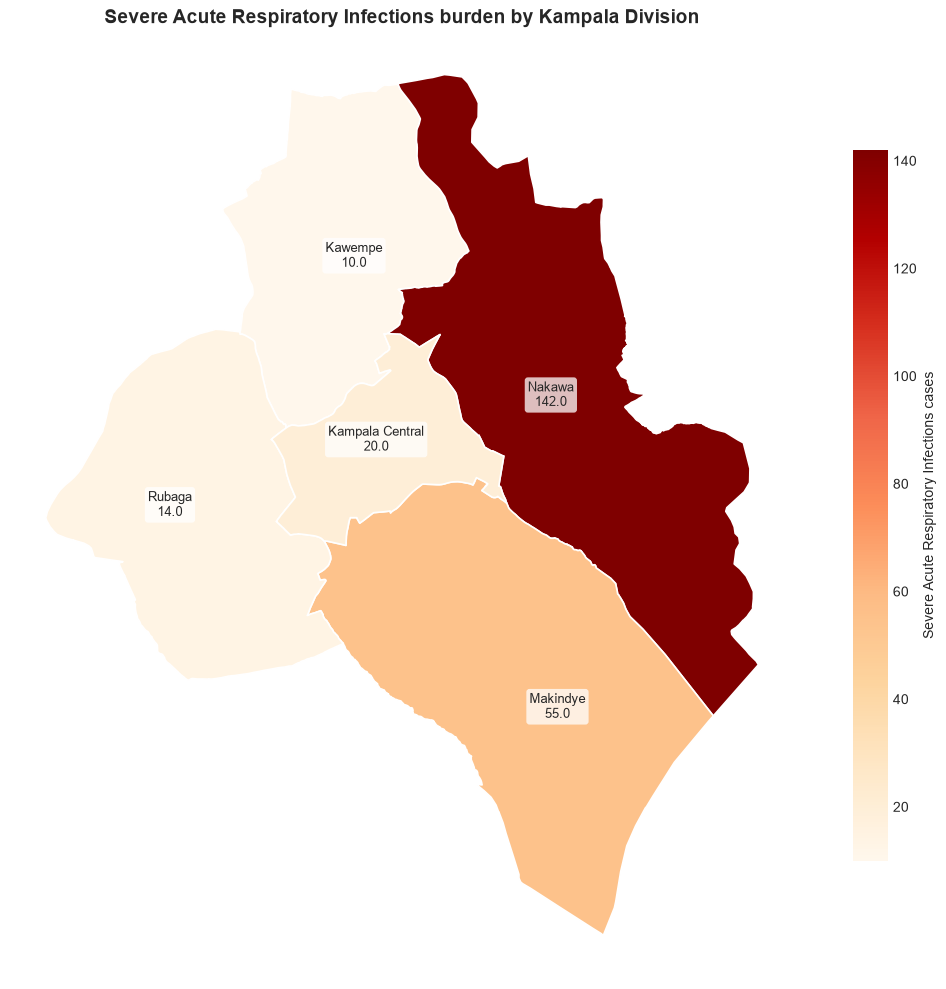

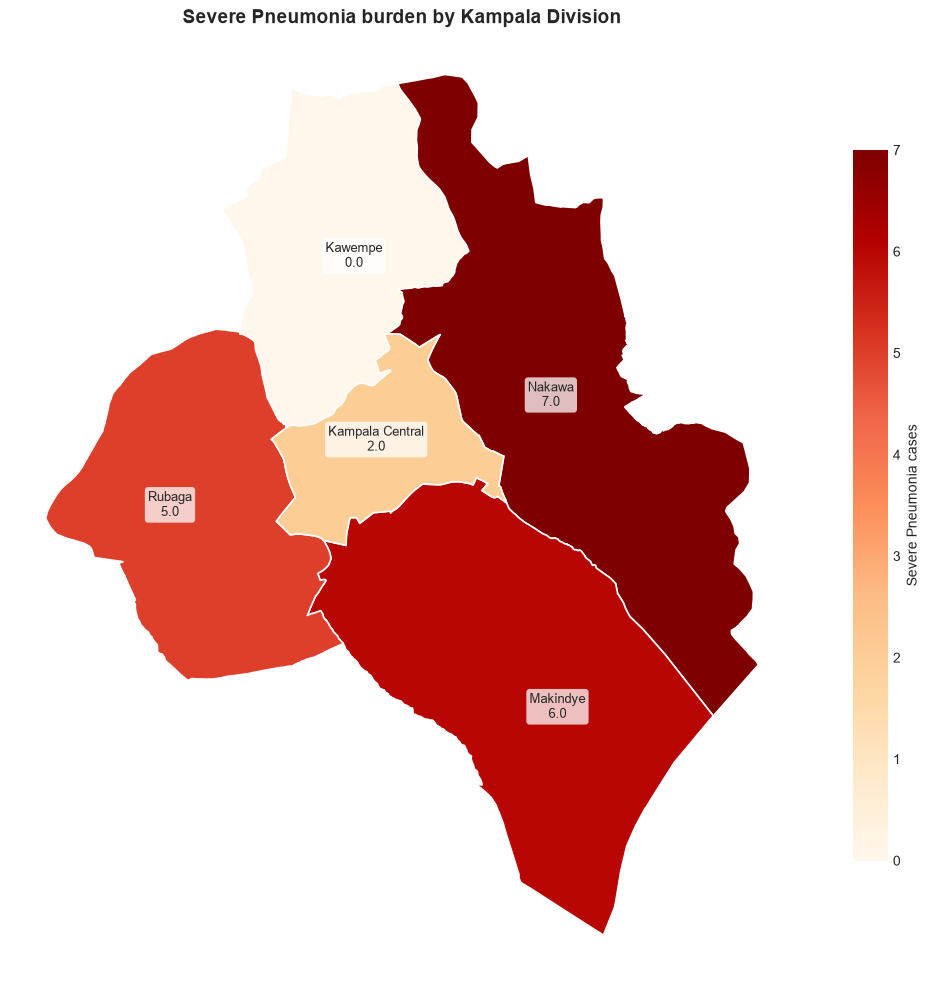

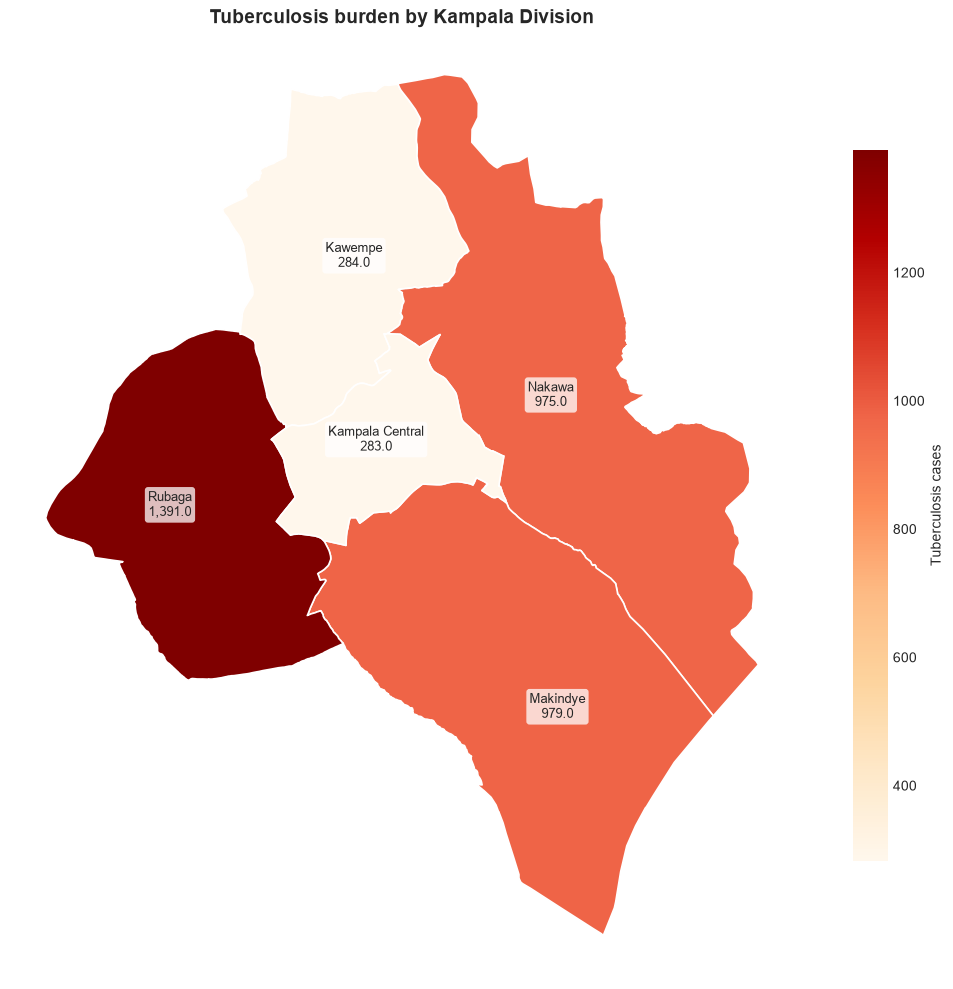

,division,mean_pm25,median_pm25,sensor_sites,monitoring_records,total_respiratory_cases,unique_parishes,disease__Influenza Like Illness,disease__Pneumonia,disease__Severe Acute Respiratory Infections,disease__Severe Pneumonia,disease__Tuberculosis
3,Rubaga,54.334055,47.73570,1,24877,1905,171,377,118,14,5,1391
2,Makindye,42.694804,33.44750,2,53377,1108,157,13,55,55,6,979
0,Kawempe,41.058471,31.79715,3,81720,351,76,47,10,10,0,284
4,Kampala Central,36.725346,30.46185,1,13214,321,71,1,15,20,2,283
1,Nakawa,32.264413,25.41410,2,40520,1338,114,6,208,142,7,975


In [102]:
# Enhanced spatial analysis: flow, PM2.5-rate response, and demographic heterogeneity
import importlib
import src.kampala_health_analysis as kampala_health_analysis
importlib.reload(kampala_health_analysis)
from src.kampala_health_analysis import (build_spatial_panel, demographic_spatial_summary, fit_case_mix_model, fit_spatial_rate_models, load_medical_records, parish_linkage_summary, plot_demographic_rate_heatmap, plot_division_map as plot_enhanced_division_map, plot_exposure_response, plot_medical_record_flow, spatial_summary)
spatial_rate_panel, medical_records, spatial_quality = build_spatial_panel(frequency='M')
enhanced_spatial_summary = spatial_summary(spatial_rate_panel, medical_records)
spatial_demographic_summary = demographic_spatial_summary(spatial_rate_panel)
spatial_rate_models = fit_spatial_rate_models(spatial_rate_panel); case_mix_models = fit_case_mix_model(medical_records)
display(spatial_quality, enhanced_spatial_summary, spatial_demographic_summary.head(20), parish_linkage_summary(medical_records).head(20), spatial_rate_models, case_mix_models)
plot_enhanced_division_map(enhanced_spatial_summary, 'mean_pm25', 'Mean PM2.5 by Kampala division')
plot_enhanced_division_map(enhanced_spatial_summary, 'mean_rate_per_100k', 'Monthly recorded RTI rate by division')
plot_medical_record_flow(load_medical_records()); plot_demographic_rate_heatmap(spatial_rate_panel); plot_exposure_response(spatial_rate_panel); plt.show()
# Existing descriptive maps remain below.
# Spatial analysis: PM2.5 and burden for every recorded respiratory diagnosis
try:
    import geopandas as gpd
except ImportError as exc:
    raise ImportError('Spatial analysis requires geopandas in the active notebook environment.') from exc
from pathlib import Path

def standardize_division(value):
    if pd.isna(value):
        return np.nan
    mapping = {
        'kampala central': 'Kampala Central', 'central division': 'Kampala Central', 'central': 'Kampala Central',
        'kawempe': 'Kawempe', 'kawempe division': 'Kawempe', 'nakawa': 'Nakawa', 'nakawa division': 'Nakawa',
        'makindye': 'Makindye', 'makindye division': 'Makindye', 'rubaga': 'Rubaga',
        'rubaga division': 'Rubaga', 'lubaga': 'Rubaga', 'lubaga division': 'Rubaga',
    }
    return mapping.get(str(value).strip().lower(), str(value).strip().title())

base_path = Path('data')
shapefile_path = base_path / 'Kampala Shapefile' / 'KMA Subcounties.shp'
air_quality_paths = [base_path / 'bq-results-20260322-100500-1774173924222.csv', base_path / 'bq-results-20260322-100723-1774174052683.csv']
health_path = base_path / 'Exploring_the_Association_Between_Air_Quality_and_the_Burden_of_Respiratory_Tract_Infections_in_Greater_Kampala_Uganda_-_all_versions_-_labels_-_2026-06-23-13-15-43.xlsx'
kampala_order = ['Kampala Central', 'Kawempe', 'Makindye', 'Nakawa', 'Rubaga']
kampala_map = gpd.read_file(shapefile_path)
kampala_map['division'] = kampala_map['sname2019'].apply(standardize_division)
kampala_map = kampala_map[kampala_map['division'].isin(kampala_order)].drop_duplicates('division').copy()

air_spatial = pd.concat([pd.read_csv(path, usecols=['timestamp', 'site_id', 'site_name', 'pm2_5_calibrated_value', 'parish']) for path in air_quality_paths], ignore_index=True).drop_duplicates(subset=['timestamp', 'site_id'])
air_spatial['division'] = air_spatial['site_name'].str.split(',').str[-1].str.strip().apply(standardize_division)
air_spatial.loc[air_spatial['parish'].astype(str).str.contains('makindye division', case=False, na=False), 'division'] = 'Makindye'
air_spatial = air_spatial[air_spatial['division'].isin(kampala_order)]
division_pm25 = air_spatial.groupby('division', as_index=False).agg(mean_pm25=('pm2_5_calibrated_value', 'mean'), median_pm25=('pm2_5_calibrated_value', 'median'), monitoring_records=('pm2_5_calibrated_value', 'size'), sensor_sites=('site_id', 'nunique'))

health_spatial = pd.read_excel(health_path)
health_spatial['division'] = health_spatial['10. Division (Kampala)'].apply(standardize_division)
health_spatial['diagnosis'] = health_spatial['3. Patient Diagnosis'].fillna('Unknown').astype(str).str.strip()
health_spatial = health_spatial[health_spatial['division'].isin(kampala_order)]
diagnosis_burden = health_spatial.groupby(['division', 'diagnosis']).size().unstack(fill_value=0)
diagnosis_burden.columns = [f'disease__{name}' for name in diagnosis_burden.columns]
spatial_summary = kampala_map[['division', 'geometry']].merge(division_pm25, on='division', how='left').merge(diagnosis_burden.reset_index(), on='division', how='left')
burden_columns = [col for col in spatial_summary.columns if col.startswith('disease__')]
for col in ['mean_pm25', 'median_pm25', 'monitoring_records', 'sensor_sites', *burden_columns]:
    spatial_summary[col] = spatial_summary[col].fillna(0)
spatial_summary['total_respiratory_cases'] = spatial_summary[burden_columns].sum(axis=1)
spatial_summary['unique_parishes'] = spatial_summary['division'].map(health_spatial.groupby('division')['12. Parish name:'].nunique()).fillna(0)

def plot_division_map(frame, column, title, label):
    fig, ax = plt.subplots(figsize=(12, 10))
    frame.plot(column=column, cmap='OrRd', linewidth=1.2, edgecolor='white', legend=True, ax=ax, legend_kwds={'label': label, 'shrink': 0.75})
    for point, division, value in zip(frame.geometry.representative_point(), frame['division'], frame[column]):
        ax.annotate(f'{division}\n{value:,.1f}', (point.x, point.y), ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.75))
    ax.set_title(title, fontsize=14, fontweight='bold'); ax.set_axis_off(); plt.tight_layout(); plt.show()

plot_division_map(spatial_summary, 'mean_pm25', 'Average PM2.5 by Kampala Division', 'Average PM2.5 (μg/m³)')
for burden_column in burden_columns:
    disease_name = burden_column.removeprefix('disease__')
    plot_division_map(spatial_summary, burden_column, f'{disease_name} burden by Kampala Division', f'{disease_name} cases')
spatial_summary_table = spatial_summary[['division', 'mean_pm25', 'median_pm25', 'sensor_sites', 'monitoring_records', 'total_respiratory_cases', 'unique_parishes', *burden_columns]].sort_values('mean_pm25', ascending=False)
spatial_summary_table


## Step 4: Time Series Modeling


### 7. Sensitivity analyses

The sensitivity table compares the primary PM₂.₅ estimate with alternatives that exclude high-PM₂.₅ observations and use a lagged exposure. Consistency in direction and magnitude strengthens robustness; discrepancies should be reported rather than reconciled post hoc.


In [103]:
# Canonical monthly model: aggregate the weekly panel before modelling
import importlib, src.kampala_health_analysis as kampala_health_analysis
importlib.reload(kampala_health_analysis)
from src.kampala_health_analysis import aggregate_time_panel, fit_time_series_models, load_weekly_panel
canonical_monthly_panel = aggregate_time_panel(load_weekly_panel(), 'MS'); canonical_monthly_dlnm = fit_time_series_models(canonical_monthly_panel, max_lag=2)
display(canonical_monthly_dlnm)
# Existing sensitivity analyses remain below.
# Sensitivity analyses for every disease
sensitivity_specs = [('Primary adjusted model', processed_data.copy()), ('Exclude highest 5% PM2.5', processed_data[processed_data['pm2_5'] <= processed_data['pm2_5'].quantile(.95)].copy())]
lagged = processed_data.copy(); lagged['pm2_5'] = lagged['pm2_5'].shift(1); sensitivity_specs.append(('One-period lagged PM2.5', lagged))
sensitivity_results = []
for disease in disease_columns:
    for label, frame in sensitivity_specs:
        result = poisson_pm25_model(frame, disease, None)
        if result is not None: result.update({'Disease': disease, 'Specification': label}); sensitivity_results.append(result)
sensitivity_results = pd.DataFrame(sensitivity_results)
display(sensitivity_results[['Disease', 'Specification', 'N', 'IRR per 10 µg/m³', '95% CI lower', '95% CI upper', 'p-value']].round(3))


,outcome,term,irr_per_10ug_m3,ci_low,ci_high,n,status
0,ILI,pm25_lag0,1.856982,1.321518,2.609409,58,ok
1,ILI,pm25_lag1,1.222816,0.876481,1.706003,58,ok
2,ILI,pm25_lag2,2.418611,1.554802,3.762329,58,ok
3,ILD_deaths,pm25_lag0,1.974062,0.445733,8.742732,34,ok
4,ILD_deaths,pm25_lag1,0.510003,0.151257,1.719614,34,ok
5,ILD_deaths,pm25_lag2,0.653721,0.161281,2.649729,34,ok
6,pneumonia_u5,pm25_lag0,0.977780,0.856042,1.116829,58,ok
7,pneumonia_u5,pm25_lag1,0.819623,0.704652,0.953352,58,ok
8,pneumonia_u5,pm25_lag2,1.087118,0.939859,1.257449,58,ok
9,SARI,pm25_lag0,1.033016,0.827205,1.290033,58,ok


,Disease,Specification,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value
0,TB,Primary adjusted model,60,0.928,0.860,1.000,0.051
1,TB,Exclude highest 5% PM2.5,57,0.966,0.895,1.042,0.370
2,TB,One-period lagged PM2.5,59,1.009,0.952,1.069,0.771
3,ILI,Primary adjusted model,60,1.120,0.843,1.489,0.435
4,ILI,Exclude highest 5% PM2.5,57,1.440,1.039,1.995,0.028
5,ILI,One-period lagged PM2.5,59,1.284,1.054,1.564,0.013
6,ILD_deaths,Primary adjusted model,60,3.314,0.548,20.041,0.192
7,ILD_deaths,Exclude highest 5% PM2.5,57,2.610,0.387,17.619,0.325
8,ILD_deaths,One-period lagged PM2.5,59,0.572,0.170,1.928,0.367
9,SARI,Primary adjusted model,60,1.033,0.865,1.233,0.723


### 4.1 Interrupted Time Series


#### 4.1.1 ITS Preparation and Counterfactual Estimation


In [104]:
# --- 1. Data Preprocessing ---
data_itsa = processed_data.copy()
date_source = processed_data['date'] if 'date' in processed_data.columns else processed_data['ds']
data_itsa['date'] = pd.to_datetime(date_source, errors='coerce', dayfirst=True)
data_itsa = data_itsa.dropna(subset=['date']).sort_values('date').set_index('date')


In [105]:
# Prepare all disease outcomes and environmental variables for interrupted time-series analysis
disease_columns = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in data_itsa.columns]
its_numeric_cols = [col for col in [*disease_columns, 'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip'] if col in data_itsa.columns]
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].apply(pd.to_numeric, errors='coerce')
data_itsa[its_numeric_cols] = data_itsa[its_numeric_cols].interpolate(limit_direction='both').ffill().bfill()
print(f'Prepared ITS data for {len(disease_columns)} disease outcomes and {len(its_numeric_cols)} numeric variables.')


Prepared ITS data for 8 disease outcomes and 13 numeric variables.


In [106]:
# --- 3. Define the Intervention Point ---
intervention_point = len(data_itsa) // 2
intervention_date = data_itsa.index[intervention_point]

print(f"\nThe dataset has {len(data_itsa)} data points.")
print(f"The intervention is set at index {intervention_point}, which corresponds to the date: {intervention_date.date()}")



The dataset has 60 data points.
The intervention is set at index 30, which corresponds to the date: 2022-07-01


In [107]:
# --- 4. Create Interrupted Time Series (ITS) Variables ---
data_itsa['time'] = np.arange(1, len(data_itsa) + 1)
data_itsa['intervention'] = (data_itsa.index >= intervention_date).astype(int)

data_itsa['time_since_intervention'] = 0
post_intervention_indices = data_itsa[data_itsa['intervention'] == 1].index
time_since_intervention_values = np.arange(len(post_intervention_indices))
data_itsa.loc[post_intervention_indices, 'time_since_intervention'] = time_since_intervention_values


In [108]:
# LSTM intervention-trend models for every disease outcome
disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in data_itsa.columns]
base_feature_cols = [col for col in ['pm2_5', 'avgtemp', 'avghumidity', 'avgtemp_sat', 'humidity_sat', 'windspeed', 'precip', 'time', 'intervention', 'time_since_intervention'] if col in data_itsa.columns]
sequence_length = 8
lstm_performance = []
for disease in disease_cols:
    model_df = data_itsa[base_feature_cols + [disease]].dropna(subset=[disease]).copy().fillna(0)
    if len(model_df) <= sequence_length + 2:
        continue
    feature_scaler, target_scaler = MinMaxScaler(), MinMaxScaler()
    scaled_features = feature_scaler.fit_transform(model_df[base_feature_cols])
    scaled_target = target_scaler.fit_transform(model_df[[disease]])
    X_all = np.array([scaled_features[i-sequence_length:i] for i in range(sequence_length, len(model_df))])
    y_all = scaled_target[sequence_length:]
    train_size = max(2, int(len(X_all) * 0.8))
    model = Sequential([LSTM(32, input_shape=(sequence_length, X_all.shape[2])), Dropout(0.2), Dense(16, activation='relu'), Dense(1)])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_all[:train_size], y_all[:train_size], epochs=150, batch_size=16, validation_split=0.2, verbose=0, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
    predicted = target_scaler.inverse_transform(model.predict(X_all, verbose=0)).flatten()
    prediction_column = f'predicted_{disease}'
    data_itsa[prediction_column] = data_itsa[disease].astype(float)
    data_itsa.loc[model_df.index[sequence_length:], prediction_column] = predicted
    actual = model_df[disease].iloc[sequence_length:]
    lstm_performance.append({'Disease': disease, 'RMSE': np.sqrt(mean_squared_error(actual, predicted)), 'MAE': mean_absolute_error(actual, predicted), 'Training windows': train_size})
lstm_performance = pd.DataFrame(lstm_performance)
lstm_performance


,Disease,RMSE,MAE,Training windows
0,TB,792.494036,606.270421,41
1,ILI,3057.173516,1348.120600,41
2,ILD_deaths,915.464175,261.282018,41
3,SARI,482.972793,293.884705,41
4,SARI_deaths,11.218778,7.100850,41
5,pneumonia,577.344811,418.757507,41
6,severe_pneumonia,225.082754,147.423599,41
7,cough_cold,4768.766297,3783.506348,41


### 4.2 Overall ITS Analysis of TB Cases


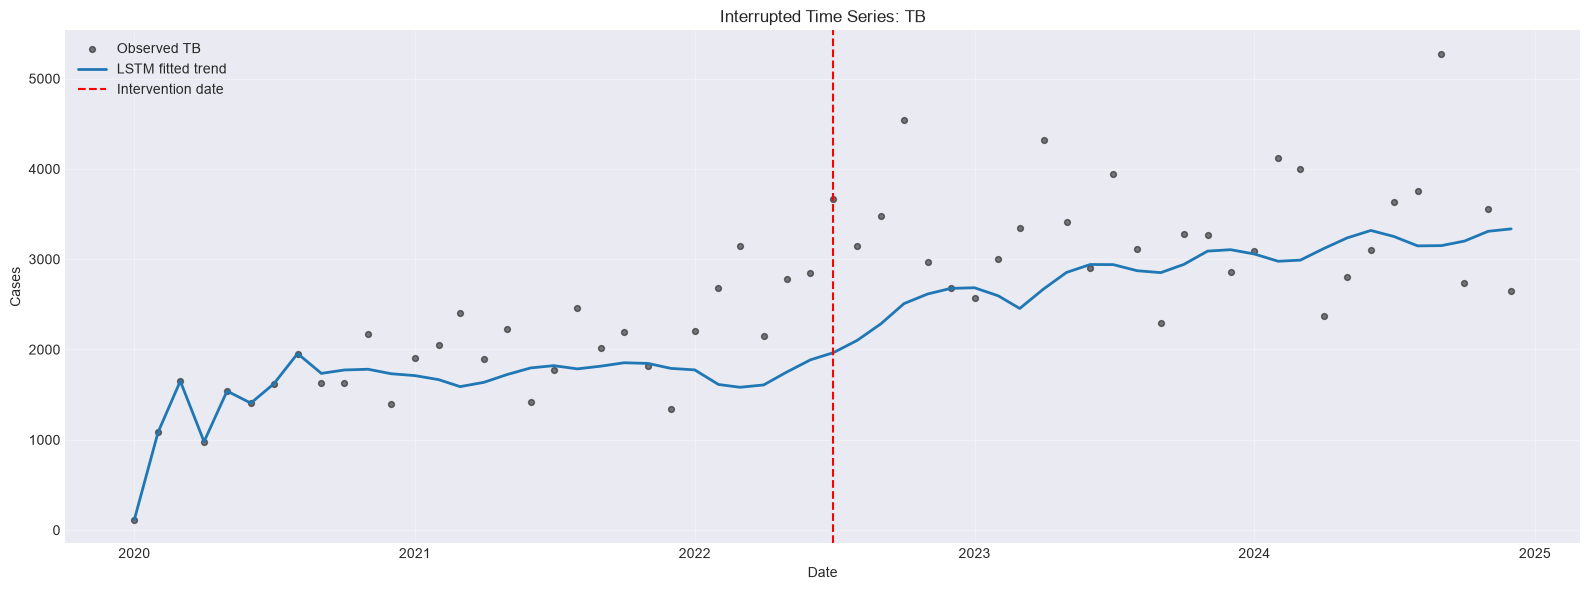

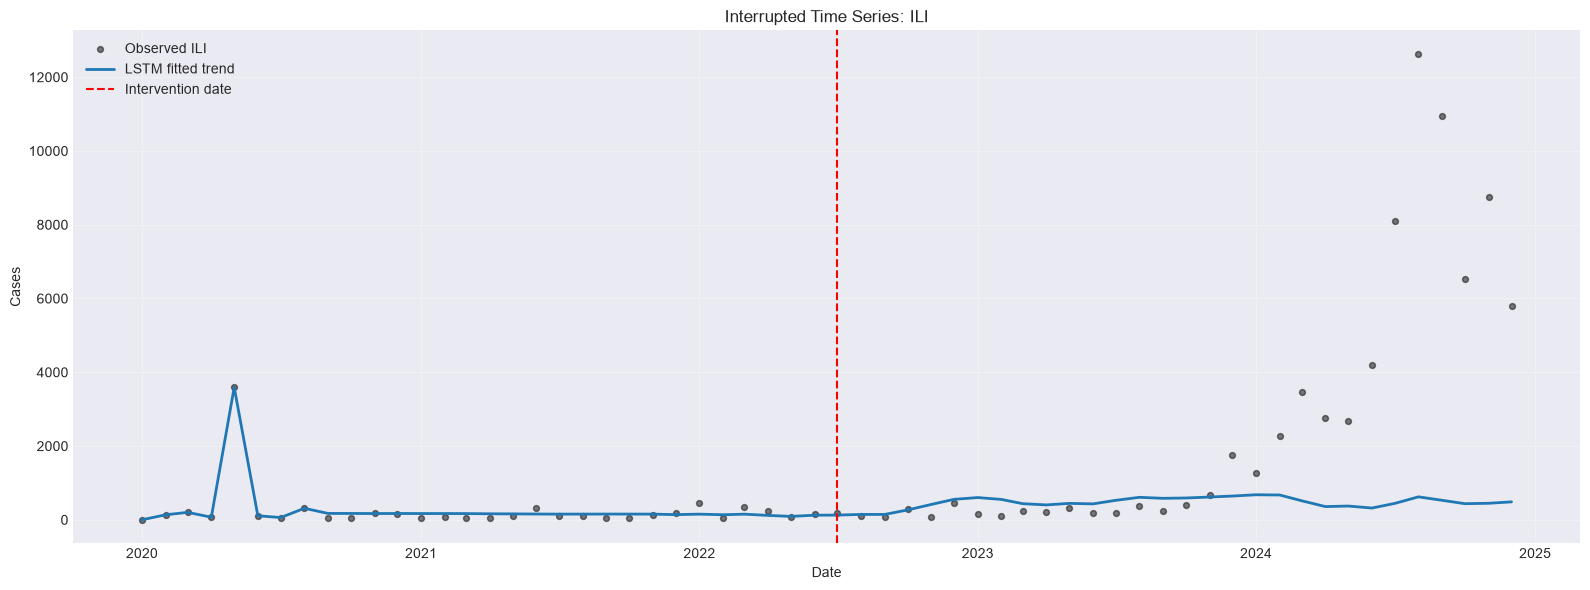

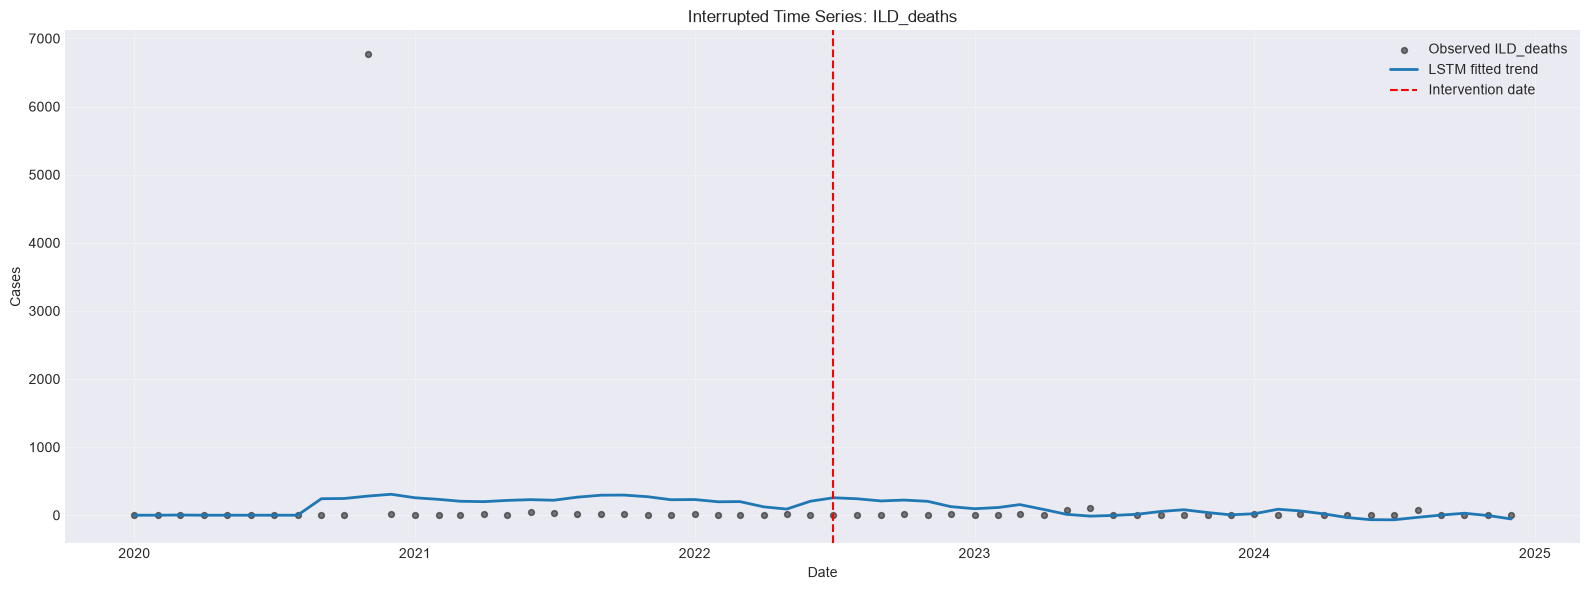

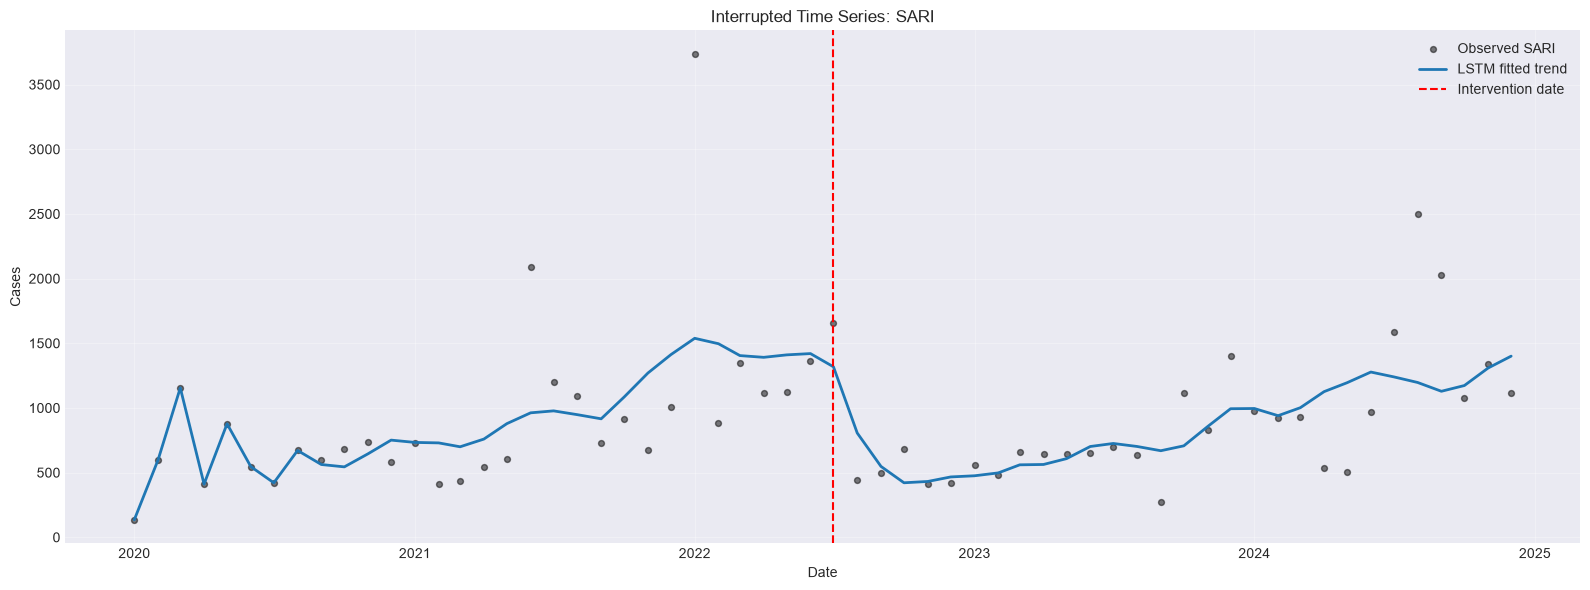

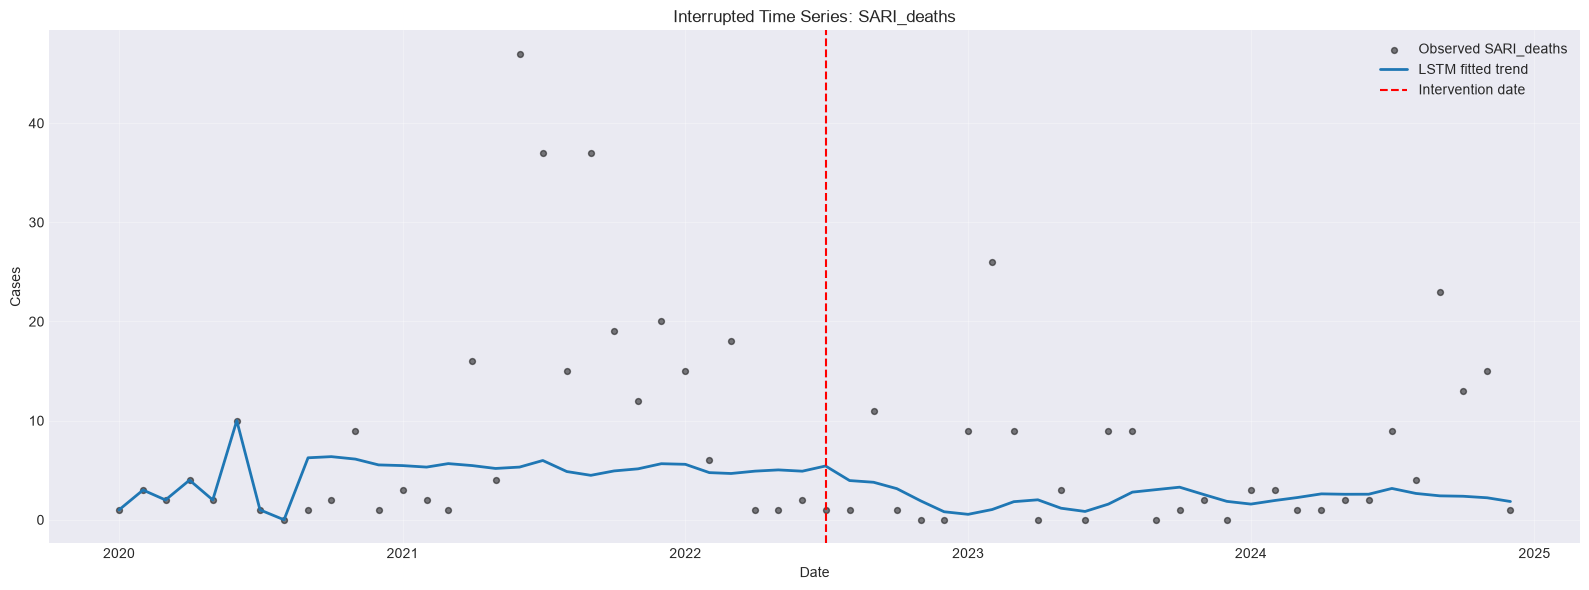

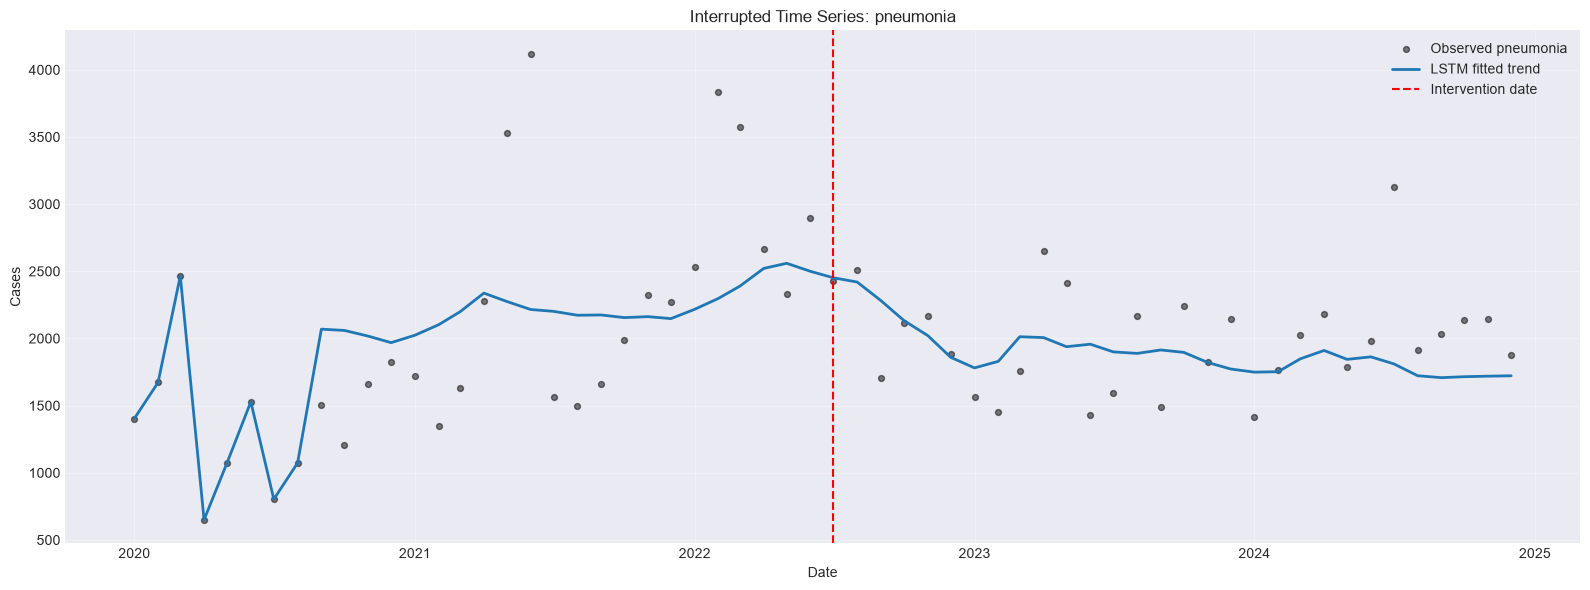

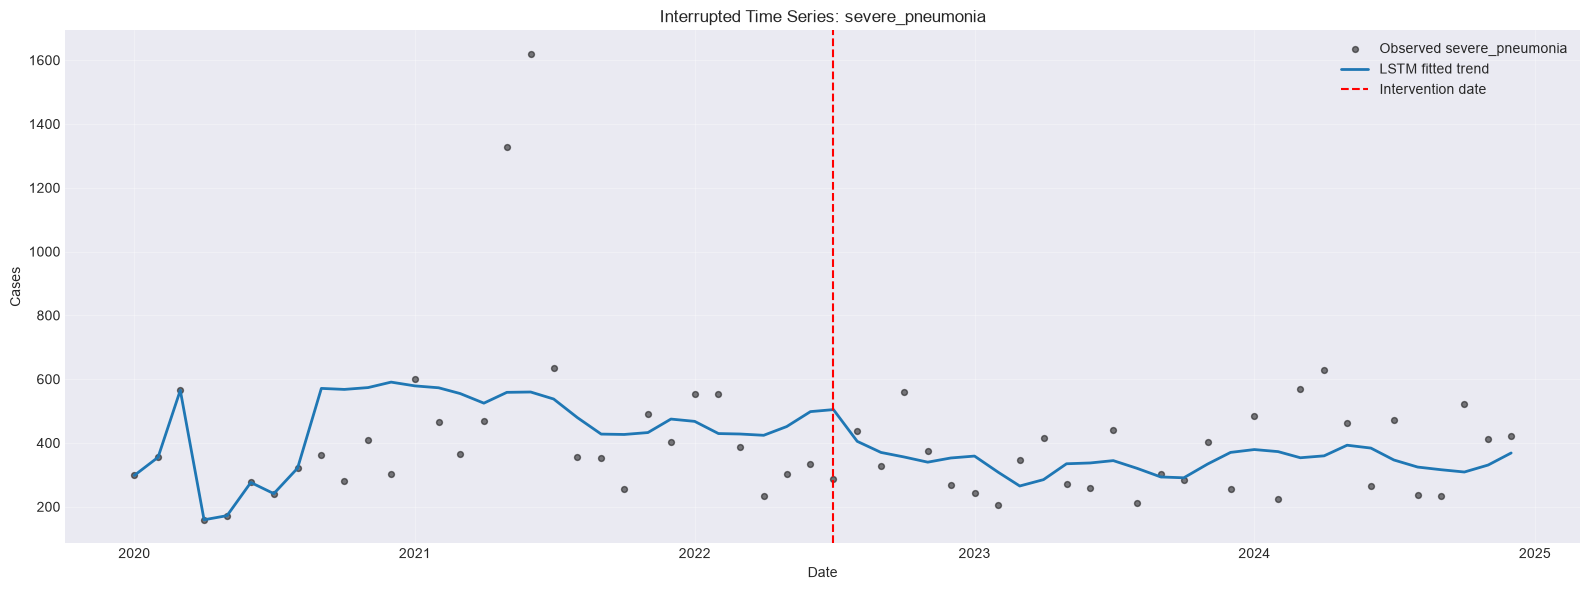

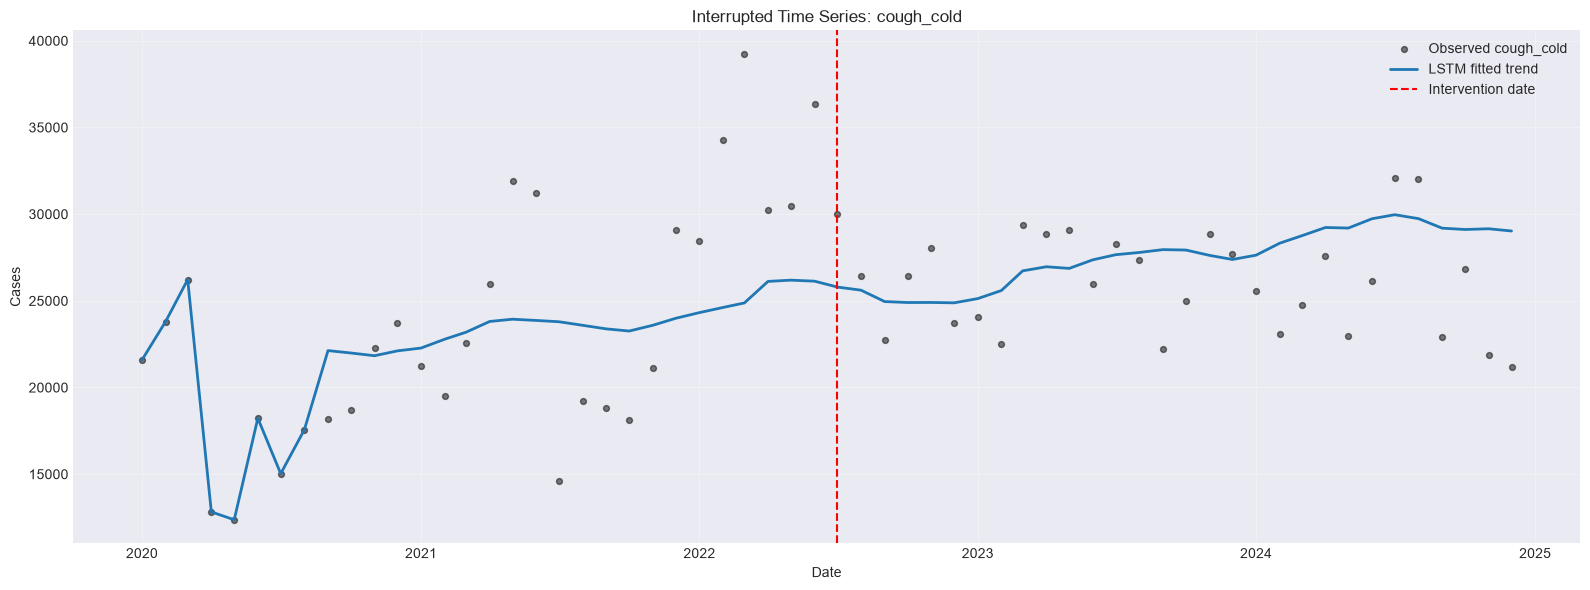

In [109]:
# Observed and LSTM-predicted trends for every disease
for disease in disease_cols:
    prediction_column = f'predicted_{disease}'
    if prediction_column not in data_itsa.columns:
        continue
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.scatter(data_itsa.index, data_itsa[disease], color='black', alpha=0.5, label=f'Observed {disease}', s=18)
    ax.plot(data_itsa.index, data_itsa[prediction_column], color='tab:blue', linewidth=2, label='LSTM fitted trend')
    ax.axvline(intervention_date, color='red', linestyle='--', label='Intervention date')
    ax.set(title=f'Interrupted Time Series: {disease}', xlabel='Date', ylabel='Cases'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


### 4.3 TensorFlow Forecast Preparation


In [110]:
data_project = processed_data.copy()
if 'date' in data_project.columns:
    data_project['ds'] = pd.to_datetime(data_project['date'], errors='coerce', dayfirst=True)
else:
    data_project['ds'] = pd.to_datetime(data_project['ds'], errors='coerce', dayfirst=True)

disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in data_project.columns]
data_project = data_project.sort_values('ds').reset_index(drop=True)

if 'county' not in data_project.columns:
    data_project['county'] = 'Kampala'
data_project['year_month'] = data_project['ds'].dt.to_period('M').astype(str)

if 'month' not in data_project.columns:
    data_project['month'] = data_project['ds'].dt.month
if 'week_of_year' not in data_project.columns:
    data_project['week_of_year'] = data_project['ds'].dt.isocalendar().week.astype(int)
if 'quarter' not in data_project.columns:
    data_project['quarter'] = data_project['ds'].dt.quarter
if 'day_of_year' not in data_project.columns:
    data_project['day_of_year'] = data_project['ds'].dt.dayofyear
if 'is_weekend' not in data_project.columns:
    data_project['is_weekend'] = data_project['ds'].dt.dayofweek.isin([5, 6]).astype(int)

if 'time' not in data_project.columns:
    data_project['time'] = np.arange(1, len(data_project) + 1)

if 'intervention' not in data_project.columns or 'time_since_intervention' not in data_project.columns:
    intervention_point = len(data_project) // 2
    intervention_date = data_project.loc[intervention_point, 'ds']
    data_project['intervention'] = (data_project['ds'] >= intervention_date).astype(int)
    data_project['time_since_intervention'] = np.where(
        data_project['intervention'] == 1,
        np.arange(len(data_project)) - intervention_point,
        0
    )
else:
    intervention_date = data_project.loc[data_project['intervention'].eq(1), 'ds'].min()

print(f"Using {len(disease_cols)} diseases for downstream TensorFlow modeling:")
print(disease_cols)
print(f"Intervention date reference: {pd.to_datetime(intervention_date).date()}")


Using 8 diseases for downstream TensorFlow modeling:
['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold']
Intervention date reference: 2022-07-01


### 4.4 TensorFlow Fusion Forecast Helpers


In [111]:
sequence_length = 8

base_sequence_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'avgtemp_sat', 'humidity_sat', 'temp_humidity_interaction',
    'windspeed_rolling_4', 'pm25_temp_ratio', 'pm25_humidity_ratio',
    'pm25_trailing_ma_7', 'pm25_trailing_ma_14',
    'pm25_trailing_ma_30', 'pm25_leading_ma_7',
    'pm25_leading_ma_14', 'pm25_leading_ma_30'
]
base_dense_candidates = [
    'time', 'intervention', 'time_since_intervention', 'month',
    'week_of_year', 'quarter', 'day_of_year', 'is_weekend',
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7',
    'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
    'pm25_leading_ma_7', 'pm25_leading_ma_14'
]

benchmark_feature_candidates = [
    'pm2_5', 'avgtemp', 'avghumidity', 'windspeed', 'precip',
    'precip_rolling_4', 'windspeed_rolling_4', 'pm25_temp_ratio',
    'pm25_humidity_ratio', 'pm25_trailing_ma_7',
    'pm25_trailing_ma_14', 'pm25_trailing_ma_30',
    'pm25_leading_ma_7', 'pm25_leading_ma_14'
]


def build_target_features(frame, disease):
    target_frame = frame.copy()
    lag_cols = []
    ma_cols = []
    for lag in [1, 2, 3, 4]:
        col = f'{disease}_lag_{lag}'
        target_frame[col] = target_frame[disease].shift(lag)
        lag_cols.append(col)
    for window in [4, 8]:
        trailing_col = f'{disease}_trailing_ma_{window}'
        target_frame[trailing_col] = target_frame[disease].rolling(window=window, min_periods=1).mean()
        ma_cols.append(trailing_col)
        leading_col = f'{disease}_leading_ma_{window}'
        target_frame[leading_col] = target_frame[disease].iloc[::-1].rolling(window=window, min_periods=1).mean().iloc[::-1]
        ma_cols.append(leading_col)
    diff_col = f'{disease}_diff_1'
    pct_col = f'{disease}_pct_change_1'
    target_frame[diff_col] = target_frame[disease].diff()
    target_frame[pct_col] = target_frame[disease].pct_change().replace([np.inf, -np.inf], np.nan)
    return target_frame, lag_cols, ma_cols, diff_col, pct_col


def create_fusion_arrays(frame, sequence_cols, dense_cols, target_col, seq_len):
    X_seq, X_dense, y, dates = [], [], [], []
    for idx in range(seq_len, len(frame)):
        X_seq.append(frame.loc[idx - seq_len:idx - 1, sequence_cols].to_numpy(dtype=float))
        X_dense.append(frame.loc[idx, dense_cols].to_numpy(dtype=float))
        y.append(float(frame.loc[idx, target_col]))
        dates.append(frame.loc[idx, 'ds'])
    return np.asarray(X_seq), np.asarray(X_dense), np.asarray(y), pd.to_datetime(dates)


def build_fusion_model(seq_shape, dense_dim):
    sequence_input = Input(shape=seq_shape, name='sequence_input')
    sequence_branch = LSTM(32, dropout=0.1, name='sequence_lstm')(sequence_input)
    sequence_branch = Dense(16, activation='relu', name='sequence_dense')(sequence_branch)

    dense_input = Input(shape=(dense_dim,), name='dense_input')
    dense_branch = Dense(16, activation='relu', name='dense_dense')(dense_input)
    dense_branch = Dropout(0.1, name='dense_dropout')(dense_branch)

    fused = Concatenate(name='fusion_concat')([sequence_branch, dense_branch])
    fused = Dense(16, activation='relu', name='fusion_dense')(fused)
    output = Dense(1, name='prediction')(fused)

    model = Model(inputs=[sequence_input, dense_input], outputs=output, name='fusion_lstm_regressor')
    model.compile(optimizer='adam', loss='mse')
    return model


def train_disease_fusion_model(frame, disease, seq_len=8, test_fraction=0.2):
    target_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)

    sequence_cols = [col for col in base_sequence_candidates if col in target_frame.columns]
    sequence_cols += [col for col in lag_cols + ma_cols if col in target_frame.columns]

    dense_cols = [col for col in base_dense_candidates if col in target_frame.columns]
    dense_cols += [col for col in [diff_col, pct_col] if col in target_frame.columns]

    needed_cols = ['ds', disease] + sequence_cols + dense_cols
    model_frame = target_frame[needed_cols].copy().replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if len(model_frame) <= seq_len + 10:
        raise ValueError(f'Not enough usable rows for {disease} after feature engineering.')

    X_seq_raw, X_dense_raw, y_raw, dates = create_fusion_arrays(
        model_frame,
        sequence_cols=sequence_cols,
        dense_cols=dense_cols,
        target_col=disease,
        seq_len=seq_len
    )

    total_samples = len(y_raw)
    split_idx = max(8, int(total_samples * (1 - test_fraction)))
    split_idx = min(split_idx, total_samples - 2)
    if split_idx <= 1:
        raise ValueError(f'Not enough train/test samples for {disease}.')

    X_seq_train_raw = X_seq_raw[:split_idx]
    X_seq_test_raw = X_seq_raw[split_idx:]
    X_dense_train_raw = X_dense_raw[:split_idx]
    X_dense_test_raw = X_dense_raw[split_idx:]
    y_train_raw = y_raw[:split_idx]
    y_test_raw = y_raw[split_idx:]

    sequence_scaler = MinMaxScaler()
    dense_scaler = StandardScaler()
    target_scaler = MinMaxScaler()

    sequence_scaler.fit(X_seq_train_raw.reshape(-1, X_seq_train_raw.shape[-1]))
    dense_scaler.fit(X_dense_train_raw)
    target_scaler.fit(y_train_raw.reshape(-1, 1))

    def scale_sequence(values):
        scaled = sequence_scaler.transform(values.reshape(-1, values.shape[-1]))
        return scaled.reshape(values.shape)

    X_seq_train = scale_sequence(X_seq_train_raw)
    X_seq_test = scale_sequence(X_seq_test_raw)
    X_dense_train = dense_scaler.transform(X_dense_train_raw)
    X_dense_test = dense_scaler.transform(X_dense_test_raw)
    y_train = target_scaler.transform(y_train_raw.reshape(-1, 1))

    model = build_fusion_model((seq_len, X_seq_train.shape[-1]), X_dense_train.shape[-1])
    callbacks = [EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)]
    history = model.fit(
        [X_seq_train, X_dense_train],
        y_train,
        epochs=40,
        batch_size=min(16, max(4, len(X_seq_train))),
        validation_split=0.2 if len(X_seq_train) >= 12 else 0.0,
        verbose=0,
        callbacks=callbacks if len(X_seq_train) >= 12 else []
    )

    y_train_pred = target_scaler.inverse_transform(
        model.predict([X_seq_train, X_dense_train], verbose=0)
    ).flatten()
    y_test_pred = target_scaler.inverse_transform(
        model.predict([X_seq_test, X_dense_test], verbose=0)
    ).flatten()

    train_residual_std = float(np.std(y_train_raw - y_train_pred)) if len(y_train_raw) > 1 else 0.0
    all_predictions = np.concatenate([y_train_pred, y_test_pred])

    metrics = {
        'Disease': disease,
        'Model': 'TensorFlow Fusion LSTM + Dense',
        'MAE': mean_absolute_error(y_test_raw, y_test_pred),
        'RMSE': mean_squared_error(y_test_raw, y_test_pred) ** 0.5,
        'R²': r2_score(y_test_raw, y_test_pred) if len(y_test_raw) > 1 else np.nan,
        'Train Samples': int(len(y_train_raw)),
        'Test Samples': int(len(y_test_raw))
    }

    prediction_frame = pd.DataFrame({
        'ds': dates,
        'actual': y_raw,
        'predicted': all_predictions,
        'lower': all_predictions - 1.96 * train_residual_std,
        'upper': all_predictions + 1.96 * train_residual_std,
        'dataset_split': ['Train' if idx < split_idx else 'Test' for idx in range(total_samples)]
    })

    return {
        'metrics': metrics,
        'history': history.history,
        'prediction_frame': prediction_frame,
        'sequence_cols': sequence_cols,
        'dense_cols': dense_cols
    }


def run_benchmark_models(frame, disease):
    benchmark_frame, lag_cols, ma_cols, diff_col, pct_col = build_target_features(frame, disease)
    benchmark_features = [col for col in benchmark_feature_candidates if col in benchmark_frame.columns]
    benchmark_features += [col for col in lag_cols + ma_cols + [diff_col, pct_col] if col in benchmark_frame.columns]

    benchmark_frame = benchmark_frame.copy().replace([np.inf, -np.inf], np.nan)
    benchmark_frame['county'] = benchmark_frame.get('county', 'Kampala')
    benchmark_frame['year_month'] = benchmark_frame['ds'].dt.to_period('M').astype(str)

    ts_modeler = TimeSeriesModeler(benchmark_frame, target_column=disease)
    X_ts, y_ts = ts_modeler.prepare_time_series_data(
        window_size=sequence_length,
        features=benchmark_features,
        target_type='binary'
    )

    if len(X_ts) == 0 or len(y_ts) == 0:
        raise ValueError(f'No usable benchmark windows for {disease}.')

    benchmark_results = ts_modeler.train_models(
        X_ts,
        y_ts,
        models_to_train=['random_forest', 'gradient_boosting', 'svm'],
        cv_splits=3
    )

    if not benchmark_results:
        raise ValueError(f'No benchmark models trained for {disease}.')

    best_model_name = max(benchmark_results, key=lambda name: benchmark_results[name]['avg_f1'])
    best_metrics = benchmark_results[best_model_name]
    return {
        'Disease': disease,
        'Best Benchmark Model': best_model_name,
        'Benchmark Accuracy': best_metrics.get('avg_accuracy', np.nan),
        'Benchmark F1': best_metrics.get('avg_f1', np.nan),
        'Benchmark Precision': best_metrics.get('avg_precision', np.nan),
        'Benchmark Recall': best_metrics.get('avg_recall', np.nan)
    }


### 4.5 TensorFlow Disease Forecasts



=== Training TensorFlow fusion model for TB ===
Train samples: 38, Test samples: 10, MAE: 1697.438, RMSE: 2041.948, R²: -5.324


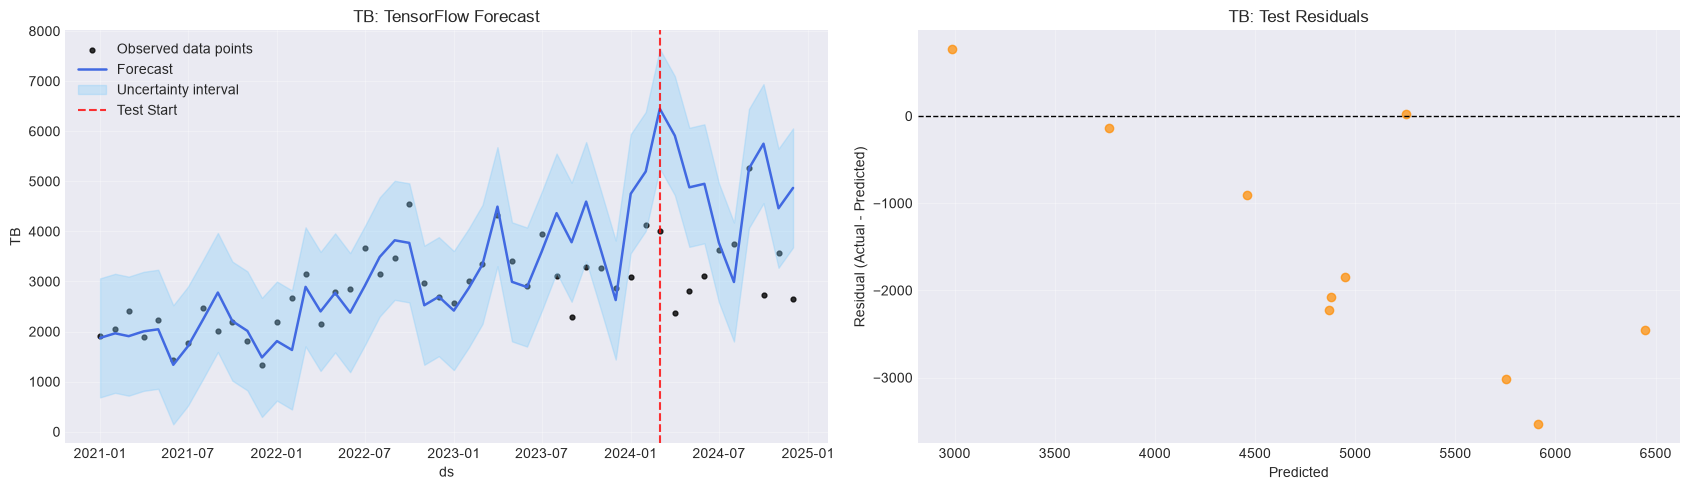

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: TB
INFO:time_series_modeler:Prepared 52 samples with 192 features


=== Benchmarking classical time-series models for TB ===


INFO:time_series_modeler:Training random_forest...


Skipping benchmark models for TB: index 1 is out of bounds for axis 1 with size 1

=== Training TensorFlow fusion model for ILI ===
Train samples: 38, Test samples: 10, MAE: 4725.513, RMSE: 5459.972, R²: -1.750


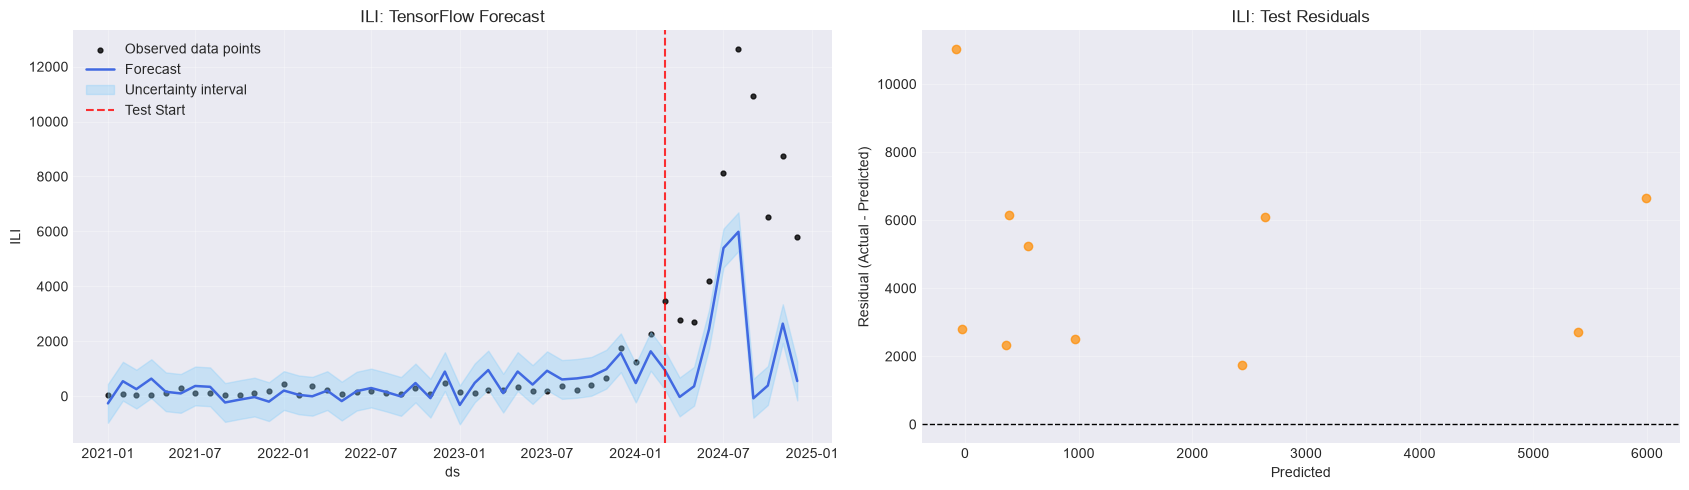

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: ILI
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for ILI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.567)



=== Training TensorFlow fusion model for ILD_deaths ===
Train samples: 20, Test samples: 5, MAE: 42.091, RMSE: 47.790, R²: -1.148


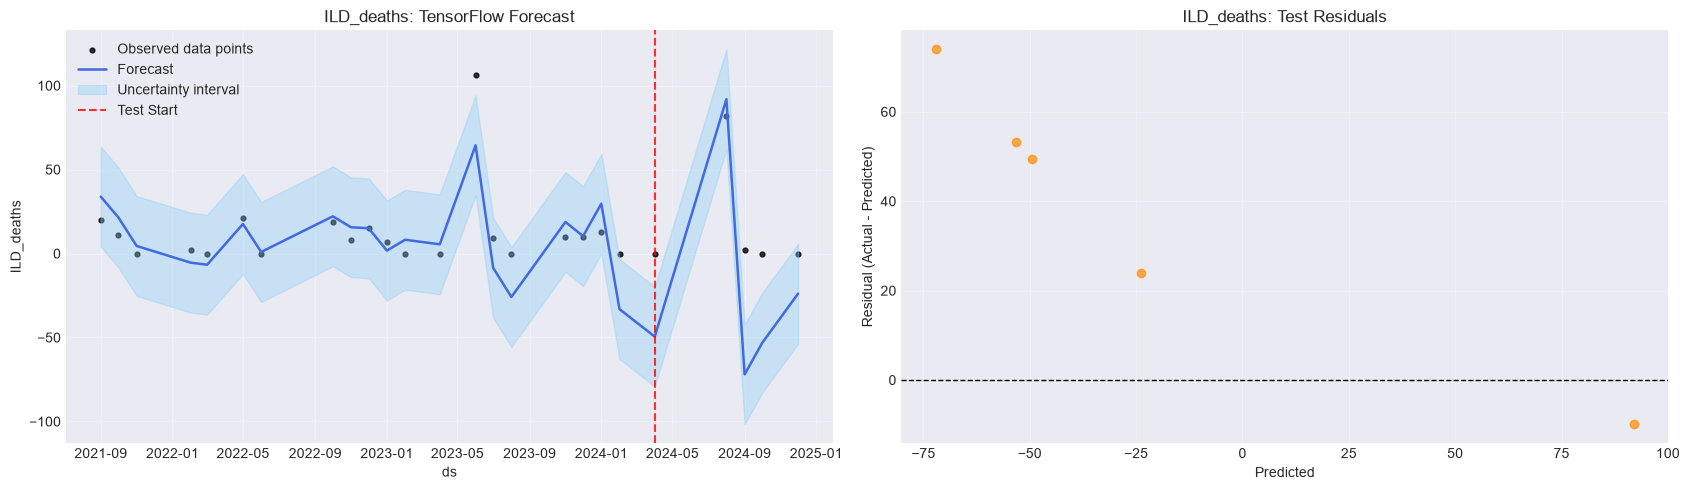

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: ILD_deaths
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for ILD_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.531)



=== Training TensorFlow fusion model for SARI ===
Train samples: 38, Test samples: 10, MAE: 595.578, RMSE: 738.064, R²: -0.518


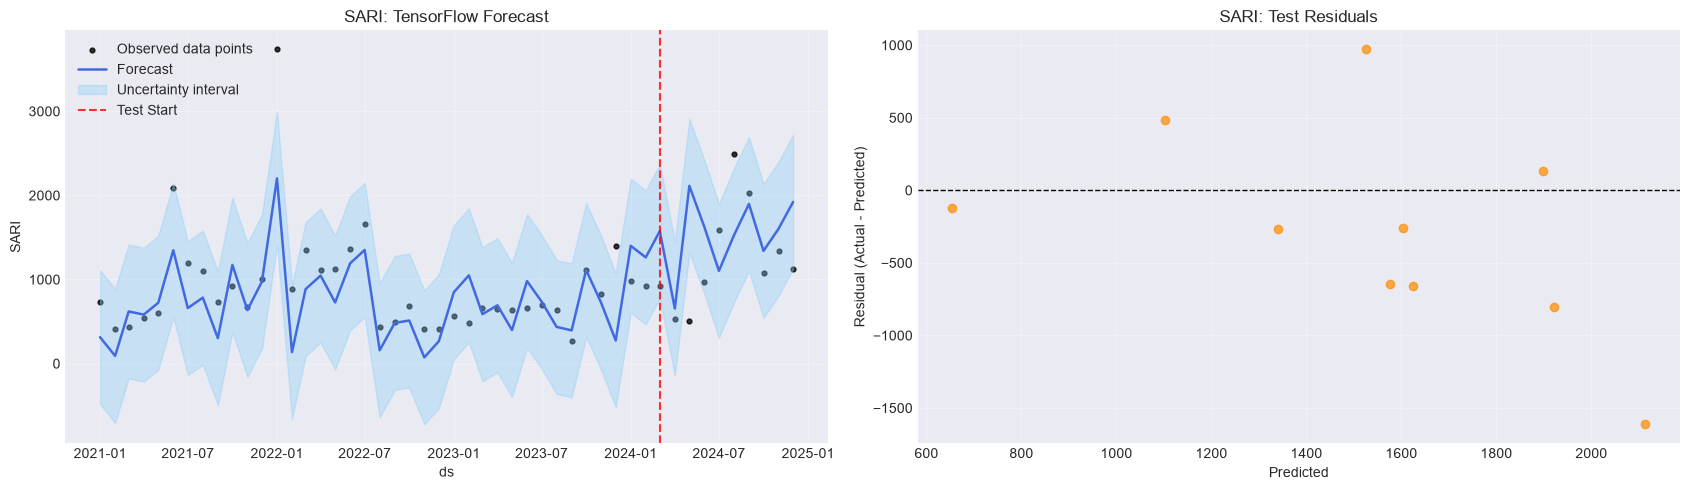

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: SARI
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.678)



=== Training TensorFlow fusion model for SARI_deaths ===
Train samples: 32, Test samples: 9, MAE: 38.898, RMSE: 41.084, R²: -30.286


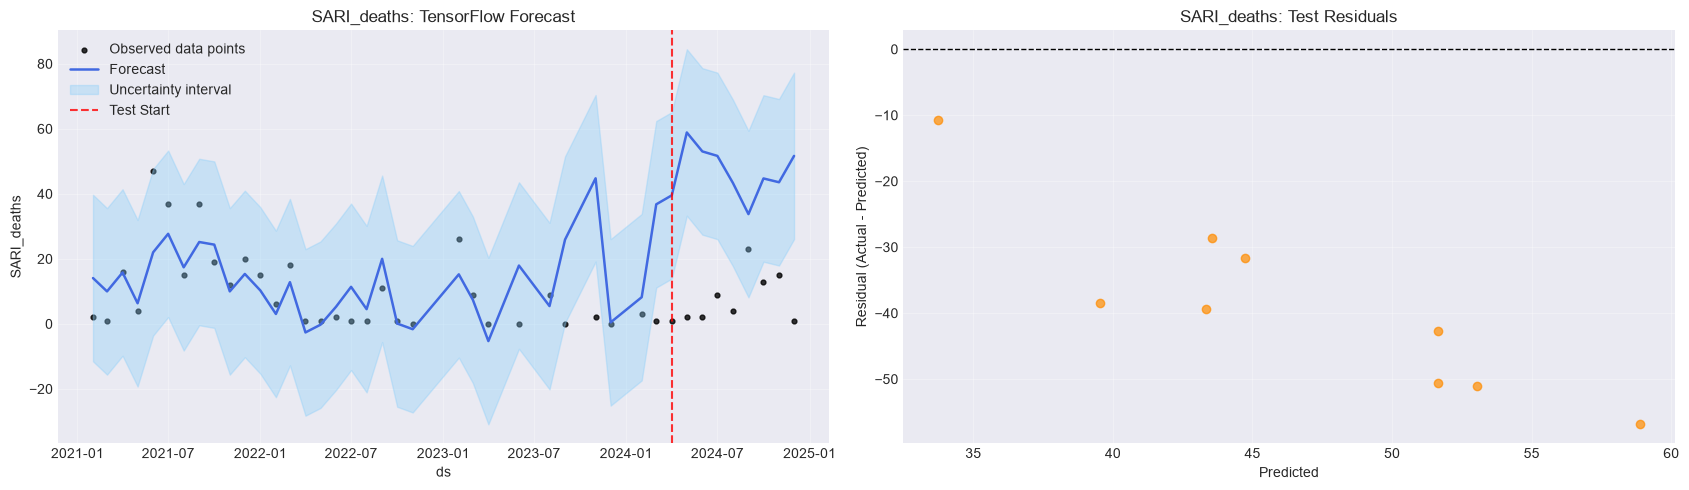

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: SARI_deaths
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for SARI_deaths ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.613)



=== Training TensorFlow fusion model for pneumonia ===
Train samples: 38, Test samples: 10, MAE: 480.778, RMSE: 707.714, R²: -2.936


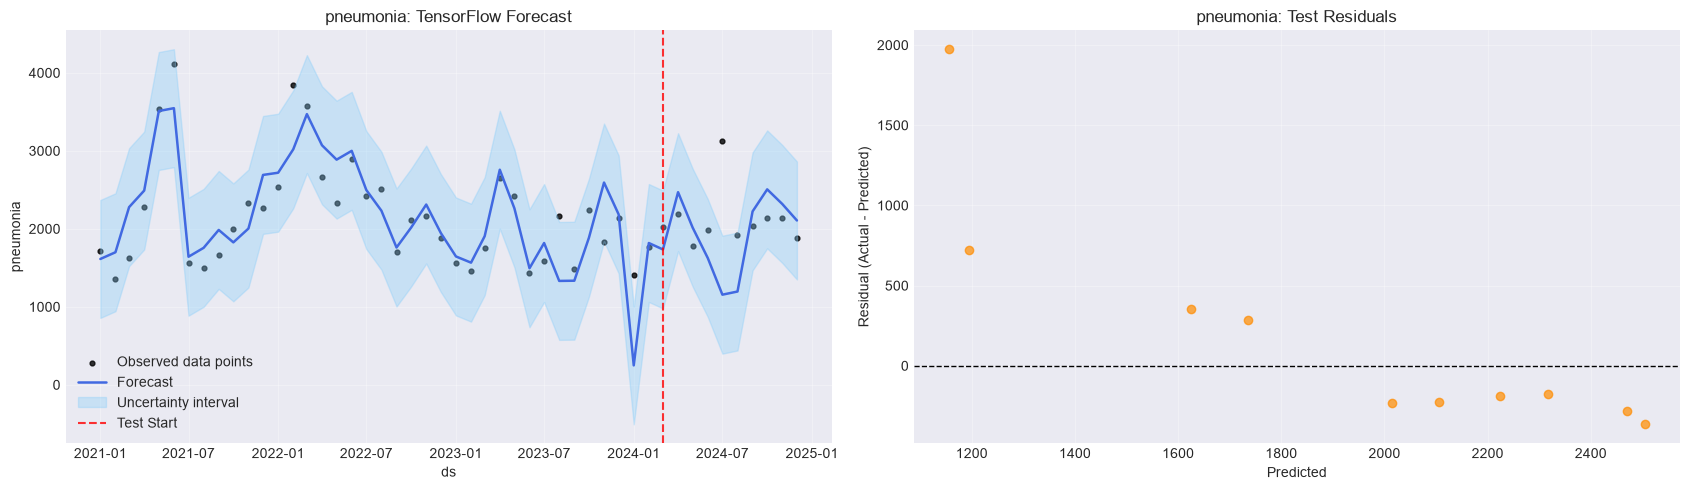

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: pneumonia
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for pneumonia ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.391)



=== Training TensorFlow fusion model for severe_pneumonia ===
Train samples: 38, Test samples: 10, MAE: 429.979, RMSE: 590.615, R²: -19.200


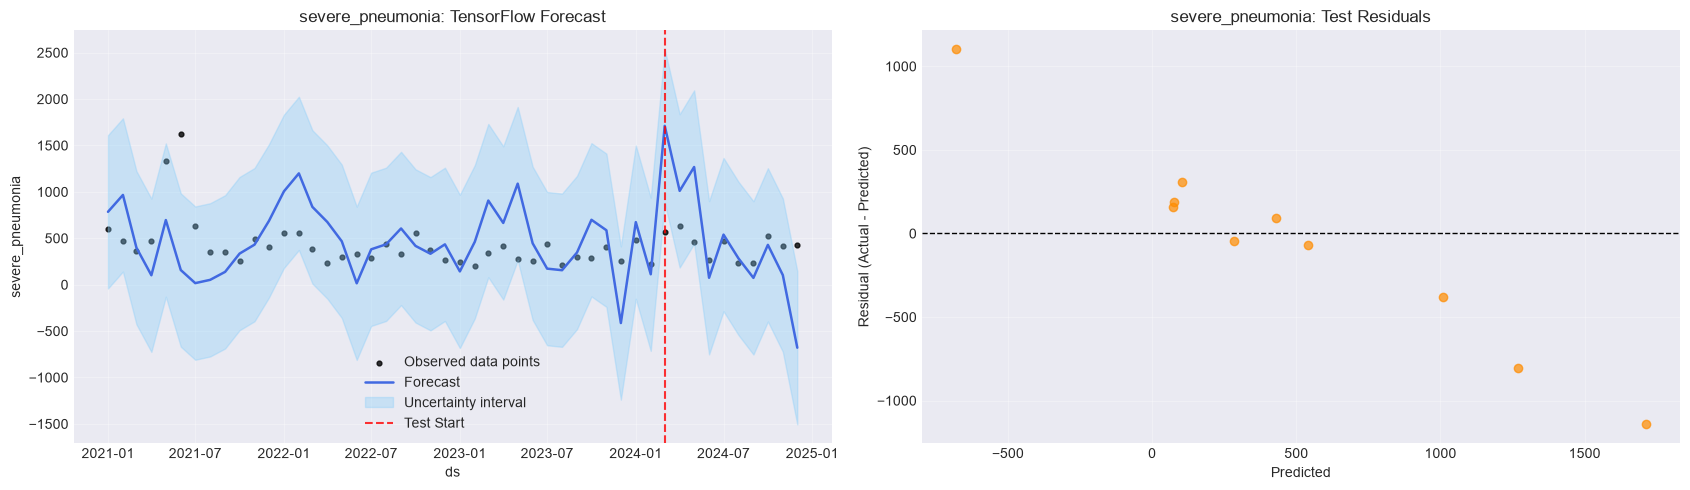

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: severe_pneumonia
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for severe_pneumonia ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: random_forest (F1: 0.570)



=== Training TensorFlow fusion model for cough_cold ===
Train samples: 38, Test samples: 10, MAE: 10635.191, RMSE: 13097.570, R²: -11.562


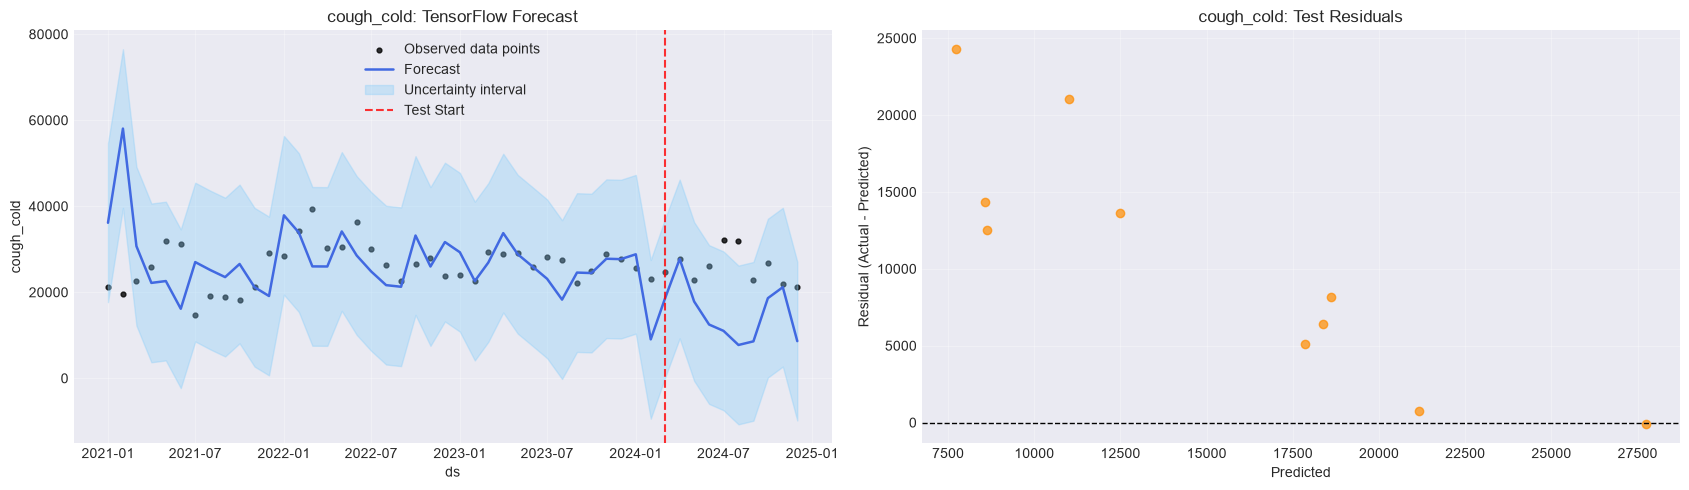

INFO:time_series_modeler:TimeSeriesModeler initialized with 60 records, target: cough_cold
INFO:time_series_modeler:Prepared 52 samples with 192 features
INFO:time_series_modeler:Training random_forest...


=== Benchmarking classical time-series models for cough_cold ===


INFO:time_series_modeler:Training gradient_boosting...
INFO:time_series_modeler:Training svm...
INFO:time_series_modeler:Best model: gradient_boosting (F1: 0.659)


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,38.898087,41.084032,-30.285975,32,9
1,ILD_deaths,TensorFlow Fusion LSTM + Dense,42.091430,47.789954,-1.147795,20,5
2,severe_pneumonia,TensorFlow Fusion LSTM + Dense,429.978575,590.614642,-19.200277,38,10
3,pneumonia,TensorFlow Fusion LSTM + Dense,480.777881,707.713635,-2.936151,38,10
4,SARI,TensorFlow Fusion LSTM + Dense,595.577625,738.063588,-0.517687,38,10
5,TB,TensorFlow Fusion LSTM + Dense,1697.438452,2041.948447,-5.324402,38,10
6,ILI,TensorFlow Fusion LSTM + Dense,4725.513274,5459.971818,-1.749760,38,10
7,cough_cold,TensorFlow Fusion LSTM + Dense,10635.191211,13097.570075,-11.561605,38,10


In [112]:
models_performance_records = []
benchmark_records = []
disease_forecasts = {}

for disease in disease_cols:
    print(f"\n=== Training TensorFlow fusion model for {disease} ===")
    try:
        result = train_disease_fusion_model(data_project, disease, seq_len=sequence_length)
        disease_forecasts[disease] = result['prediction_frame']
        models_performance_records.append(result['metrics'])

        plot_df = result['prediction_frame']
        print(
            f"Train samples: {result['metrics']['Train Samples']}, "
            f"Test samples: {result['metrics']['Test Samples']}, "
            f"MAE: {result['metrics']['MAE']:.3f}, "
            f"RMSE: {result['metrics']['RMSE']:.3f}, "
            f"R²: {result['metrics']['R²']:.3f}"
        )

        fig, axes = plt.subplots(1, 2, figsize=(17, 5))
        axes[0].scatter(plot_df['ds'], plot_df['actual'], color='black', s=12, alpha=0.8, label='Observed data points')
        axes[0].plot(plot_df['ds'], plot_df['predicted'], color='royalblue', linewidth=1.8, label='Forecast')
        axes[0].fill_between(
            plot_df['ds'],
            plot_df['lower'],
            plot_df['upper'],
            color='lightskyblue',
            alpha=0.35,
            label='Uncertainty interval'
        )
        test_dates = plot_df.loc[plot_df['dataset_split'] == 'Test', 'ds']
        if not test_dates.empty:
            axes[0].axvline(test_dates.iloc[0], color='red', linestyle='--', alpha=0.8, label='Test Start')
        axes[0].set_title(f'{disease}: TensorFlow Forecast')
        axes[0].set_xlabel('ds')
        axes[0].set_ylabel(disease)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        test_df = plot_df[plot_df['dataset_split'] == 'Test'].copy()
        if len(test_df) >= 2:
            residuals = test_df['actual'] - test_df['predicted']
            axes[1].scatter(test_df['predicted'], residuals, alpha=0.7, color='darkorange')
            axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
            axes[1].set_title(f'{disease}: Test Residuals')
            axes[1].set_xlabel('Predicted')
            axes[1].set_ylabel('Residual (Actual - Predicted)')
            axes[1].grid(True, alpha=0.3)
        else:
            axes[1].axis('off')
            axes[1].text(0.5, 0.5, 'Not enough test points for residual plot', ha='center', va='center')

        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Skipping TensorFlow model for {disease}: {exc}")

    print(f"=== Benchmarking classical time-series models for {disease} ===")
    try:
        benchmark_records.append(run_benchmark_models(data_project, disease))
    except Exception as exc:
        print(f"Skipping benchmark models for {disease}: {exc}")

models_performance = pd.DataFrame(models_performance_records)
if not models_performance.empty:
    models_performance = models_performance.sort_values('RMSE').reset_index(drop=True)

benchmark_performance = pd.DataFrame(benchmark_records)
if not benchmark_performance.empty:
    benchmark_performance = benchmark_performance.sort_values('Benchmark F1', ascending=False).reset_index(drop=True)

models_performance


### 4.6 Model Comparison


In [113]:
print('--- TensorFlow Fusion Model Summary ---')
if not models_performance.empty:
    print(models_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    best_disease_row = models_performance.loc[models_performance['RMSE'].idxmin()]
    print(
        f"\nBest-performing disease by RMSE: {best_disease_row['Disease']} "
        f"(RMSE={best_disease_row['RMSE']:.3f}, MAE={best_disease_row['MAE']:.3f}, R²={best_disease_row['R²']:.3f})"
    )
else:
    print('No TensorFlow disease models completed successfully.')

print('\n--- Classical Time-Series Benchmark Summary ---')
if not benchmark_performance.empty:
    print(benchmark_performance.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
else:
    print('No benchmark models completed successfully.')

if not models_performance.empty and not benchmark_performance.empty:
    model_comparison = models_performance.merge(benchmark_performance, on='Disease', how='left')
    print('\n--- Per-Disease Model Comparison ---')
    print(
        model_comparison[
            [
                'Disease', 'Model', 'MAE', 'RMSE', 'R²',
                'Best Benchmark Model', 'Benchmark Accuracy', 'Benchmark F1'
            ]
        ].to_string(index=False, float_format=lambda x: f'{x:.3f}')
    )
else:
    model_comparison = pd.DataFrame()

model_comparison


--- TensorFlow Fusion Model Summary ---
         Disease                          Model       MAE      RMSE      R²  Train Samples  Test Samples
     SARI_deaths TensorFlow Fusion LSTM + Dense    38.898    41.084 -30.286             32             9
      ILD_deaths TensorFlow Fusion LSTM + Dense    42.091    47.790  -1.148             20             5
severe_pneumonia TensorFlow Fusion LSTM + Dense   429.979   590.615 -19.200             38            10
       pneumonia TensorFlow Fusion LSTM + Dense   480.778   707.714  -2.936             38            10
            SARI TensorFlow Fusion LSTM + Dense   595.578   738.064  -0.518             38            10
              TB TensorFlow Fusion LSTM + Dense  1697.438  2041.948  -5.324             38            10
             ILI TensorFlow Fusion LSTM + Dense  4725.513  5459.972  -1.750             38            10
      cough_cold TensorFlow Fusion LSTM + Dense 10635.191 13097.570 -11.562             38            10

Best-performin

,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples,Best Benchmark Model,Benchmark Accuracy,Benchmark F1,Benchmark Precision,Benchmark Recall
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,38.898087,41.084032,-30.285975,32,9,random_forest,0.641026,0.612536,0.594406,0.641026
1,ILD_deaths,TensorFlow Fusion LSTM + Dense,42.091430,47.789954,-1.147795,20,5,gradient_boosting,0.538462,0.530936,0.601282,0.538462
2,severe_pneumonia,TensorFlow Fusion LSTM + Dense,429.978575,590.614642,-19.200277,38,10,random_forest,0.589744,0.569699,0.631235,0.589744
3,pneumonia,TensorFlow Fusion LSTM + Dense,480.777881,707.713635,-2.936151,38,10,gradient_boosting,0.410256,0.390572,0.543001,0.410256
4,SARI,TensorFlow Fusion LSTM + Dense,595.577625,738.063588,-0.517687,38,10,gradient_boosting,0.743590,0.678127,0.629191,0.743590
5,TB,TensorFlow Fusion LSTM + Dense,1697.438452,2041.948447,-5.324402,38,10,NaN,NaN,NaN,NaN,NaN
6,ILI,TensorFlow Fusion LSTM + Dense,4725.513274,5459.971818,-1.749760,38,10,random_forest,0.615385,0.566972,0.608750,0.615385
7,cough_cold,TensorFlow Fusion LSTM + Dense,10635.191211,13097.570075,-11.561605,38,10,gradient_boosting,0.666667,0.659263,0.758858,0.666667


## Step 5: Intervention Simulation


In [114]:
# Baseline PM2.5 and disease burden for every outcome
disease_cols = [col for col in ['TB', 'ILI', 'ILD_deaths', 'SARI', 'SARI_deaths', 'pneumonia', 'severe_pneumonia', 'cough_cold'] if col in processed_data.columns]
baseline = {'baseline_pm25': processed_data['pm2_5'].dropna().mean()}
baseline_by_disease = processed_data[disease_cols].sum(min_count=1).rename_axis('Disease').reset_index(name='Baseline cases')
print(f"Average PM2.5: {baseline['baseline_pm25']:.2f} μg/m³")
baseline_by_disease


Average PM2.5: 39.36 μg/m³


,Disease,Baseline cases
0,TB,156373.0
1,ILI,82948.0
2,ILD_deaths,7399.0
3,SARI,54591.0
4,SARI_deaths,451.0
5,pneumonia,120571.0
6,severe_pneumonia,24276.0
7,cough_cold,1486481.0


In [115]:
# Simulate intervention scenarios for every disease outcome
scenarios = {'Traffic Control': {'reduction': 0.25, 'cost_factor': 2.5}, 'Green Spaces': {'reduction': 0.15, 'cost_factor': 3.0}, 'Dust Control': {'reduction': 0.20, 'cost_factor': 4.0}, 'Combined': {'reduction': 0.35, 'cost_factor': 5.0}}
results = []
for disease in disease_cols:
    disease_total = processed_data[disease].dropna().sum()
    for scenario_name, params in scenarios.items():
        reduced_pm25 = baseline['baseline_pm25'] * (1 - params['reduction'])
        relative_risk = 1.08 ** ((reduced_pm25 - baseline['baseline_pm25']) / 10)
        cases_prevented = disease_total * (1 - relative_risk)
        cost = params['cost_factor'] * 1_000_000
        results.append({'Disease': disease, 'Scenario': scenario_name, 'PM2.5 Reduction (%)': params['reduction'] * 100, 'Final PM2.5 (μg/m³)': reduced_pm25, 'Cases Prevented': cases_prevented, 'Cost Factor': params['cost_factor'], 'Cost per Case Prevented ($)': cost / cases_prevented if cases_prevented > 0 else float('inf')})
results_df = pd.DataFrame(results)
results_df


,Disease,Scenario,PM2.5 Reduction (%),Final PM2.5 (μg/m³),Cases Prevented,Cost Factor,Cost per Case Prevented ($)
0,TB,Traffic Control,25.0,29.520598,11405.006933,2.5,219.201971
1,TB,Green Spaces,15.0,33.456678,6946.376457,3.0,431.879847
2,TB,Dust Control,20.0,31.488638,9192.574244,4.0,435.133826
3,TB,Combined,35.0,25.584518,15730.599634,5.0,317.851838
4,ILI,Traffic Control,25.0,29.520598,6049.781709,2.5,413.238051
5,ILI,Green Spaces,15.0,33.456678,3684.702822,3.0,814.176922
6,ILI,Dust Control,20.0,31.488638,4876.197607,4.0,820.311300
7,ILI,Combined,35.0,25.584518,8344.290756,5.0,599.212102
8,ILD_deaths,Traffic Control,25.0,29.520598,539.643329,2.5,4632.689529
9,ILD_deaths,Green Spaces,15.0,33.456678,328.677197,3.0,9127.496592


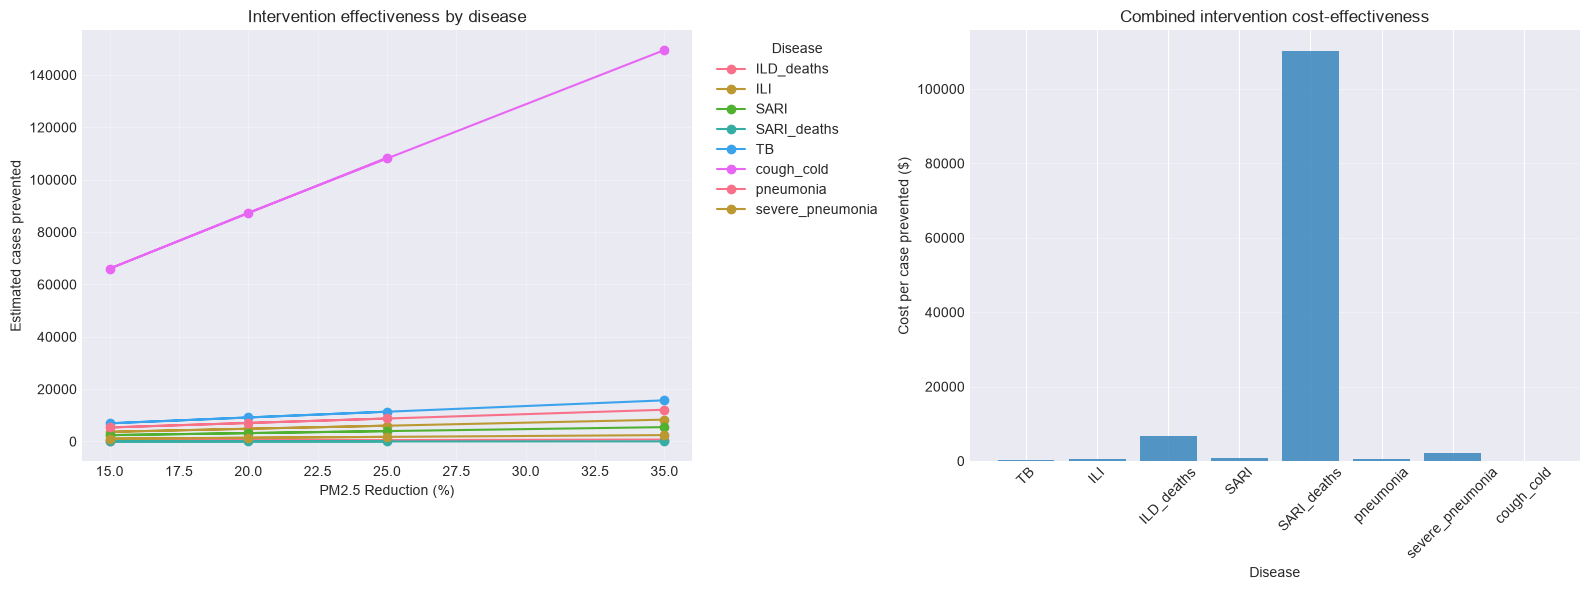

In [116]:
# Compare intervention effects across all diseases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for disease, subset in results_df.groupby('Disease'):
    axes[0].plot(subset['PM2.5 Reduction (%)'], subset['Cases Prevented'], marker='o', label=disease)
axes[0].set(xlabel='PM2.5 Reduction (%)', ylabel='Estimated cases prevented', title='Intervention effectiveness by disease')
axes[0].legend(title='Disease', bbox_to_anchor=(1.02, 1), loc='upper left'); axes[0].grid(True, alpha=0.3)
combined = results_df[results_df['Scenario'].eq('Combined')]
axes[1].bar(combined['Disease'], combined['Cost per Case Prevented ($)'], color='tab:blue', alpha=0.75)
axes[1].set(xlabel='Disease', ylabel='Cost per case prevented ($)', title='Combined intervention cost-effectiveness')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Overall epidemiological interpretation and implications

Interpret the descriptive, regression, exposure–response, lag, climate, spatial/facility, and sensitivity outputs together. The results quantify patterns in routine surveillance data; they cannot by themselves establish that PM₂.₅ caused changes in disease notifications. Discuss effect sizes, uncertainty, data completeness, exposure measurement, reporting practices, residual confounding, and the consistency of findings across analyses before considering pollution-control or health-service implications.


### Reader-ready results summary

The following plain-language statements are templates filled with the estimates produced above. They are designed for quick reading and should be updated automatically whenever the notebook is re-run from top to bottom.


In [117]:
# Plain-language, automatically populated results statements for all diseases
print('READER-READY EPIDEMIOLOGICAL RESULTS SUMMARY'); print('=' * 72)
print(f"Observations: {len(processed_data):,}; period: {processed_data['date'].min():%d %b %Y} to {processed_data['date'].max():%d %b %Y}.")
print(f"Diseases analysed: {', '.join(disease_cols)}")
for title, table in [('Main regression estimates', regression_results), ('Exposure-response estimates', exposure_response_results), ('Distributed-lag cumulative estimates', dlnm_cumulative), ('Sensitivity estimates', sensitivity_results)]:
    print(f'\n{title}:'); display(table.round(3))
print('\nSpatial maps and tables report every diagnosis by Kampala division.')


READER-READY EPIDEMIOLOGICAL RESULTS SUMMARY
Observations: 60; period: 01 Jan 2020 to 01 Dec 2024.
Diseases analysed: TB, ILI, ILD_deaths, SARI, SARI_deaths, pneumonia, severe_pneumonia, cough_cold

Main regression estimates:


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC
0,TB,60,0.928,0.860,1.000,0.051,8859.056
1,ILI,60,1.120,0.843,1.489,0.435,56181.344
2,ILD_deaths,60,3.314,0.548,20.041,0.192,5466.594
3,SARI,60,1.033,0.865,1.233,0.723,15545.376
4,SARI_deaths,60,0.752,0.504,1.124,0.165,708.209
5,pneumonia,60,0.895,0.807,0.992,0.034,11812.221
6,severe_pneumonia,60,0.862,0.701,1.061,0.162,5841.032
7,cough_cold,60,0.969,0.919,1.022,0.253,57365.029



Exposure-response estimates:


,Disease,Reference PM2.5,IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,39.457,0.928,0.860,1.000
1,ILI,39.457,1.120,0.843,1.489
2,ILD_deaths,39.457,3.314,0.548,20.041
3,SARI,39.457,1.033,0.865,1.233
4,SARI_deaths,39.457,0.752,0.504,1.124
5,pneumonia,39.457,0.895,0.807,0.992
6,severe_pneumonia,39.457,0.862,0.701,1.061
7,cough_cold,39.457,0.969,0.919,1.022



Distributed-lag cumulative estimates:


,Disease,Lag window,Cumulative IRR per 10 µg/m³,95% CI lower,95% CI upper
0,TB,0–4,0.830,0.702,0.982
1,ILI,0–4,2.611,0.475,14.354
2,ILD_deaths,0–4,39.936,6.475,246.311
3,SARI,0–4,1.379,0.946,2.011
4,SARI_deaths,0–4,0.851,0.296,2.451
5,pneumonia,0–4,0.867,0.669,1.124
6,severe_pneumonia,0–4,0.903,0.661,1.234
7,cough_cold,0–4,0.864,0.741,1.006



Sensitivity estimates:


,Outcome,N,IRR per 10 µg/m³,95% CI lower,95% CI upper,p-value,AIC,Disease,Specification
0,TB,60,0.928,0.860,1.000,0.051,8859.056,TB,Primary adjusted model
1,TB,57,0.966,0.895,1.042,0.370,6989.069,TB,Exclude highest 5% PM2.5
2,TB,59,1.009,0.952,1.069,0.771,7322.968,TB,One-period lagged PM2.5
3,ILI,60,1.120,0.843,1.489,0.435,56181.344,ILI,Primary adjusted model
4,ILI,57,1.440,1.039,1.995,0.028,56734.666,ILI,Exclude highest 5% PM2.5
5,ILI,59,1.284,1.054,1.564,0.013,52604.980,ILI,One-period lagged PM2.5
6,ILD_deaths,60,3.314,0.548,20.041,0.192,5466.594,ILD_deaths,Primary adjusted model
7,ILD_deaths,57,2.610,0.387,17.619,0.325,5324.143,ILD_deaths,Exclude highest 5% PM2.5
8,ILD_deaths,59,0.572,0.170,1.928,0.367,5653.116,ILD_deaths,One-period lagged PM2.5
9,SARI,60,1.033,0.865,1.233,0.723,15545.376,SARI,Primary adjusted model



Spatial maps and tables report every diagnosis by Kampala division.


In [118]:
# Summary Report
print('=' * 72)
print('KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT')
print('=' * 72)
print(f"Analysis period: {summary['date_range']} | Records: {summary['total_records']}")
print(f"Average PM2.5: {summary['pm25_statistics']['mean']:.2f} μg/m³")
print(f"Diseases analysed: {', '.join(disease_cols)}")
print('\nDisease-model results:')
display(models_performance if 'models_performance' in globals() else lstm_performance)
print('\nIntervention results are reported for every disease and scenario:')
display(results_df.sort_values(['Disease', 'Cases Prevented'], ascending=[True, False]))
print('\nSpatial maps and tables report every recorded diagnosis by Kampala division.')


KAMPALA AIR QUALITY AND RESPIRATORY HEALTH ANALYSIS - SUMMARY REPORT
Analysis period: 2020-01-01 00:00:00 to 2024-12-01 00:00:00 | Records: 60
Average PM2.5: 39.36 μg/m³
Diseases analysed: TB, ILI, ILD_deaths, SARI, SARI_deaths, pneumonia, severe_pneumonia, cough_cold

Disease-model results:


,Disease,Model,MAE,RMSE,R²,Train Samples,Test Samples
0,SARI_deaths,TensorFlow Fusion LSTM + Dense,38.898087,41.084032,-30.285975,32,9
1,ILD_deaths,TensorFlow Fusion LSTM + Dense,42.091430,47.789954,-1.147795,20,5
2,severe_pneumonia,TensorFlow Fusion LSTM + Dense,429.978575,590.614642,-19.200277,38,10
3,pneumonia,TensorFlow Fusion LSTM + Dense,480.777881,707.713635,-2.936151,38,10
4,SARI,TensorFlow Fusion LSTM + Dense,595.577625,738.063588,-0.517687,38,10
5,TB,TensorFlow Fusion LSTM + Dense,1697.438452,2041.948447,-5.324402,38,10
6,ILI,TensorFlow Fusion LSTM + Dense,4725.513274,5459.971818,-1.749760,38,10
7,cough_cold,TensorFlow Fusion LSTM + Dense,10635.191211,13097.570075,-11.561605,38,10



Intervention results are reported for every disease and scenario:


,Disease,Scenario,PM2.5 Reduction (%),Final PM2.5 (μg/m³),Cases Prevented,Cost Factor,Cost per Case Prevented ($)
11,ILD_deaths,Combined,35.0,25.584518,744.314598,5.0,6717.589593
8,ILD_deaths,Traffic Control,25.0,29.520598,539.643329,2.5,4632.689529
10,ILD_deaths,Dust Control,20.0,31.488638,434.959084,4.0,9196.267299
9,ILD_deaths,Green Spaces,15.0,33.456678,328.677197,3.0,9127.496592
7,ILI,Combined,35.0,25.584518,8344.290756,5.0,599.212102
4,ILI,Traffic Control,25.0,29.520598,6049.781709,2.5,413.238051
6,ILI,Dust Control,20.0,31.488638,4876.197607,4.0,820.311300
5,ILI,Green Spaces,15.0,33.456678,3684.702822,3.0,814.176922
15,SARI,Combined,35.0,25.584518,5491.671610,5.0,910.469590
12,SARI,Traffic Control,25.0,29.520598,3981.574399,2.5,627.892323



Spatial maps and tables report every recorded diagnosis by Kampala division.


In [119]:
# Save downstream results
results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

notebook_tag = 'analysis_month'
results_df.to_csv(results_dir / f'{notebook_tag}_intervention_scenarios.csv', index=False)
models_performance.to_csv(results_dir / f'{notebook_tag}_model_performance.csv', index=False)

print(f"✓ Results saved to results/{notebook_tag}_intervention_scenarios.csv")
print(f"✓ Results saved to results/{notebook_tag}_model_performance.csv")


✓ Results saved to results/analysis_month_intervention_scenarios.csv
✓ Results saved to results/analysis_month_model_performance.csv
